In [1]:
## -- System dependencies -- 
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm import tqdm
import itertools

## -- Machine Learning --
# import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, train_test_split
from sklearn.preprocessing import (
                                    StandardScaler, RobustScaler, OneHotEncoder,
                                    QuantileTransformer, PowerTransformer
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
try:
    import xgboost as xgb
except:
    !uv pip install --system xgboost
    import xgboost as xgb

try:
    import lightgbm as lgb
except:
    !uv pip install --system lightgbm
    import lightgbm as lgb

try:
    import catboost as cgb
except:
    !uv pip install --system catboost
    import catboost as cgb

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams.update({
#     # 'figure.facecolor': '#0f0f1a', # Outer panel (figure)
#     # 'axes.facecolor':   '#1a1a2e', # Inner panel (plot)
#     # 'axes.edgecolor':   '#444466',
#     # 'axes.labelcolor':  '#e0e0ff',
#     # 'text.color':       'lightblue',
#     # 'xtick.color':      '#e0e0ff',
#     # 'ytick.color':      '#e0e0ff',
#     # 'grid.color':       '#2a2a4a',
#     # 'grid.alpha':       0.5,
#     'font.family':      'monospace',
# })

# PALETTE = ['teal', 'crimson', 'darkorange', '#3A86FF', 'gold']
# sns.set_palette(PALETTE)
# cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

TEAL, GOLD, CORAL, BLUE, DARK, CRIM, MUTED, INK, PAPER = '#168c91','#e8b44f','#dc705a',\
                                                         'dodgerblue','#0B4F7A','crimson',\
                                                         '#627D98','#102A43','#faf9f5'
plt.rcParams.update({
    'figure.facecolor': PAPER,
    'axes.facecolor': PAPER,
    'savefig.facecolor': PAPER,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': DARK,
    'ytick.color': DARK,
    'axes.edgecolor': MUTED,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True, 
    'grid.alpha': 0.25,
    'grid.color': MUTED,
    'patch.edgecolor': DARK,
    # 'patch.force_edgecolor': True,
    # 'patch.linewidth': 1.5,
    # 'figure.dpi':110,
    # 'savefig.dpi':160,
})
# CMAP = LinearSegmentedColormap.from_list('atlas', ['#f0f5ef','#a9d6ca',TEAL,INK])
sns.set_palette([TEAL, GOLD, CORAL, BLUE, MUTED, CRIM, DARK, INK, PAPER])

## -- Set Global Seed --
CFG = {
    'FOLDS':  5,
    'SEED':   42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [103]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e10/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")

    ORIG_PATH = "/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/"
    orig = pd.read_csv(ORIG_PATH+"data.csv")
elif PLATFORM == "colab":
    from google.colab import drive
    drive.mount("/content/drive")

    PATH   = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e9 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train  = pd.read_csv(PATH+"train.csv")
    test   = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"EV_Adoption_and_Range_Anxiety_Dataset.csv")

## =================================================================================

TARGET, ID = 'satisfaction', 'id'

train[TARGET] = train[TARGET].map({True: 1, False: 0})
orig[TARGET] = orig[TARGET].map({True: 1, False: 0})

# train["Range_Anxiety_Level"] = train["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})
# test["Range_Anxiety_Level"]  = test["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})
# orig["Range_Anxiety_Level"]  = orig["Range_Anxiety_Level"].map({"Low": 0, "Medium": 1, "High": 2})

obj = train.select_dtypes(include=["object", "category"]).columns.tolist()

cat_cols  = [c for c in obj if c not in [TARGET, ID]]
num_cols  = [c for c in train.columns if c not in cat_cols+[TARGET, ID]]
base_cols = [c for c in train.columns if c not in [TARGET, ID]]

train = train[base_cols+[TARGET]]
orig  = orig[base_cols+[TARGET]]
test  = test[base_cols]

for (name, df) in {"Train": train, "Test": test, 'Orig': orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(num_cols)}")
print(f"Total Categorical: {len(cat_cols)}")
print(f"Total base features: {len(base_cols)}")

Train shape: (699635, 22)
Test shape: (299844, 21)
Orig shape: (129880, 22)

Total Numerical: 17
Total Categorical: 4
Total base features: 21


In [6]:
# ## -- Check if id is unique --
# print(f"Train ID column is unique: {train.id.is_unique}")
# print(f"Test  ID column is unique: {test.id.is_unique}")

In [7]:
display(train.head())
train.info()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                699635 non-null  int64  
 1   Flight Distance                    699635 non-null  int64  
 2   Inflight wifi service              699635 non-null  int64  
 3   Departure/Arrival time convenient  699635 non-null  int64  
 4   Ease of Online booking             699635 non-null  int64  
 5   Gate location                      699635 non-null  int64  
 6   Food and drink                     699635 non-null  int64  
 7   Online boarding                    699635 non-null  int64  
 8   Seat comfort                       699635 non-null  int64  
 9   Inflight entertainment             699635 non-null  int64  
 10  On-board service                   699635 non-null  int64  
 11  Leg room service                   6996

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,699635.0,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Inflight wifi service,699635.0,2.778722,1.280419,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,699635.0,3.156210,1.475390,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,699635.0,2.813240,1.329550,0.0,2.0,3.0,4.0,5.0
Gate location,699635.0,3.013734,1.254014,0.0,2.0,3.0,4.0,5.0
Food and drink,699635.0,3.265644,1.300202,0.0,2.0,3.0,4.0,5.0
Online boarding,699635.0,3.364156,1.288538,0.0,2.0,4.0,4.0,5.0
Seat comfort,699635.0,3.568950,1.275333,0.0,3.0,4.0,5.0,5.0
Inflight entertainment,699635.0,3.453910,1.308157,0.0,2.0,4.0,5.0,5.0


In [9]:
train.describe(exclude=np.number).T

,count,unique,top,freq
Gender,699635,2,Male,351683
Customer Type,699635,2,Loyal Customer,576990
Type of Travel,699635,2,Business travel,497441
Class,699635,3,Business,342212


In [10]:
display(test.head())
test.info()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class
0,25,1197,4,4,4,2,3,4,3,3,2,5,2,1,3,0,0.0,Female,disloyal Customer,Business travel,Eco
1,36,829,5,5,5,5,5,4,5,5,1,2,4,3,5,0,0.0,Male,Loyal Customer,Business travel,Eco
2,45,472,4,5,5,5,4,4,4,4,3,3,1,3,4,0,0.0,Male,Loyal Customer,Business travel,Eco
3,45,762,2,2,2,5,3,2,3,3,3,4,4,4,3,0,0.0,Female,disloyal Customer,Business travel,Business
4,34,594,1,2,1,1,2,1,2,2,2,4,2,1,2,0,0.0,Male,Loyal Customer,Personal Travel,Eco Plus


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299844 entries, 0 to 299843
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                299844 non-null  int64  
 1   Flight Distance                    299844 non-null  int64  
 2   Inflight wifi service              299844 non-null  int64  
 3   Departure/Arrival time convenient  299844 non-null  int64  
 4   Ease of Online booking             299844 non-null  int64  
 5   Gate location                      299844 non-null  int64  
 6   Food and drink                     299844 non-null  int64  
 7   Online boarding                    299844 non-null  int64  
 8   Seat comfort                       299844 non-null  int64  
 9   Inflight entertainment             299844 non-null  int64  
 10  On-board service                   299844 non-null  int64  
 11  Leg room service                   2998

In [11]:
# display(orig.head())
# orig.info()

In [12]:
# # Check if column names are the same regardless of order
# are_same_set = set(train.columns) == set(orig.columns)
# print(f"Are column names the same regardless of order (train vs orig)? {are_same_set}")

# # Check if column names are the same and in the same order
# are_same_exact = train.columns.equals(orig.columns)
# print(f"Are column names exactly the same and in the same order (train vs orig)? {are_same_exact}")

In [13]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in base_cols:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Original,Test
Customer Type,2,2,2
Type of Travel,2,2,2
Gender,2,2,2
Class,3,3,3
Baggage handling,5,5,5
Departure/Arrival time convenient,6,6,6
Gate location,6,6,6
Inflight wifi service,6,6,6
Leg room service,6,6,6
Checkin service,6,6,6


In [14]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print("- Helper Functions Ready -")

- Helper Functions Ready -


### YDATA-PROFILE REPORT

In [15]:
# # %%capture
# ## -- Comprehensive EDA --
# !{sys.executable} -m pip install -qq -U ydata-profiling[notebook]
# !pip install -qq jupyter-contrib-nbextensions
# !jupyter nbextension enable --py widgetsnbextension

# from ydata_profiling import ProfileReport, compare

# ## -- Single EDA --
# # profile_df = ProfileReport(train, title="Insights into TARGET Types", explorative=True)
# # profile_df.to_notebook_iframe()

# # profile_df.to_file("Loan_EDA_Report.html")

# ## -- Create Profiles for Datasets --
# train_report = ProfileReport(train, title="Train", explorative=True)
# test_report = ProfileReport(test, title="Test", explorative=True)
# # orig_report = ProfileReport(orig, title="Original", explorative=True)

# ## -- Compare 2++ Datasets --
# comparison_report = compare([train_report, test_report])

# # ## -- Obtain merged statistics (Don't know its purpose yet)
# # statistics = comparison_report.get_description()
# ## -- Save report to file
# comparison_report.to_file("EV_Purchase | Train_Test_Stats.html")
# comparison_report.to_notebook_iframe()

# EDA

## ~ NUMERIC

In [16]:
# ## -- PLOT TARGET DISTRIBUTION --
# # plt.figure(figsize=(16, 6))
# _, axs = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios':[0.7, 0.3], 'wspace':0.1})

# ## -- KDEs --
# sns.kdeplot(data=train, x=TARGET, color=PALETTE[0], linewidth=2, ax=axs[0], label='Train')
# sns.kdeplot(data=orig, x=TARGET, color=PALETTE[1], linewidth=2, ax=axs[0], label='Original')
# axs[0].legend()
# axs[0].set_xlabel('')

# # Boxplots
# # pd.concat([train[[TARGET]], orig[[TARGET]]], axis=1).boxplot(
# #     widths=0.6,
# #     showmeans=True,
# #     # meanline=True,
# #     # patch_artist=True,
# #     # notch=True,
# #     # labels=['Train', 'Original'],
# #     ax=axs[1])

# sns.violinplot(
#     data=[train[TARGET].values, orig[TARGET].values],
#     inner='quart',
#     width=0.6,
#     # size=1,
#     # width=0.6,
#     # linewidth=2,
#     # fliersize=.1,
#     ax=axs[1],
#     palette=PALETTE)

# axs[1].set_xticklabels(['Train', 'Original'], fontdict={'weight': 'bold'})

# plt.suptitle(f"- Target '{TARGET}' distribution -", fontsize=15, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [17]:
def distplots_data(train=None, test=None, orig=None, features=None):
    # 1) Concatenate data
    df = pd.concat([
            train[features].assign(Source='Train'),
            test[features].assign(Source='Test'),
            # orig[features].assign(Source='Original'),
    ], ignore_index=True)

    for i, col in enumerate(features):
        _, axs = plt.subplots(1, 2, figsize=(18, 5),
            gridspec_kw={'hspace': 0.3, 'wspace': 0.15, 'width_ratios': [0.7, 0.3]},
        )
        ## -- KDE plots --
        sns.kdeplot(data=train, x=col, linewidth=2, ax=axs[0], label='Train')
        sns.kdeplot(data=test, x=col, linewidth=2, ax=axs[0], label='Test')
        # sns.kdeplot(data=orig, x=col, linewidth=2, ax=axs[0], label='Orig')

        axs[0].set_title(f"{col}", size=15, weight='bold', loc='left')
        axs[0].set(xlabel='')
        axs[0].legend()

        ## -- BOX plots --
        sns.boxplot(
            data=df, y=col, x='Source',
            linecolor=DARK, palette=[TEAL, GOLD],
            width=0.5, linewidth=1.5, ax=axs[1],
        )
        axs[1].set(xlabel='')
        axs[1].tick_params(axis='both', which='major')
        axs[1].set_xticklabels(['Train', 'Test', 'Original'], fontweight='semibold')

        # for ax in axs:
        #     ax.grid(axis='y')
        plt.tight_layout()
        plt.show()
        print()

print("- Numerical grid plot function ready! -")

- Numerical grid plot function ready! -


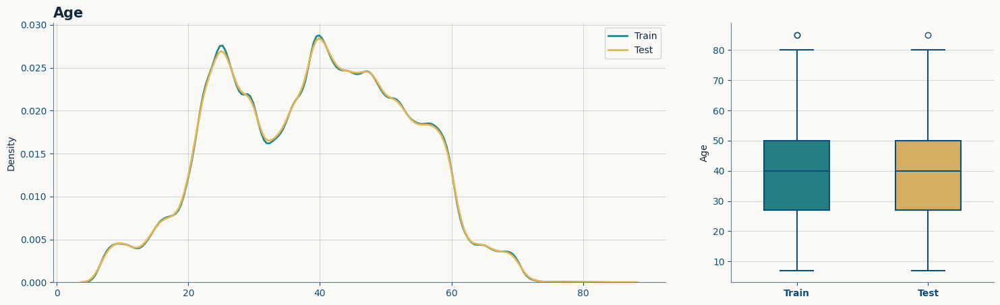

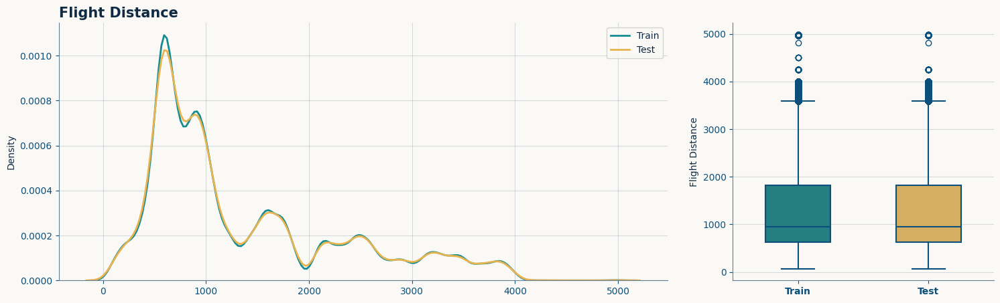

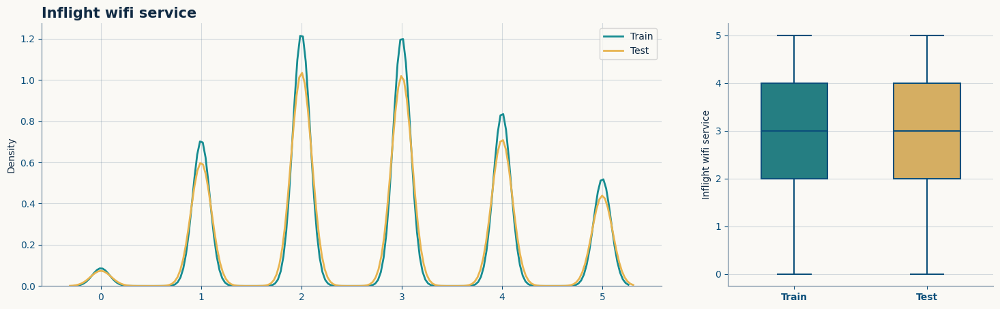

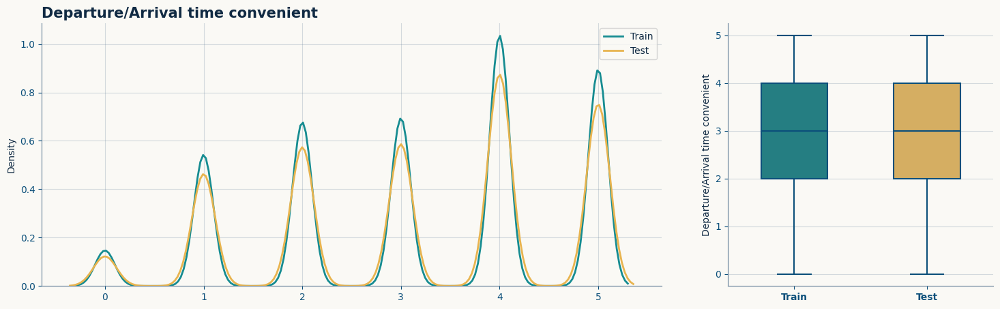

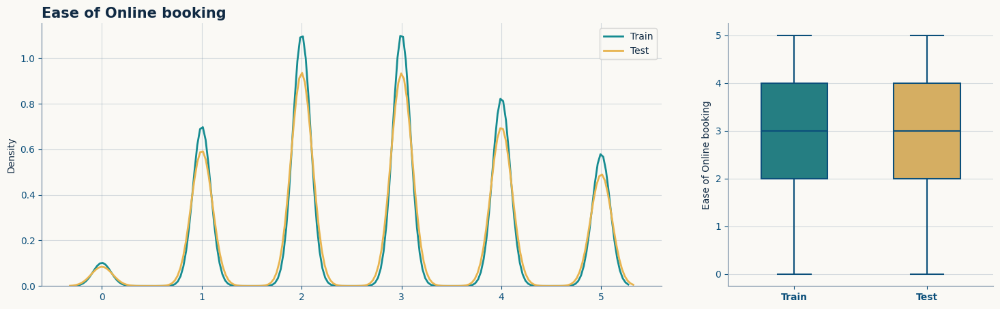

...

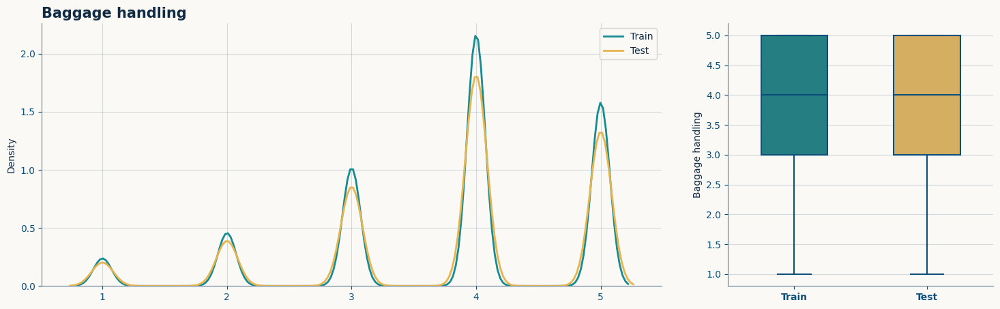

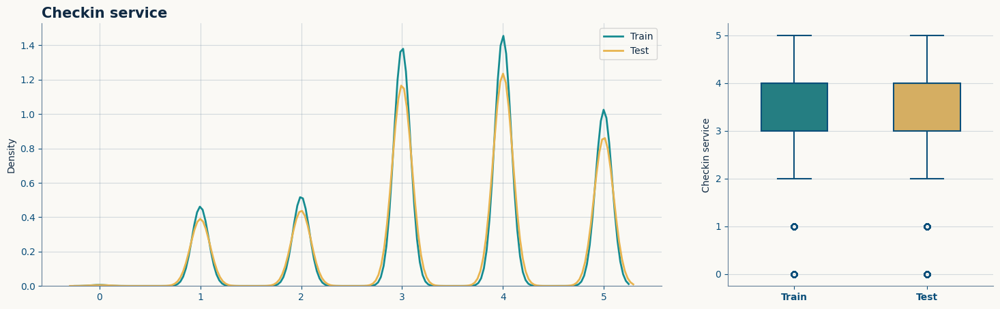

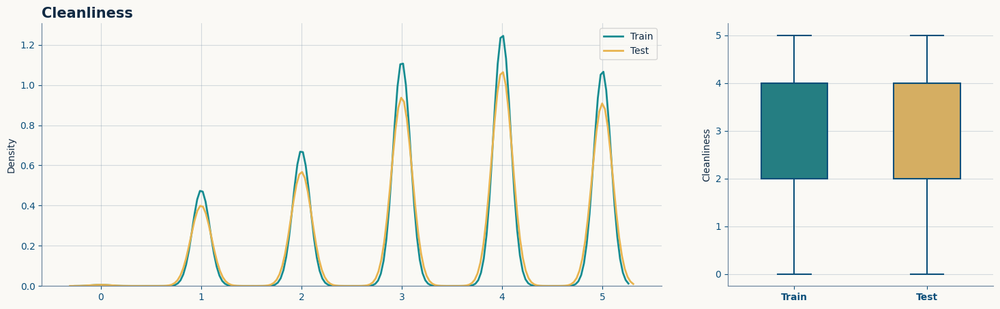

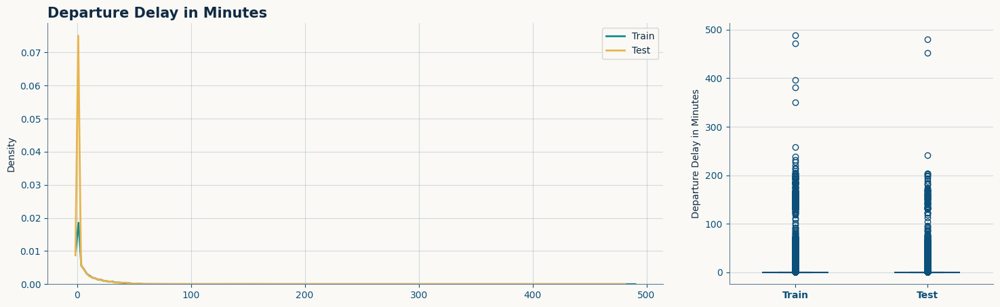

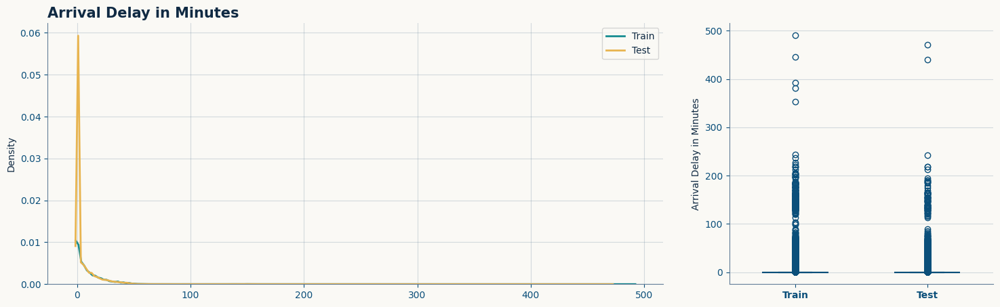

In [18]:
num_distplots = distplots_data(train=train, test=test, features=num_cols) # orig=orig

In [19]:
num_cols

['Age',
 'Flight Distance',
 'Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Cleanliness',
 'Departure Delay in Minutes',
 'Arrival Delay in Minutes']

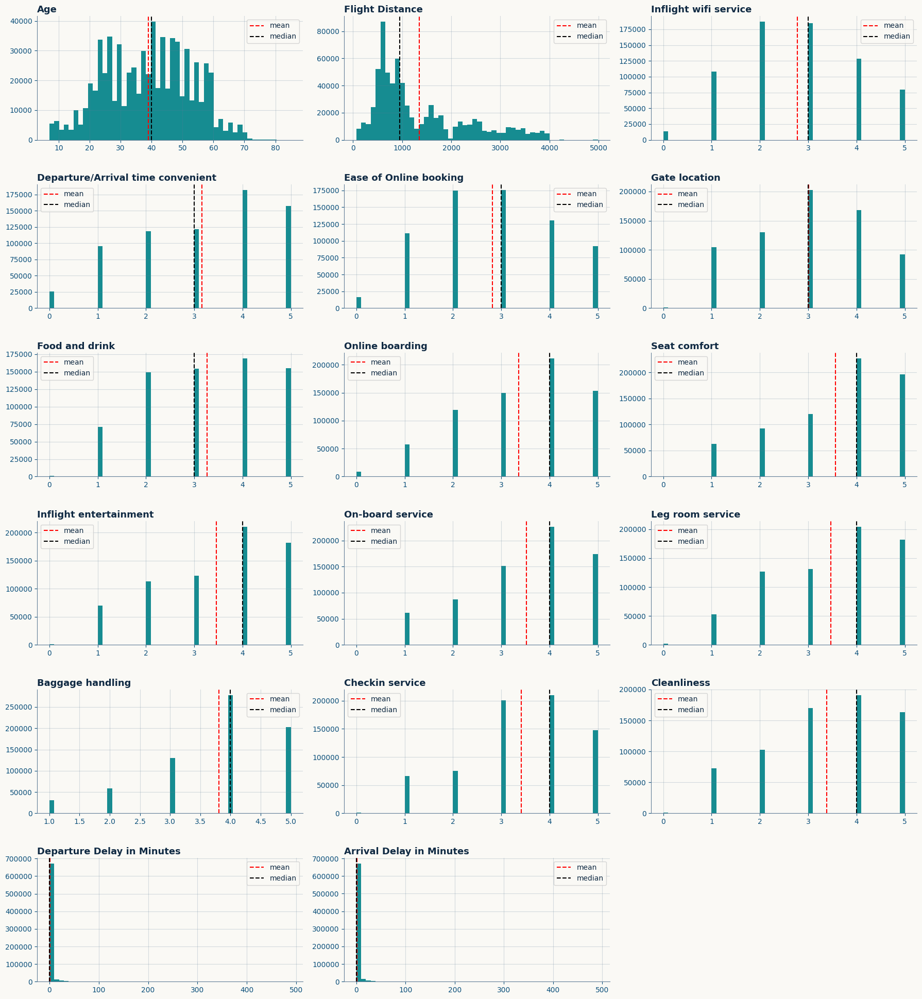

In [20]:
plt.figure(figsize=(18, len(num_cols) + 2.5))

for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols)//3 + 1, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='k', linestyle='--', label='median')
    plt.title(f"{col}", loc='left', pad=5)
    plt.legend()

plt.tight_layout(h_pad=3.0)
plt.show()

## ~ CATEGORICAL

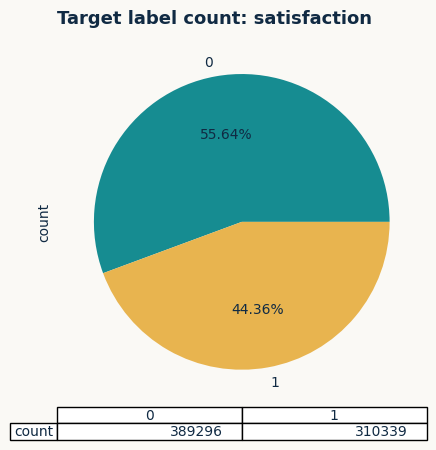

In [21]:
## -- Target label count --
_ = train[TARGET].value_counts(dropna=False).plot.pie(autopct='%1.2f%%', table=True)
_.set_title(f"Target label count: {TARGET}", loc="left", pad=10)
plt.show()

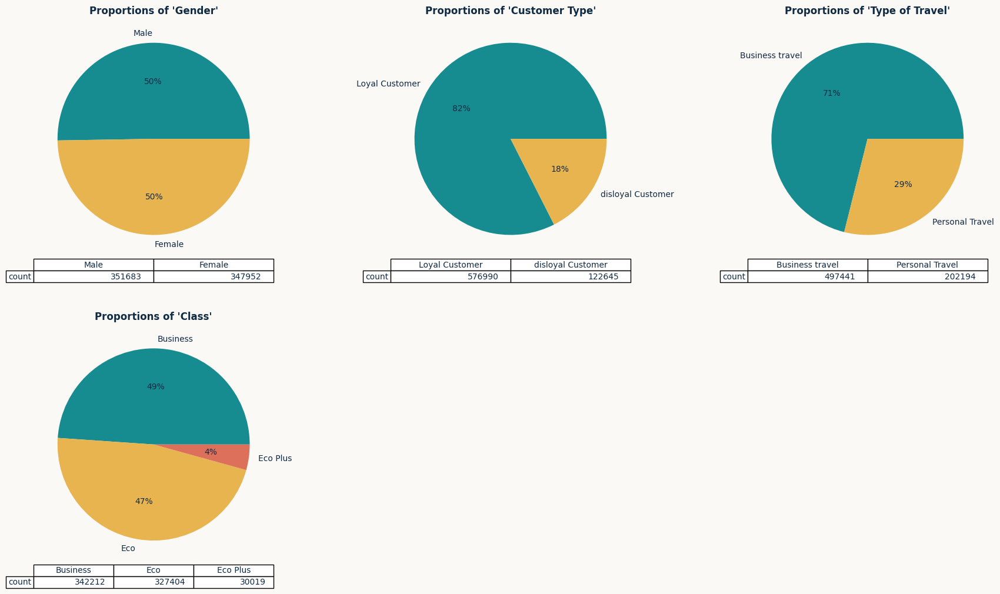

In [22]:
## -- Categorical Features --
plt.figure(figsize=(18, 15))
# for i, col in enumerate([c for c in base_cols if train[c].nunique() <= 20]):
for i, col in enumerate(cat_cols):
    plt.subplot(3, 3, i+1)
    values=train[col].value_counts(dropna=False)
    values.plot.pie(autopct='%1.0f%%', table=True) #fontsize=12, 
    plt.title(f"Proportions of '{col}'", fontdict={'size':12, 'weight': 'bold'})
    plt.axis('off')

plt.tight_layout(h_pad=4.0, w_pad=0.25)
plt.show()

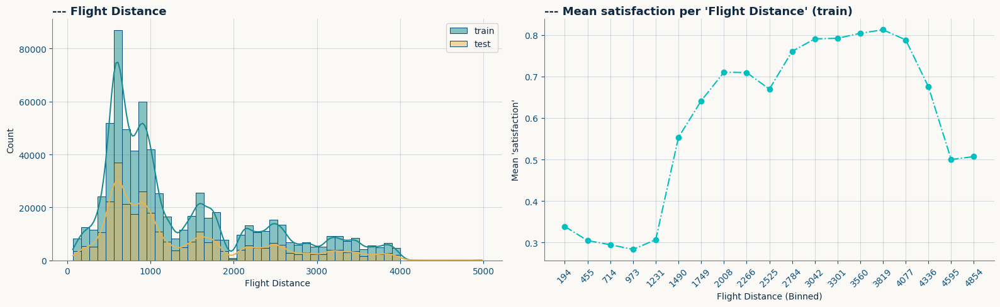

In [23]:
BINS = 19
bin_cols = [c for c in num_cols if train[c].nunique() > 1000]

for c in bin_cols:
    # if train[c].nunique() >= BINS: 
    # Plot 'train' & 'test' distributions
    plt.figure(figsize=(16, 5))
    plt.subplot(121)
    sns.histplot(train[c], kde=True, bins=50, label='train')
    sns.histplot(test[c], kde=True, bins=50, label='test')
    plt.legend()
    plt.title(f"--- {c}", loc='left', pad=5)
    # plt.xticks('')
    ## -- Plot relationship between 'target' and bins
    plt.subplot(122)
    train['bucket'], edges = pd.cut(train[c],bins=BINS,include_lowest=True,retbins=True,labels=False)
    # train['bucket'], edges = pd.qcut(train[c],q=BINS,retbins=True,labels=False)
    bucket_means = train.groupby('bucket')[TARGET].mean()
    bin_midpoints = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_midpoints, bucket_means, marker='o',linestyle='-.',color='c')
    plt.xlabel(f'{c} (Binned)')
    plt.ylabel(f"Mean '{TARGET}'")
    plt.title(f"--- Mean {TARGET} per '{c}' (train)", loc='left', pad=5)
    plt.xticks(bin_midpoints, rotation=45)

    plt.tight_layout()
    plt.show()

train.drop(['bucket'], axis=1, inplace=True)

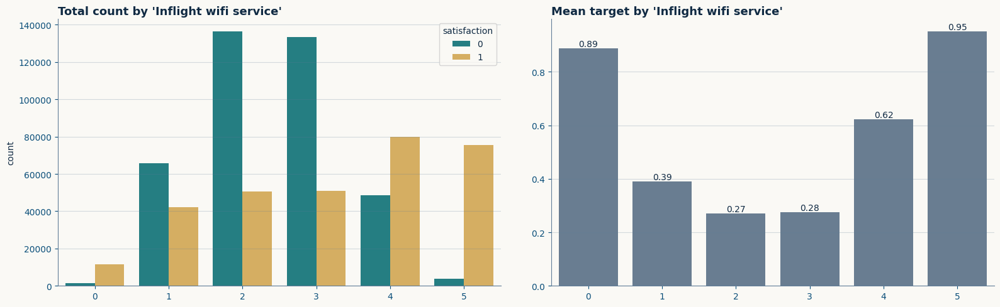

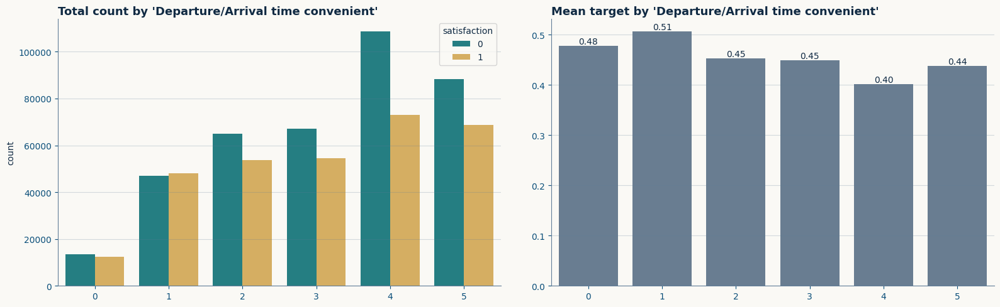

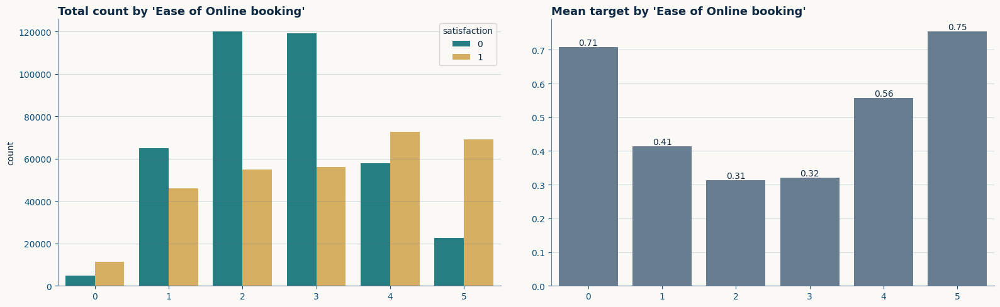

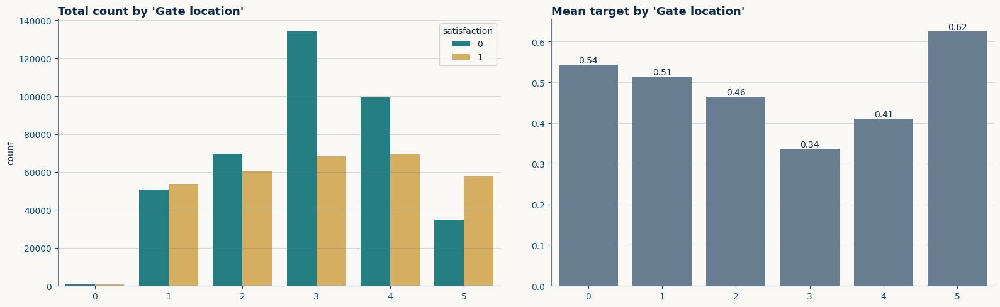

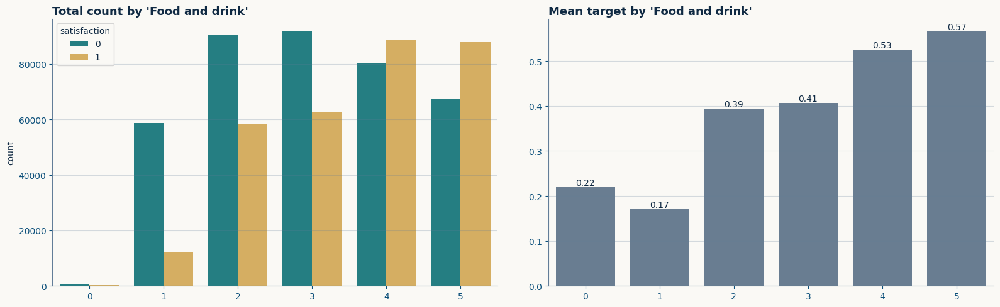

...

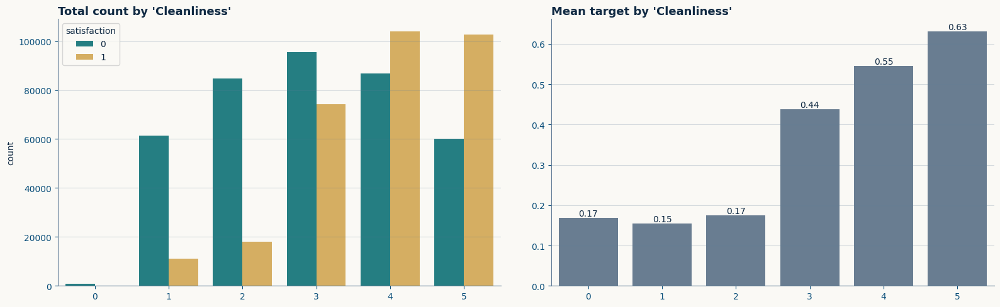

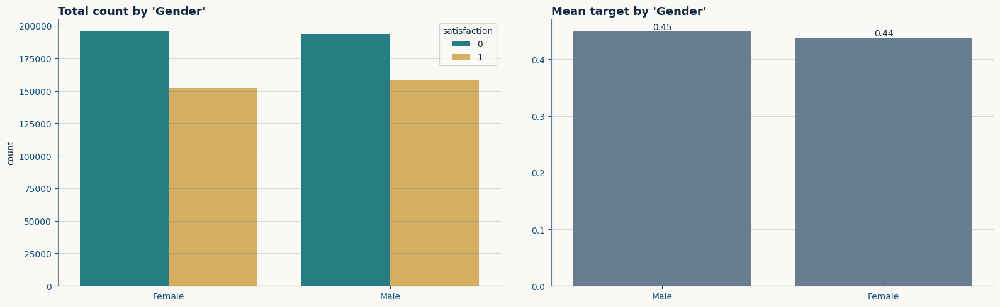

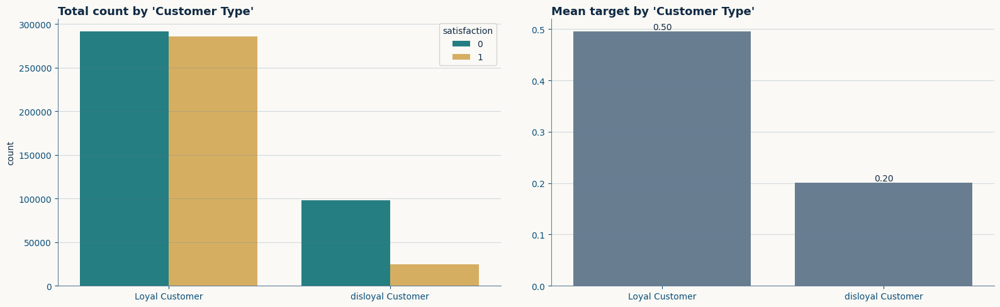

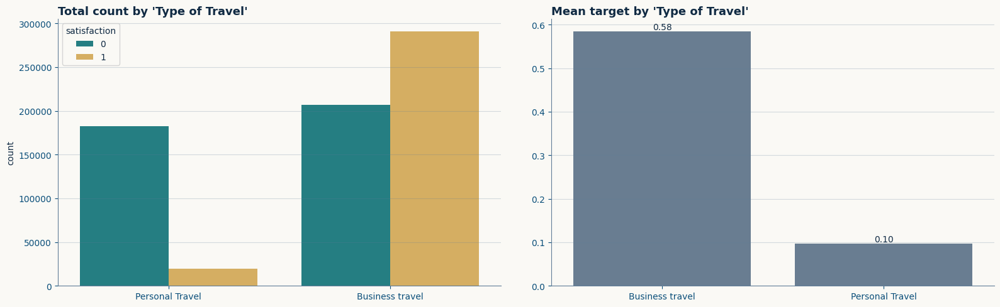

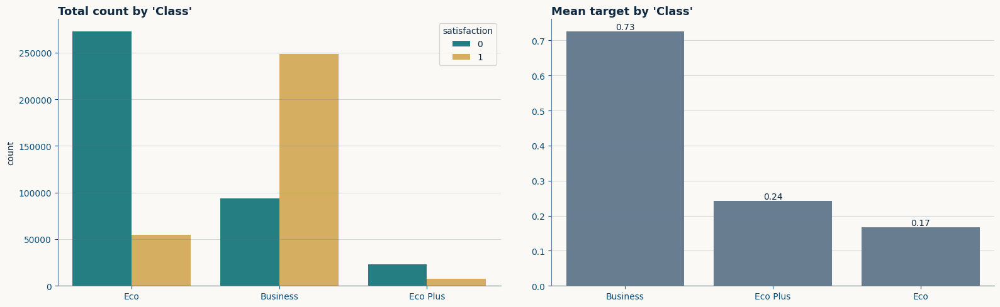

In [24]:
## -- Categorical Features: Counts and Mean by TARGET --
## -- Features with unique count <= 100
CATS_100 = [c for c in base_cols if train[c].nunique() <= 20]

for i, c in enumerate(CATS_100):
    fig, axs = plt.subplots(1, 2, figsize=(16, 5))

    sns.countplot(train, x=c, hue=TARGET, ax=axs[0])
    axs[0].set_title(f"Total count by '{c}'", loc="left", pad=5)
    axs[0].set_xlabel('')
    axs[0].tick_params(axis='x', rotation=0)

    v_mean = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=v_mean.index, y=v_mean.values, ax=axs[1], color=MUTED)
    axs[1].set_title(f"Mean target by '{c}'", loc="left", pad=5)
    axs[1].set_xlabel('')
    axs[1].tick_params(axis='x', rotation=0)

    for container in axs[1].containers: # Display values on bars
        axs[1].bar_label(container, fmt='%.2f')

    _ = fig.tight_layout(w_pad=3.5)
    plt.show()
    print()

## ~ PAIRWISE (CATEGORICAL) ANALYSIS

In [25]:
n_unique = train[base_cols].nunique().sort_values()
n_unique

Customer Type                           2
Type of Travel                          2
Gender                                  2
Class                                   3
Baggage handling                        5
Departure/Arrival time convenient       6
Gate location                           6
Inflight wifi service                   6
Leg room service                        6
Checkin service                         6
On-board service                        6
Inflight entertainment                  6
Food and drink                          6
Online boarding                         6
Seat comfort                            6
Ease of Online booking                  6
Cleanliness                             6
Age                                    75
Departure Delay in Minutes            167
Arrival Delay in Minutes              168
Flight Distance                      3474
dtype: int64

In [26]:
# if train[combo[0]].nunique() > train[combo[1]].nunique():
#     print(f'a: {combo[0]} has more nunique values than b: {combo[1]}')
#     combo = [combo[0], combo[0]]
#     print(combo)
# else:
#     print(f'b: {combo[1]} has more nunique values than a: {combo[0]}')
#     combo = [combo[1], combo[0]]
#     print(combo)

('Customer Type', 'Type of Travel')| Type of Travel has more unique variables | ['Type of Travel', 'Customer Type']


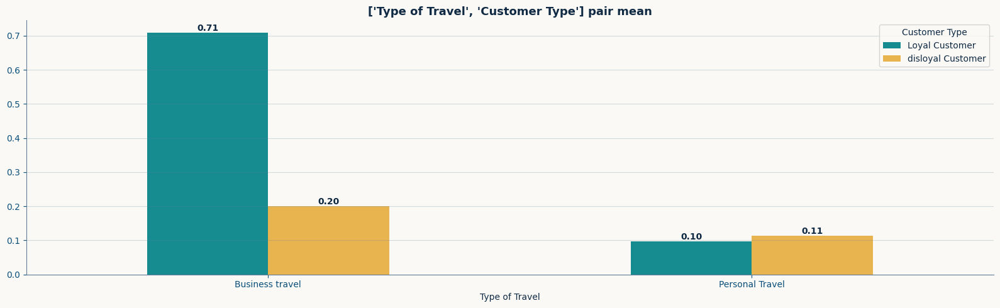


('Customer Type', 'Gender')| Gender has more unique variables | ['Gender', 'Customer Type']


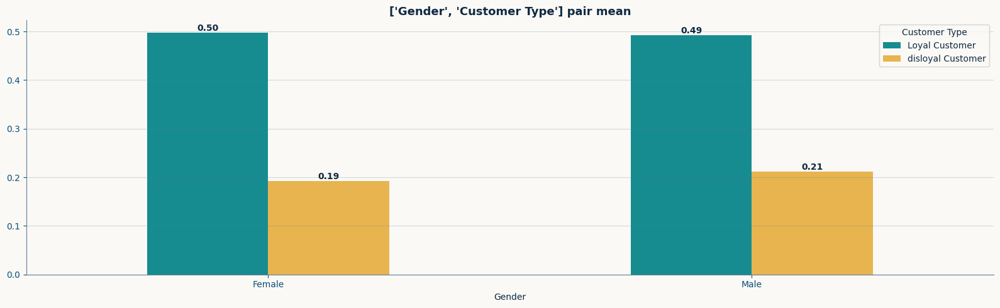


('Customer Type', 'Class')| Class has more unique variables | ['Class', 'Customer Type']


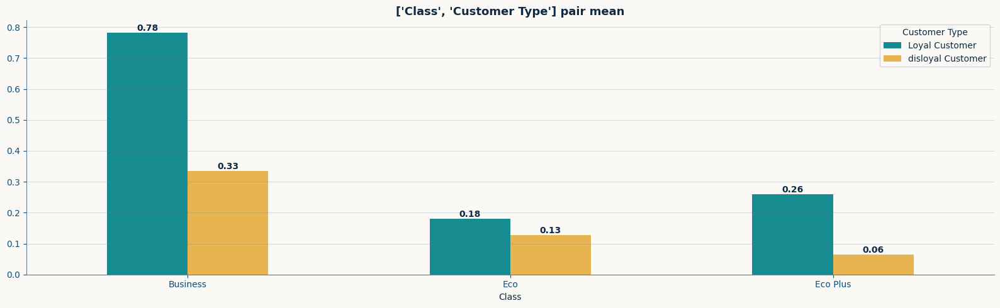


('Customer Type', 'Baggage handling')| Baggage handling has more unique variables | ['Baggage handling', 'Customer Type']


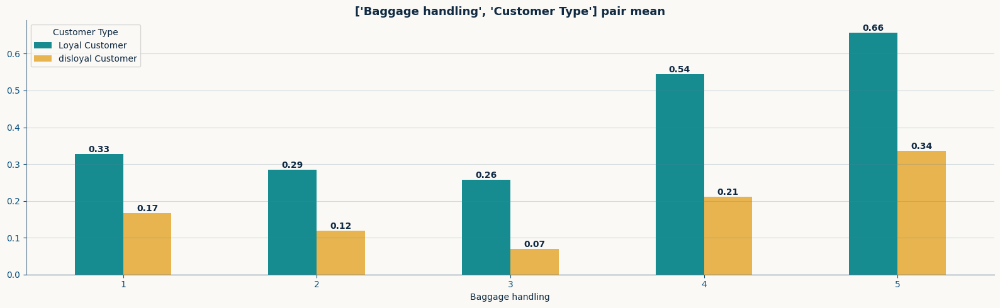


('Customer Type', 'Departure/Arrival time convenient')| Departure/Arrival time convenient has more unique variables | ['Departure/Arrival time convenient', 'Customer Type']


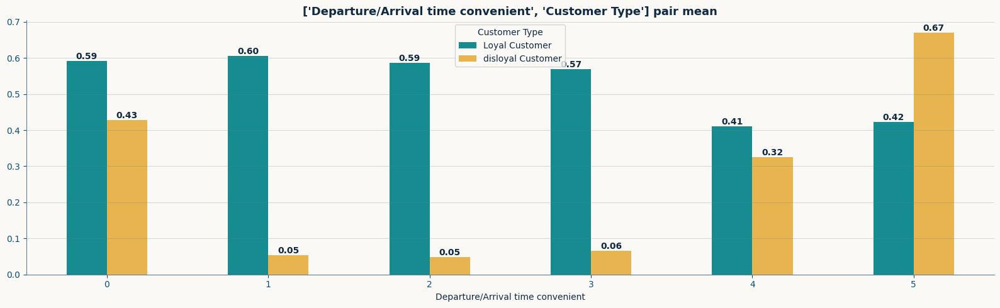


('Customer Type', 'Gate location')| Gate location has more unique variables | ['Gate location', 'Customer Type']


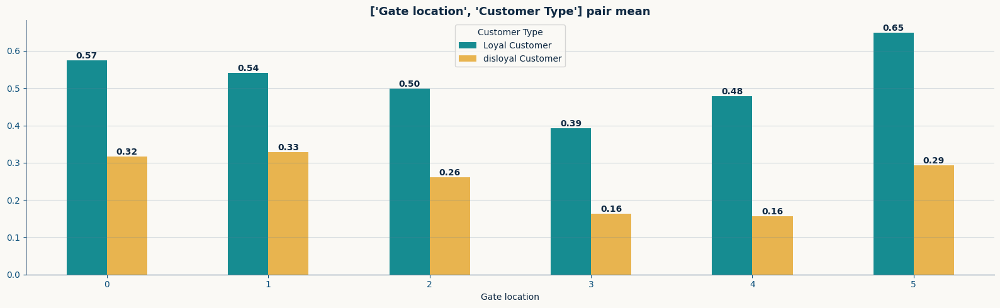


('Customer Type', 'Inflight wifi service')| Inflight wifi service has more unique variables | ['Inflight wifi service', 'Customer Type']


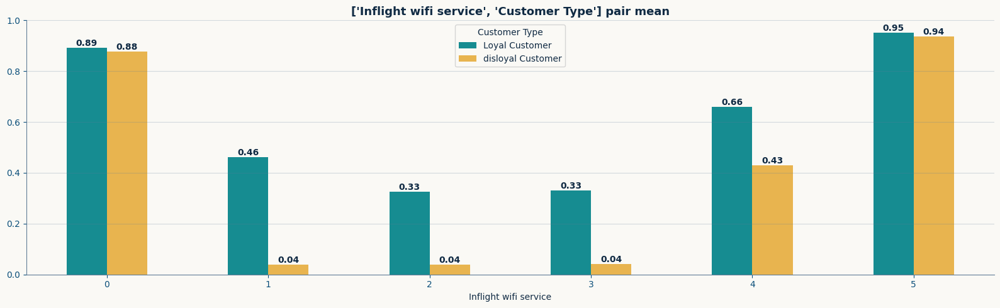


('Customer Type', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Customer Type']


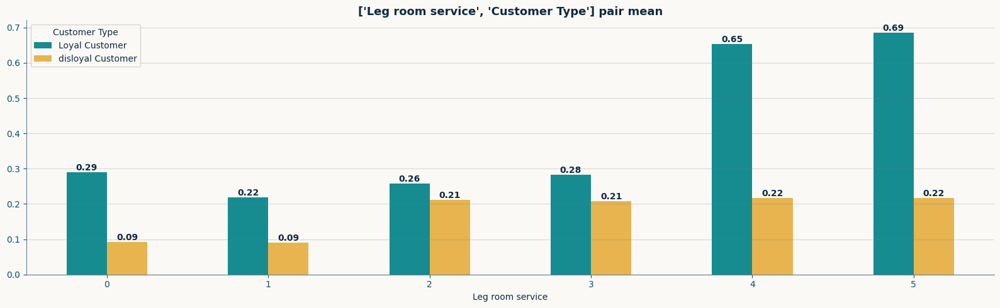


('Customer Type', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Customer Type']


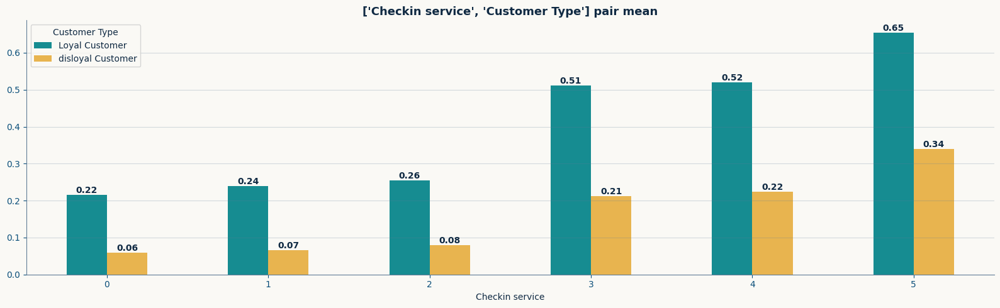


('Customer Type', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Customer Type']


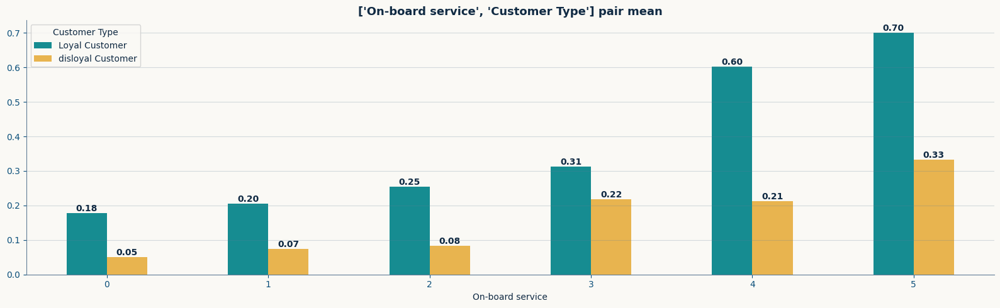


('Customer Type', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Customer Type']


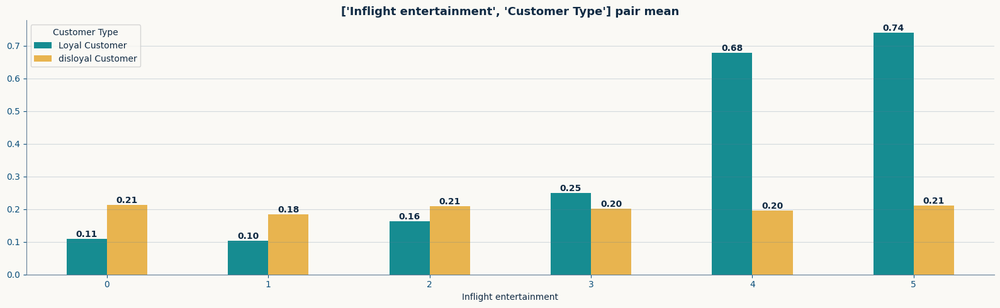


('Customer Type', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Customer Type']


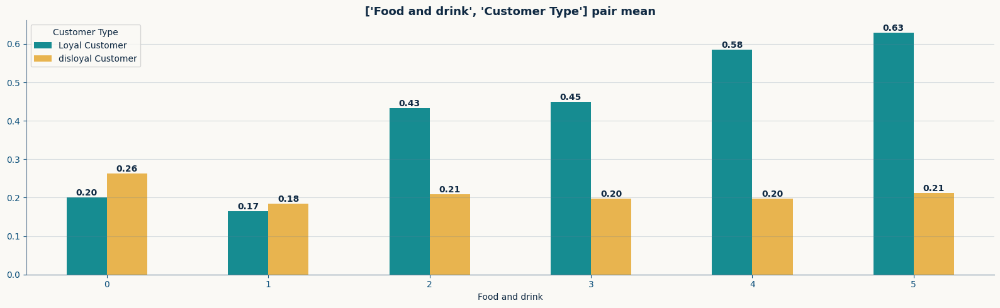


('Customer Type', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Customer Type']


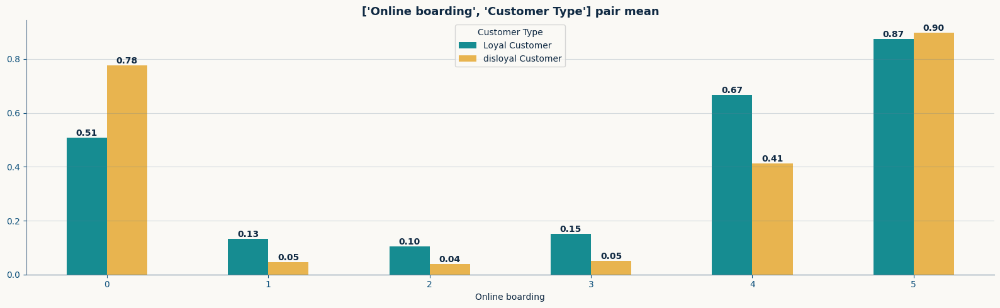


('Customer Type', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Customer Type']


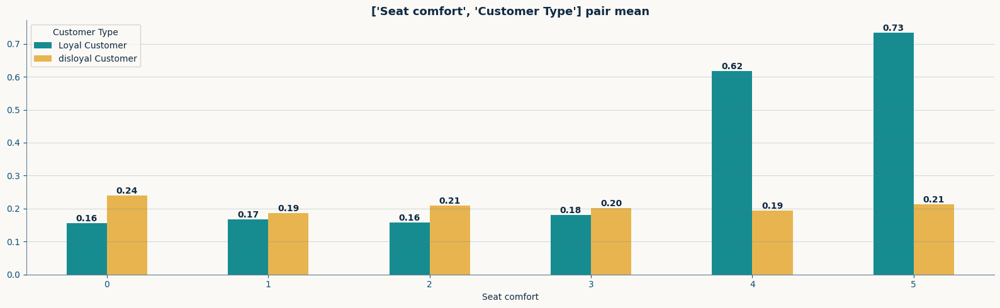


('Customer Type', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Customer Type']


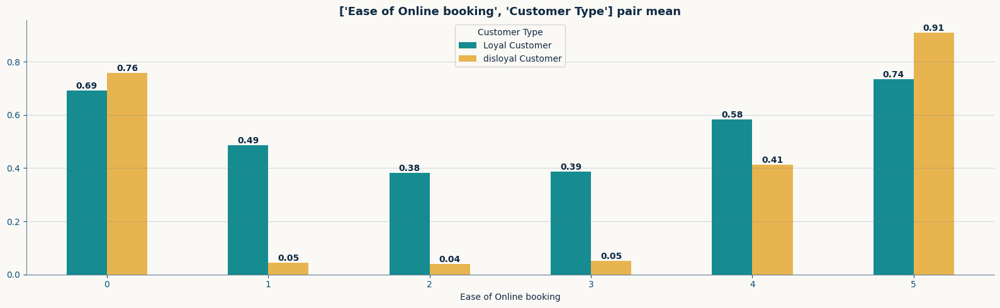


('Customer Type', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Customer Type']


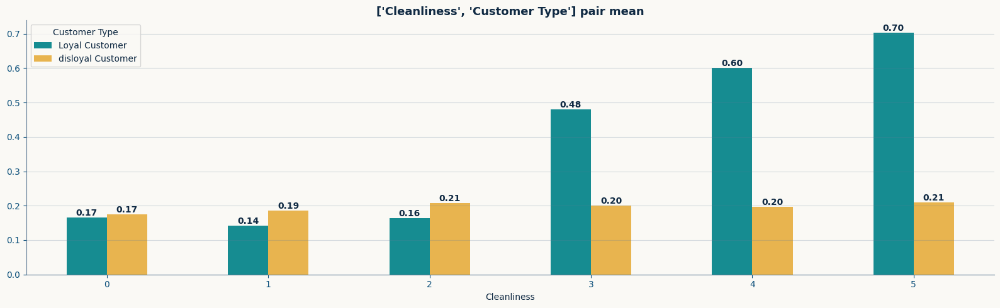


('Type of Travel', 'Gender')| Gender has more unique variables | ['Gender', 'Type of Travel']


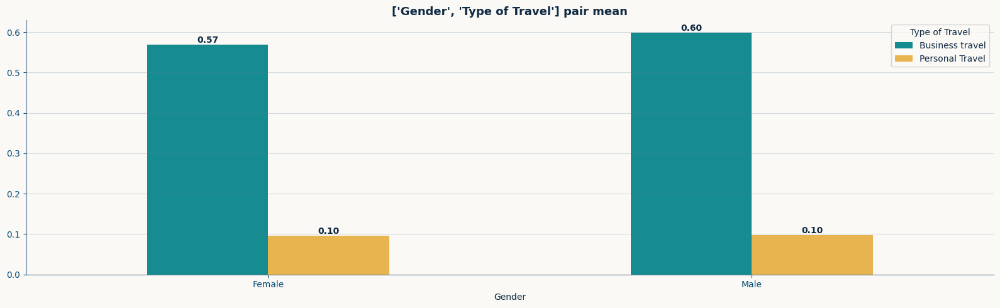


('Type of Travel', 'Class')| Class has more unique variables | ['Class', 'Type of Travel']


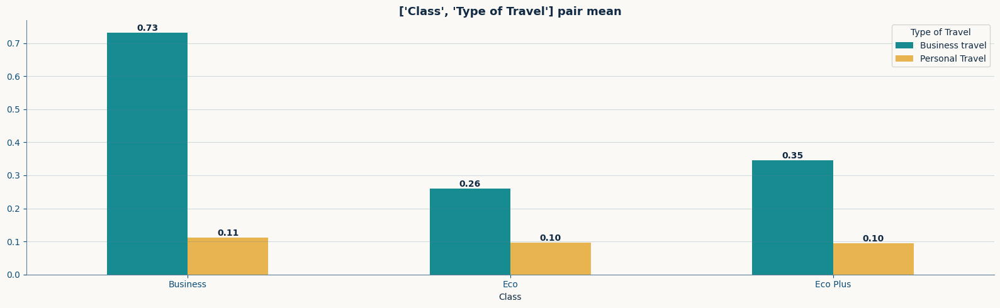


('Type of Travel', 'Baggage handling')| Baggage handling has more unique variables | ['Baggage handling', 'Type of Travel']


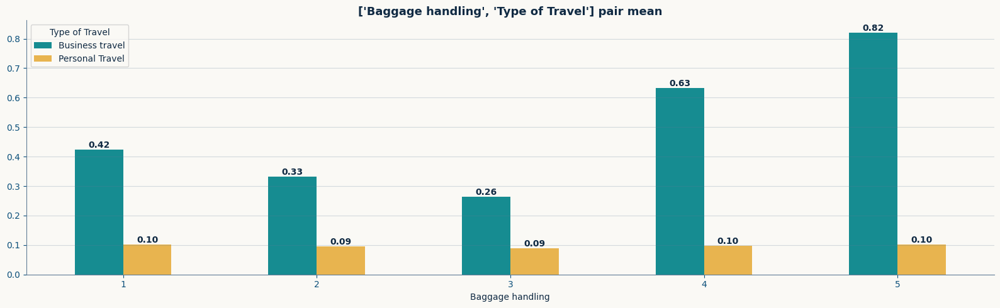


('Type of Travel', 'Departure/Arrival time convenient')| Departure/Arrival time convenient has more unique variables | ['Departure/Arrival time convenient', 'Type of Travel']


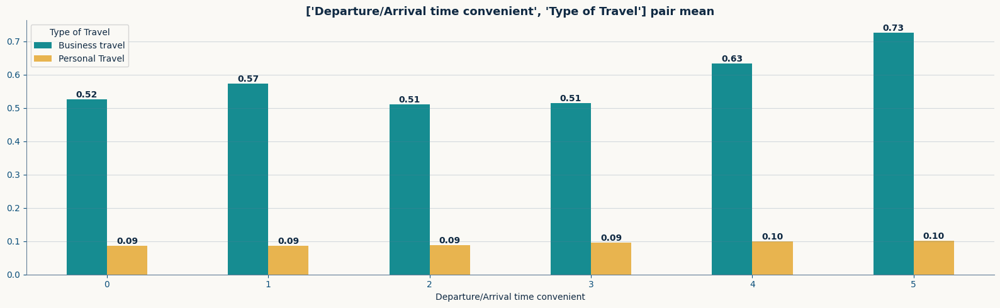


('Type of Travel', 'Gate location')| Gate location has more unique variables | ['Gate location', 'Type of Travel']


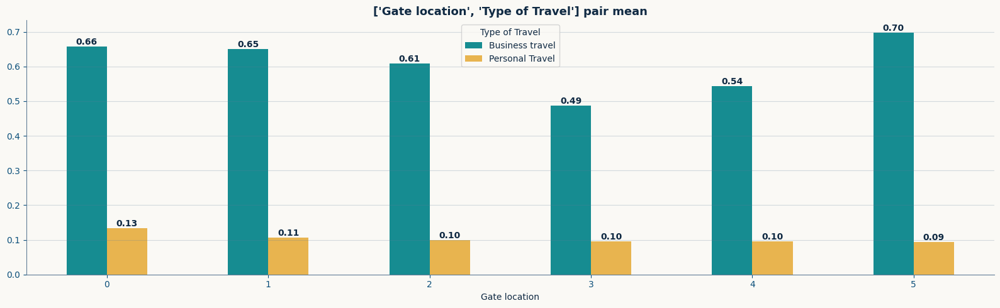


('Type of Travel', 'Inflight wifi service')| Inflight wifi service has more unique variables | ['Inflight wifi service', 'Type of Travel']


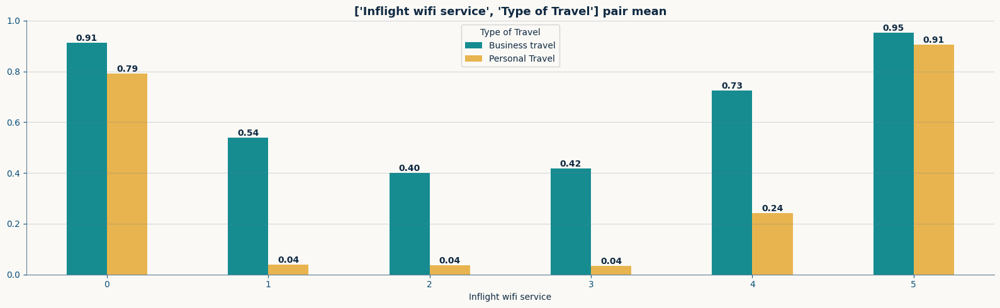


('Type of Travel', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Type of Travel']


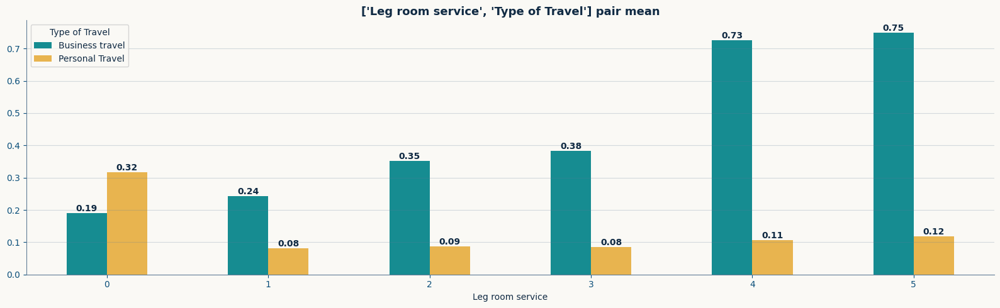


('Type of Travel', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Type of Travel']


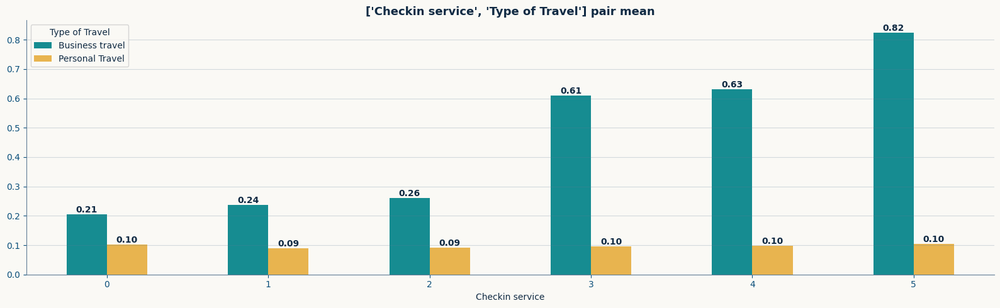


('Type of Travel', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Type of Travel']


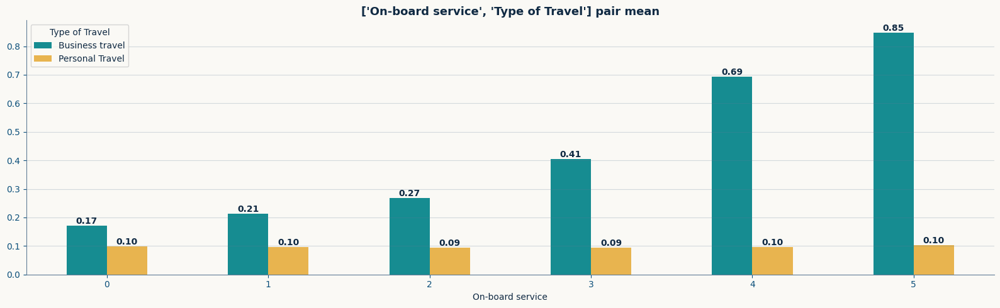


('Type of Travel', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Type of Travel']


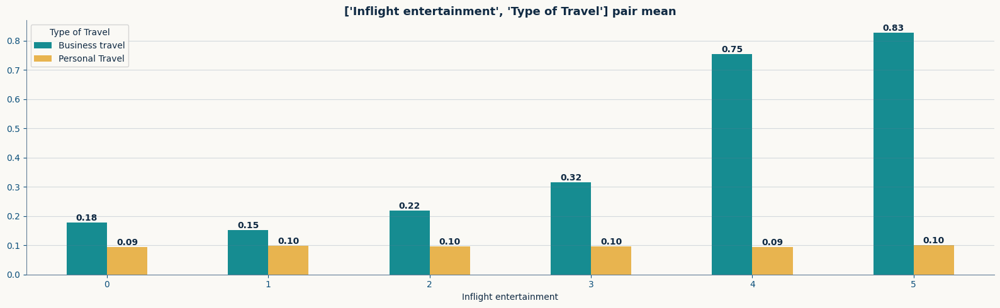


('Type of Travel', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Type of Travel']


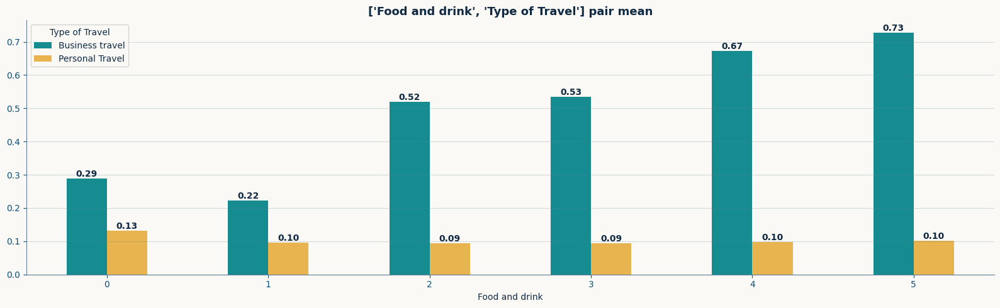


('Type of Travel', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Type of Travel']


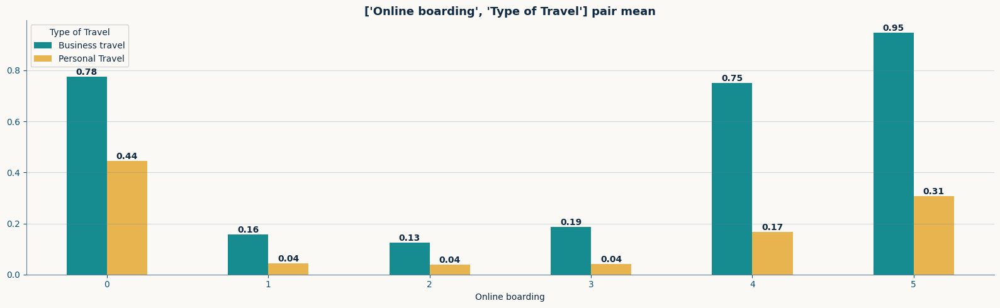


('Type of Travel', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Type of Travel']


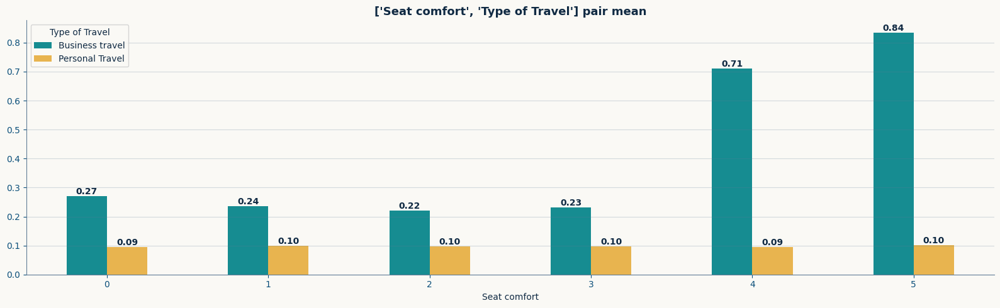


('Type of Travel', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Type of Travel']


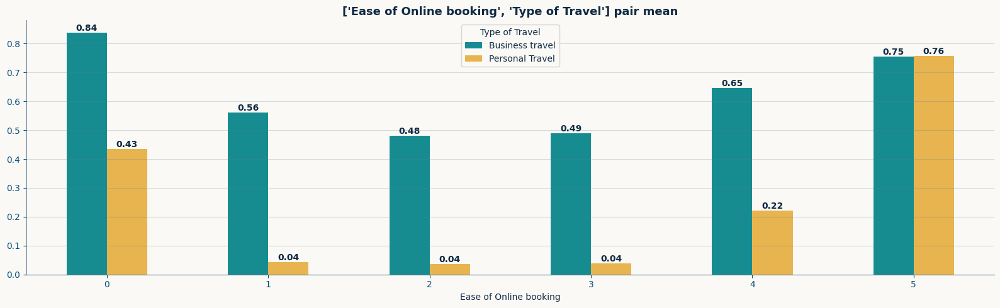


('Type of Travel', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Type of Travel']


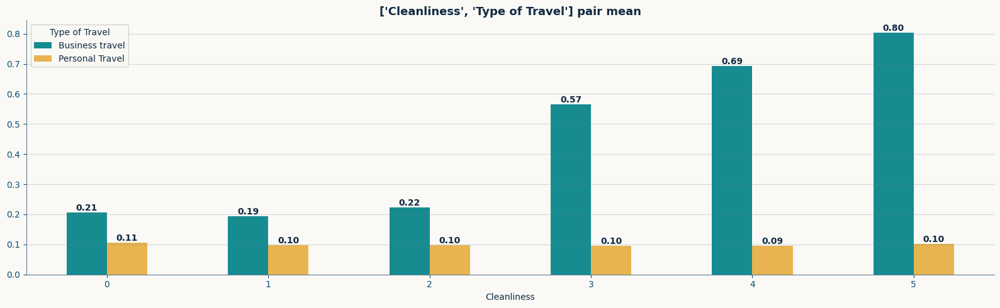


('Gender', 'Class')| Class has more unique variables | ['Class', 'Gender']


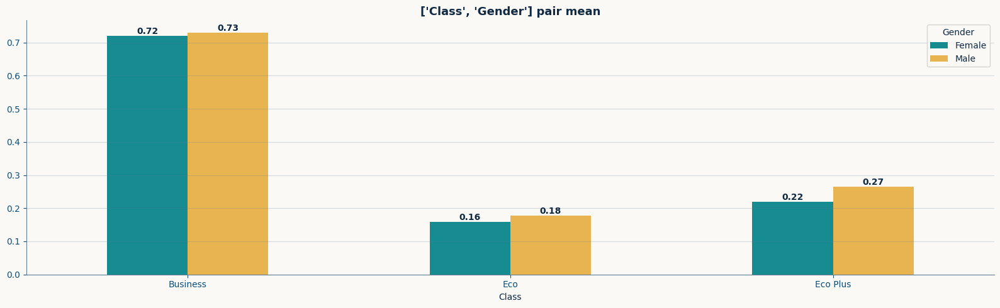


('Gender', 'Baggage handling')| Baggage handling has more unique variables | ['Baggage handling', 'Gender']


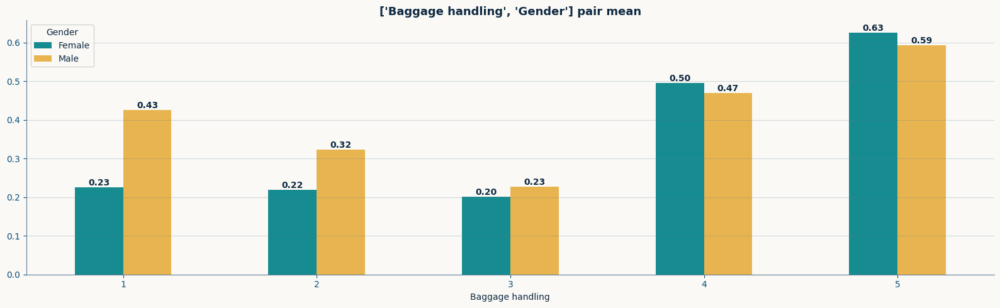


('Gender', 'Departure/Arrival time convenient')| Departure/Arrival time convenient has more unique variables | ['Departure/Arrival time convenient', 'Gender']


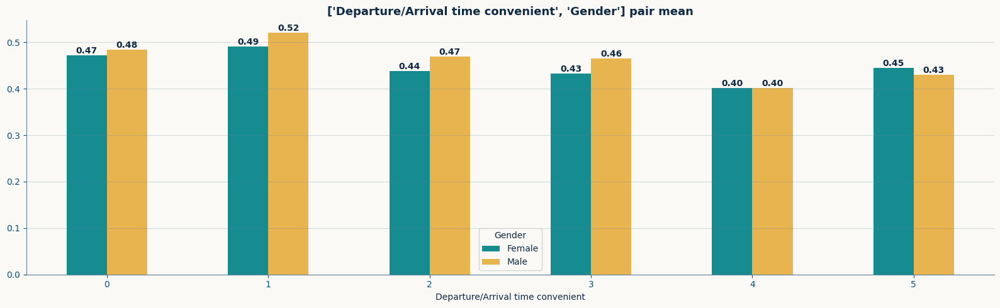


('Gender', 'Gate location')| Gate location has more unique variables | ['Gate location', 'Gender']


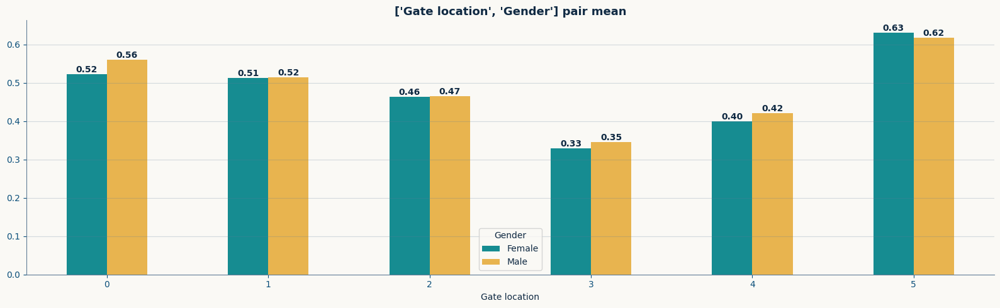


('Gender', 'Inflight wifi service')| Inflight wifi service has more unique variables | ['Inflight wifi service', 'Gender']


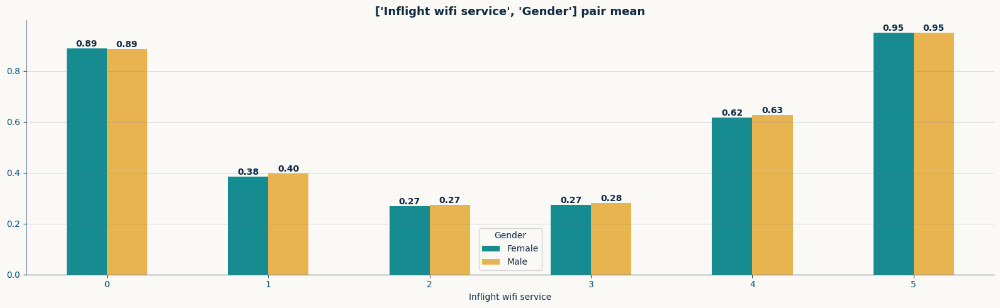


('Gender', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Gender']


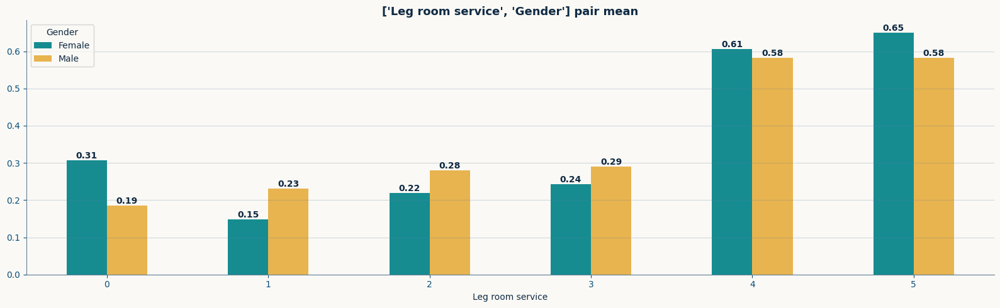


('Gender', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Gender']


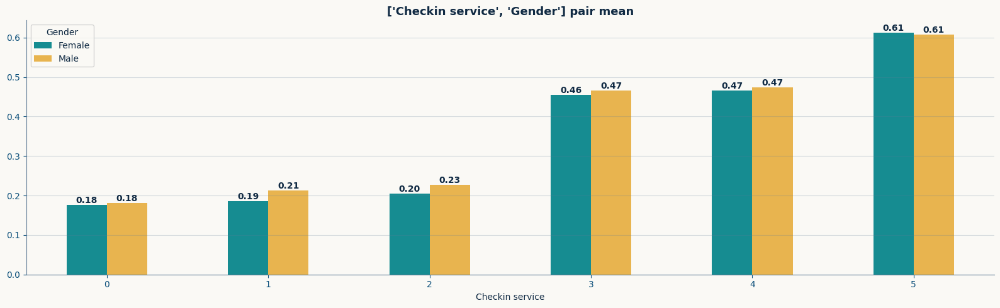


('Gender', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Gender']


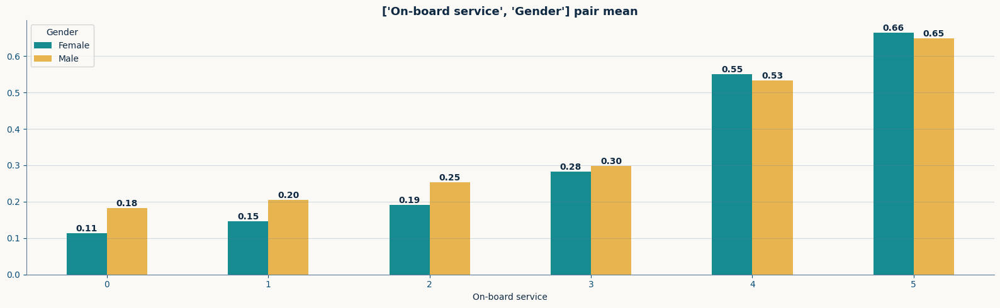


('Gender', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Gender']


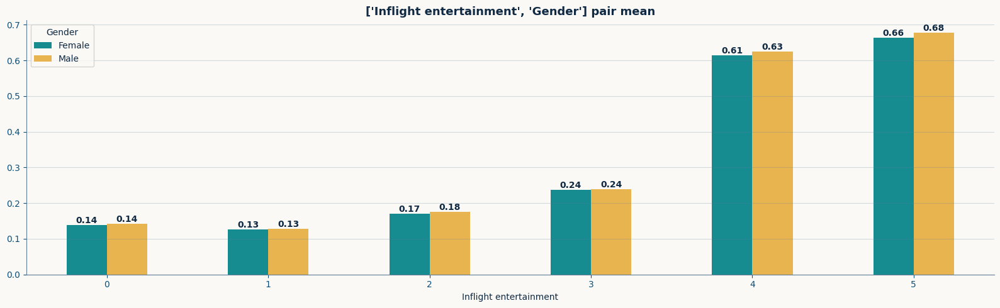


('Gender', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Gender']


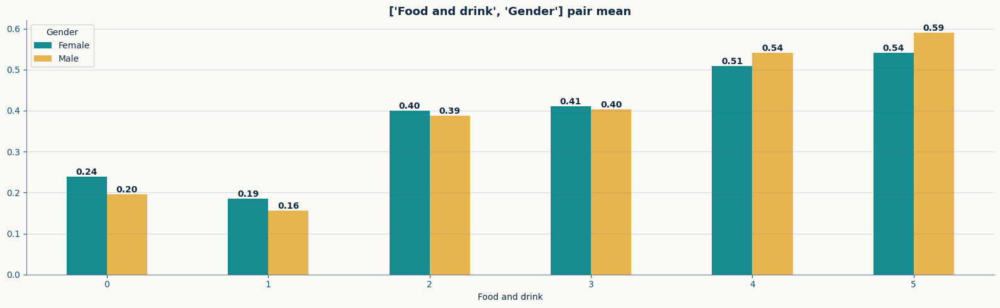


('Gender', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Gender']


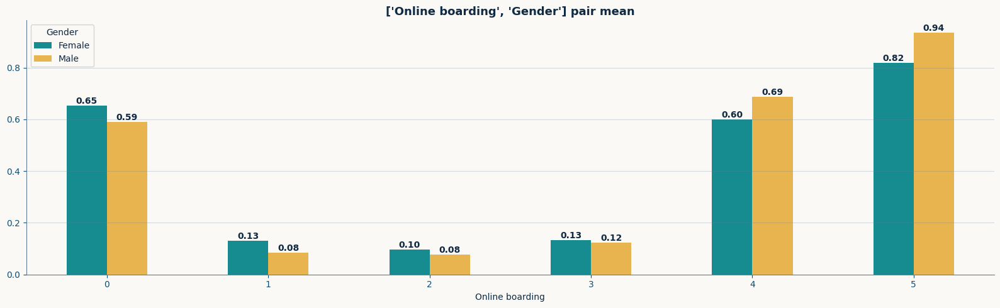


('Gender', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Gender']


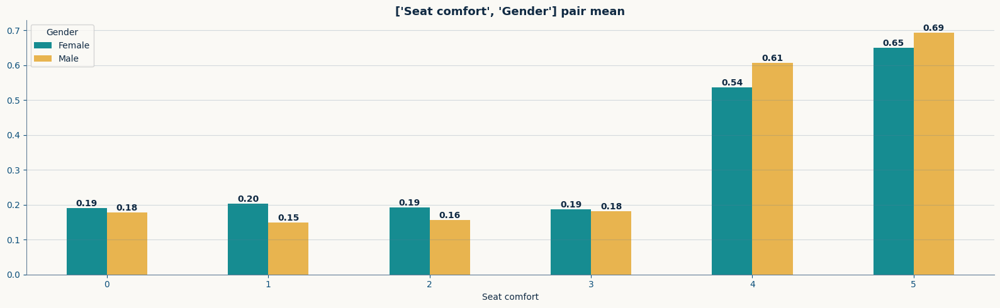


('Gender', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Gender']


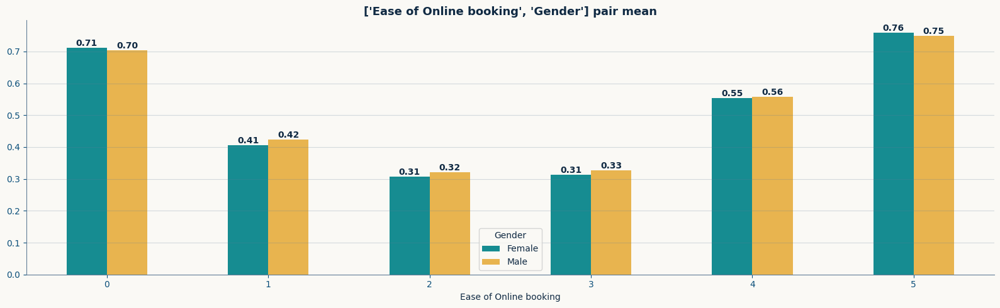


('Gender', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Gender']


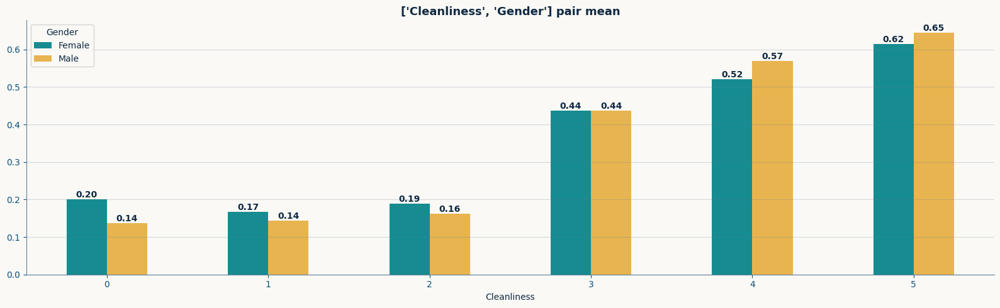


('Class', 'Baggage handling')| Baggage handling has more unique variables | ['Baggage handling', 'Class']


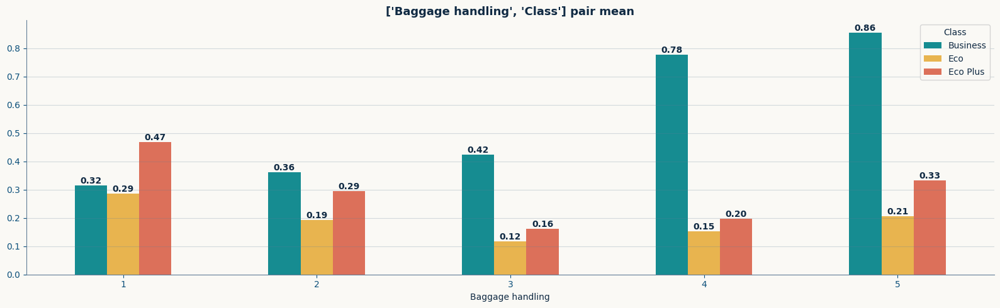


('Class', 'Departure/Arrival time convenient')| Departure/Arrival time convenient has more unique variables | ['Departure/Arrival time convenient', 'Class']


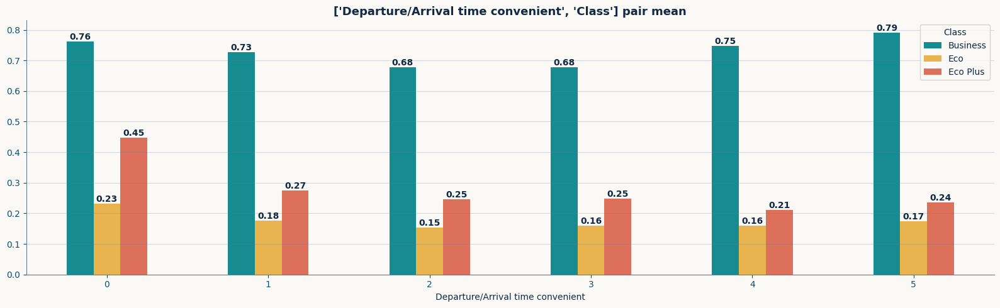


('Class', 'Gate location')| Gate location has more unique variables | ['Gate location', 'Class']


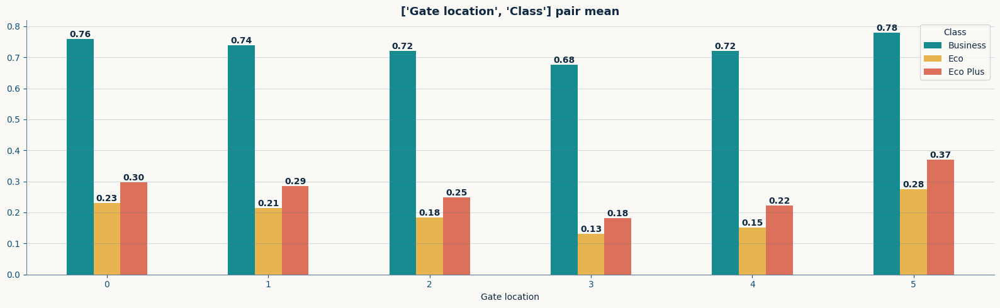


('Class', 'Inflight wifi service')| Inflight wifi service has more unique variables | ['Inflight wifi service', 'Class']


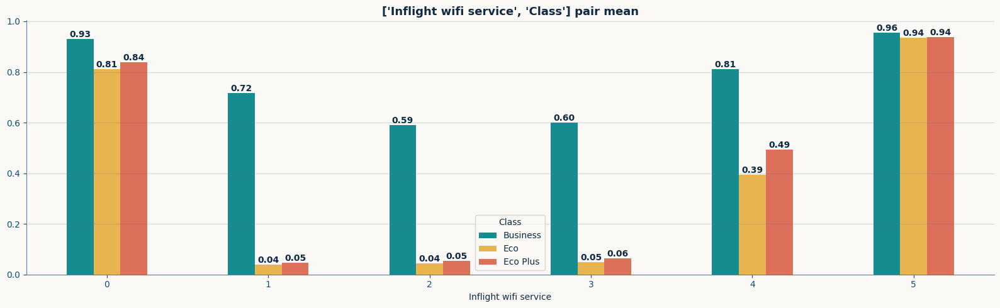


('Class', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Class']


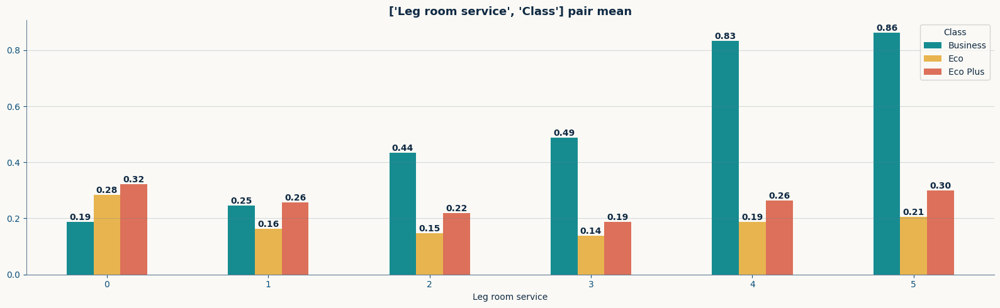


('Class', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Class']


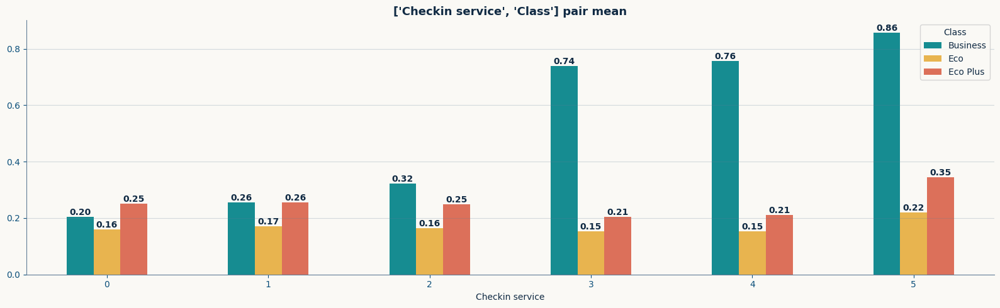


('Class', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Class']


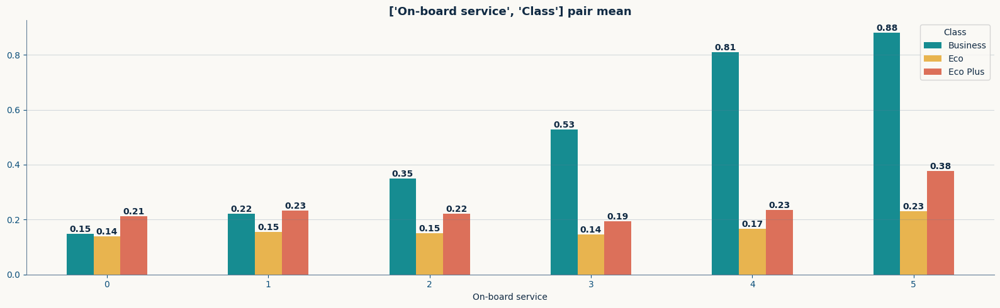


('Class', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Class']


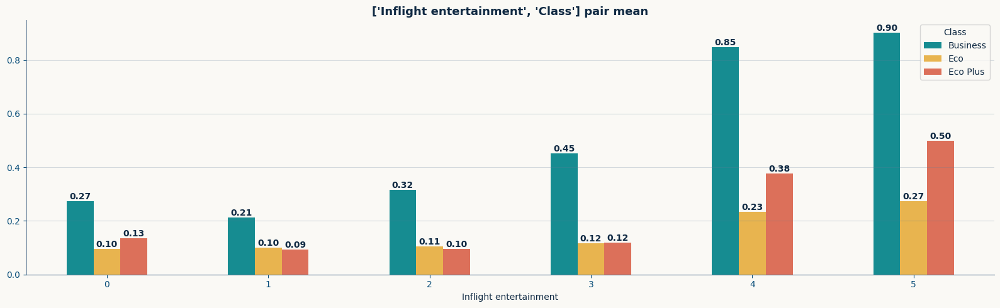


('Class', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Class']


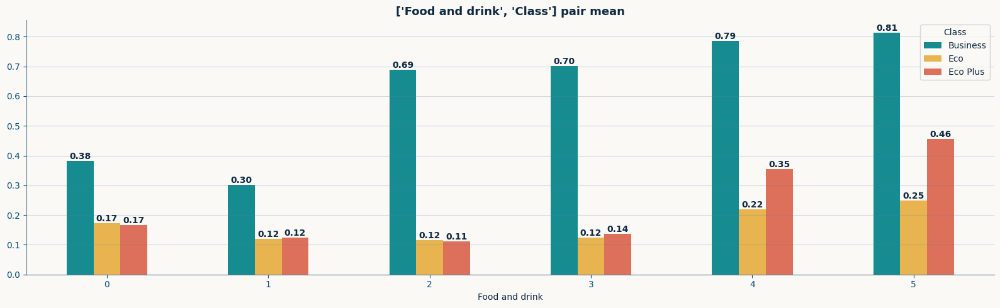


('Class', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Class']


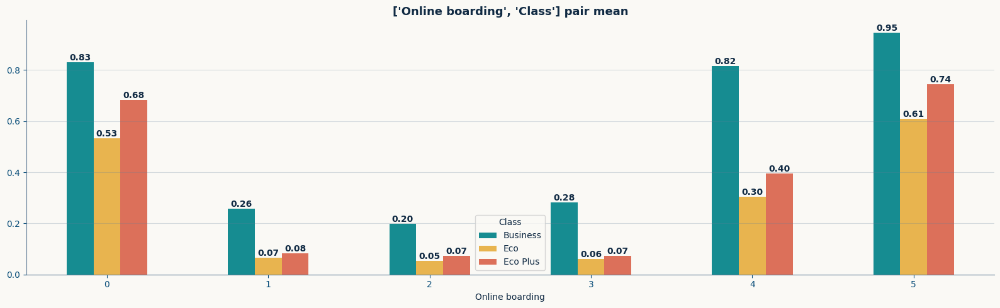


('Class', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Class']


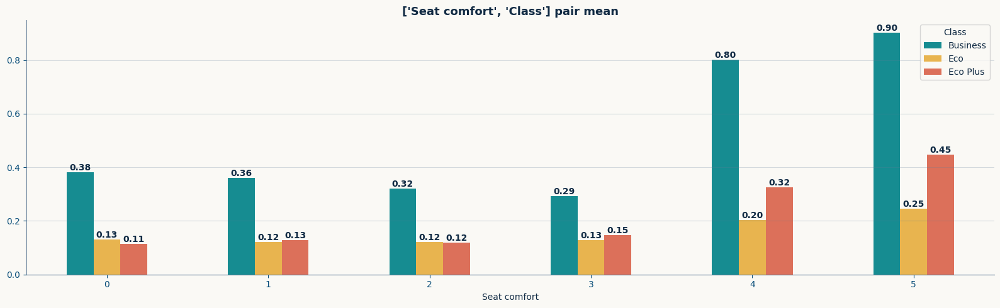


('Class', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Class']


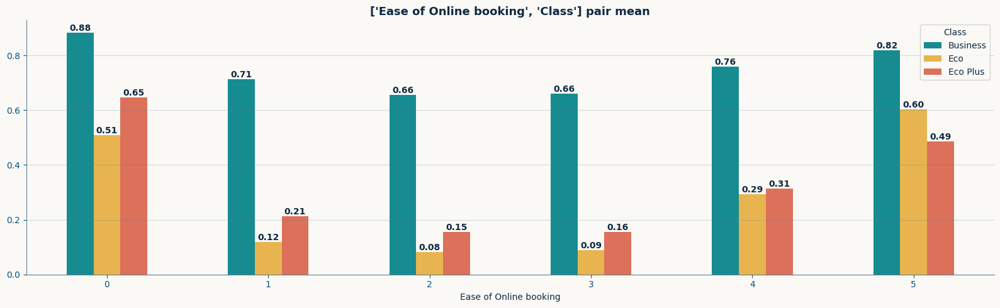


('Class', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Class']


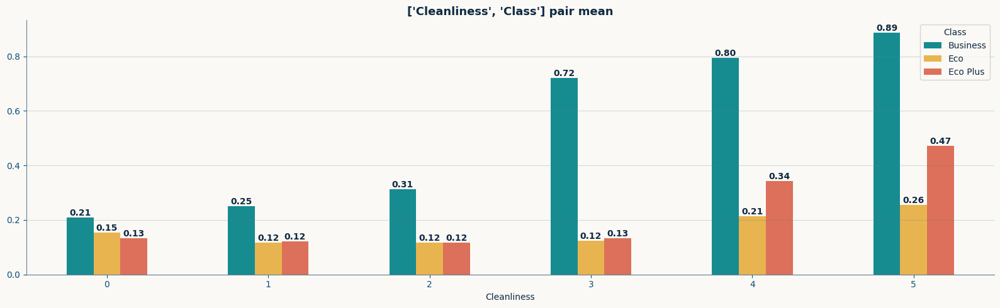


('Baggage handling', 'Departure/Arrival time convenient')| Departure/Arrival time convenient has more unique variables | ['Departure/Arrival time convenient', 'Baggage handling']


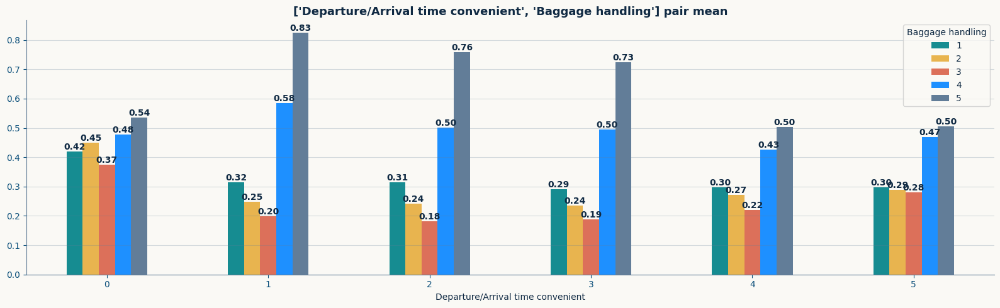


('Baggage handling', 'Gate location')| Gate location has more unique variables | ['Gate location', 'Baggage handling']


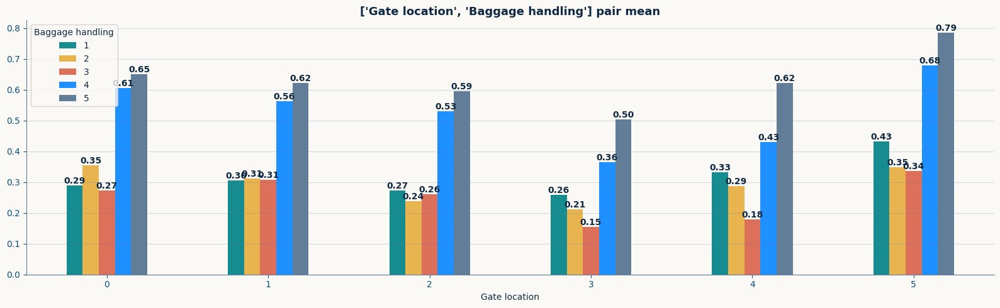


('Baggage handling', 'Inflight wifi service')| Inflight wifi service has more unique variables | ['Inflight wifi service', 'Baggage handling']


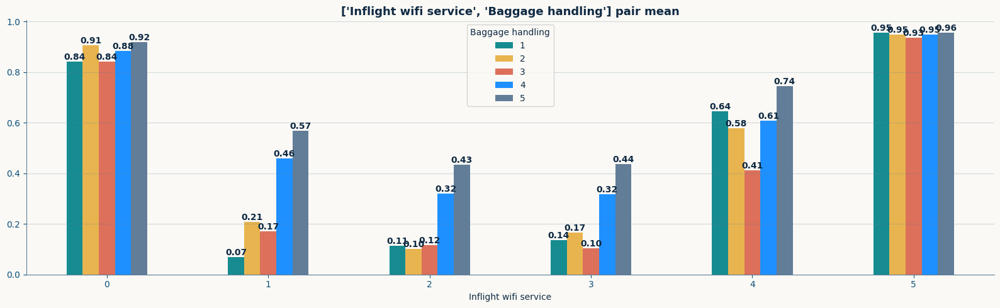


('Baggage handling', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Baggage handling']


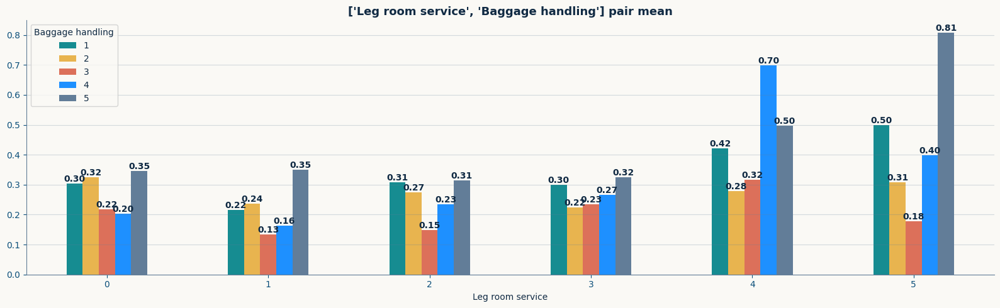


('Baggage handling', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Baggage handling']


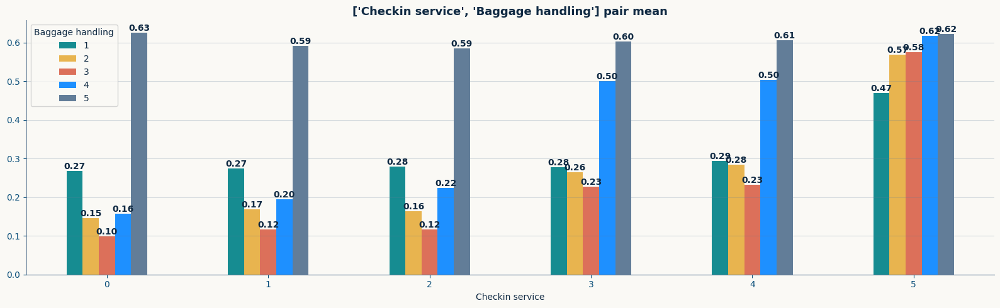


('Baggage handling', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Baggage handling']


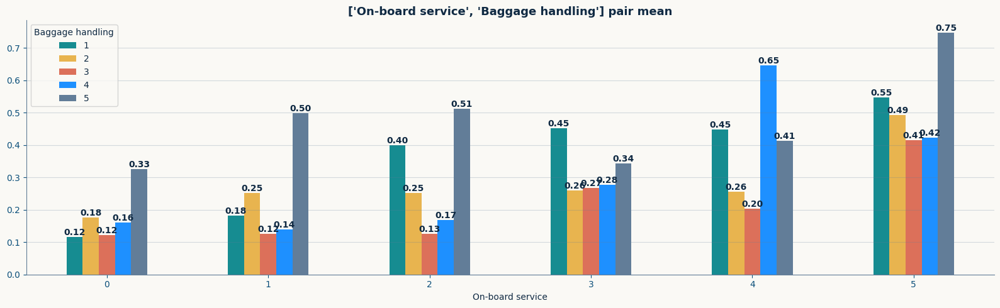


('Baggage handling', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Baggage handling']


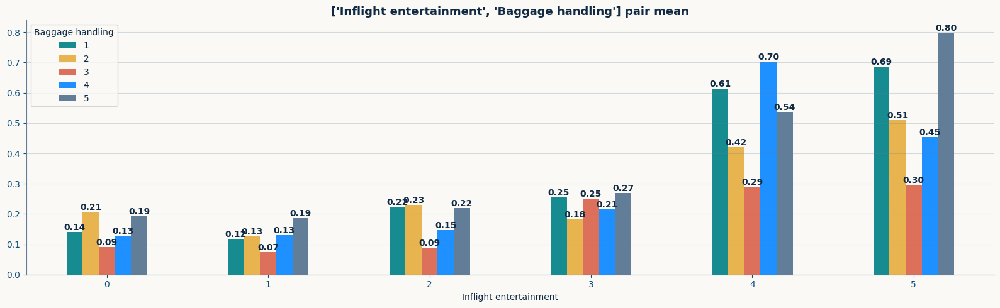


('Baggage handling', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Baggage handling']


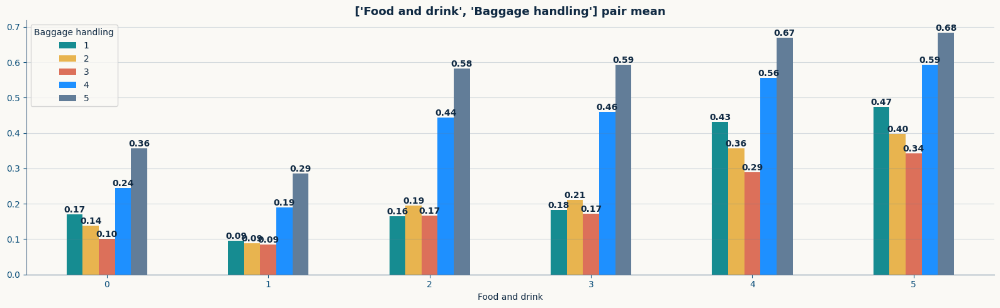


('Baggage handling', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Baggage handling']


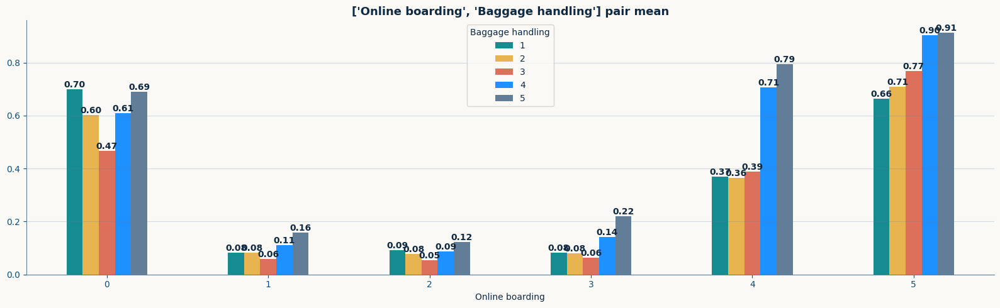


('Baggage handling', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Baggage handling']


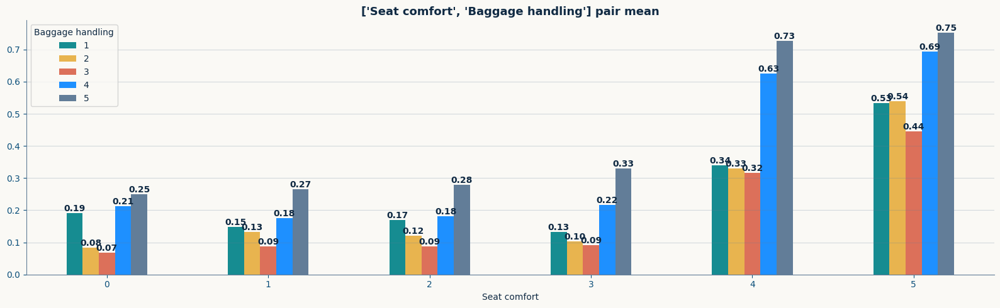


('Baggage handling', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Baggage handling']


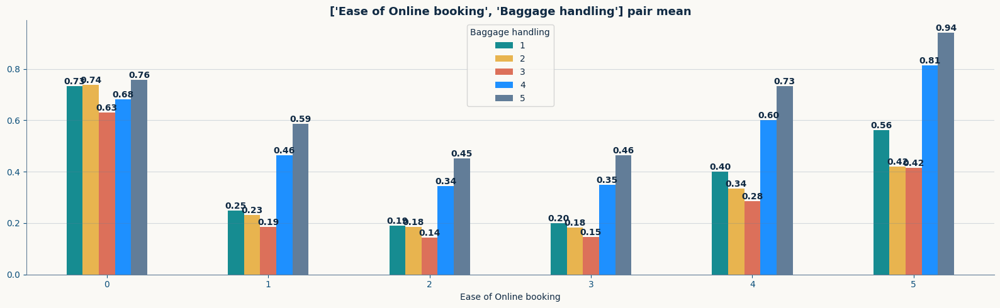


('Baggage handling', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Baggage handling']


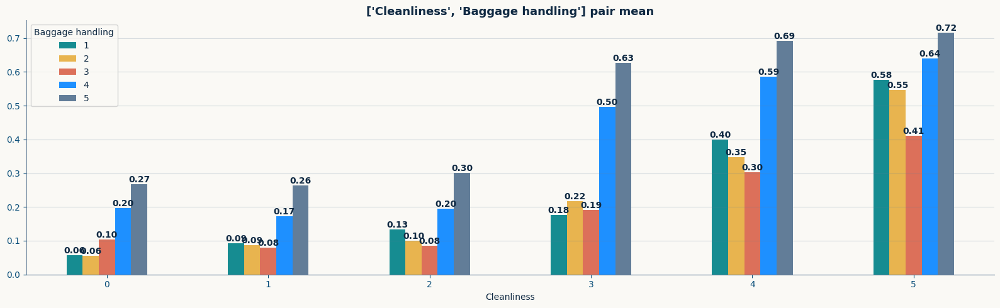


('Departure/Arrival time convenient', 'Gate location')| Gate location has more unique variables | ['Gate location', 'Departure/Arrival time convenient']


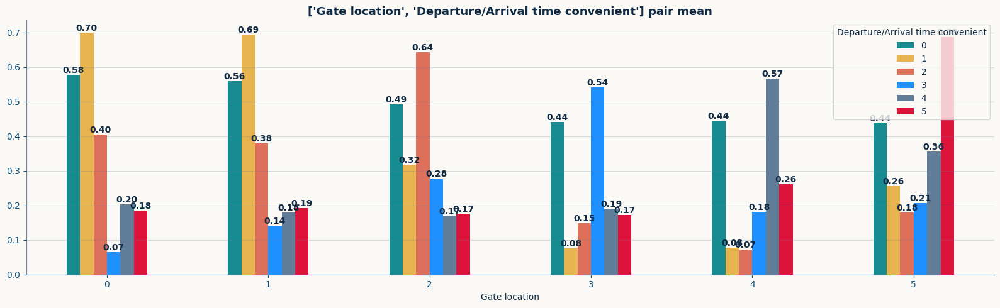


('Departure/Arrival time convenient', 'Inflight wifi service')| Inflight wifi service has more unique variables | ['Inflight wifi service', 'Departure/Arrival time convenient']


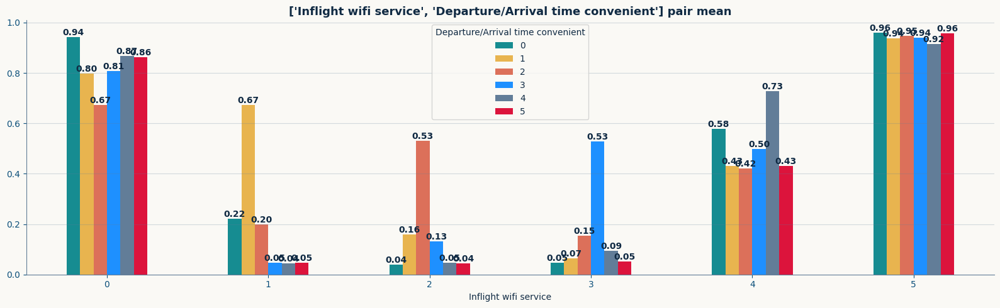


('Departure/Arrival time convenient', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Departure/Arrival time convenient']


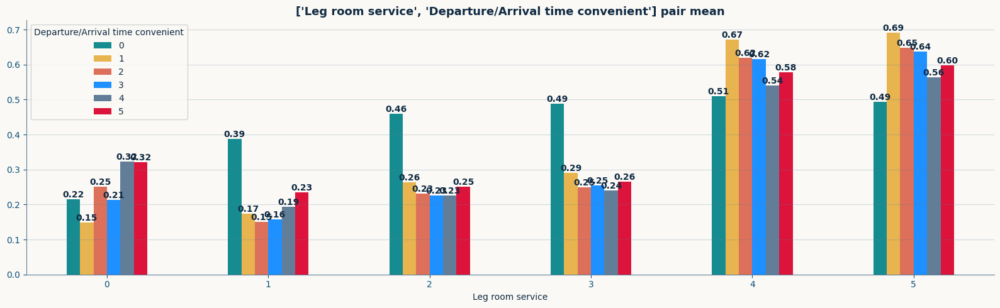


('Departure/Arrival time convenient', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Departure/Arrival time convenient']


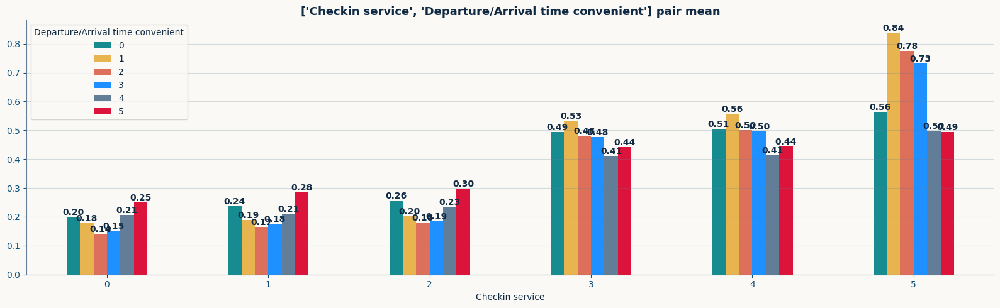


('Departure/Arrival time convenient', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Departure/Arrival time convenient']


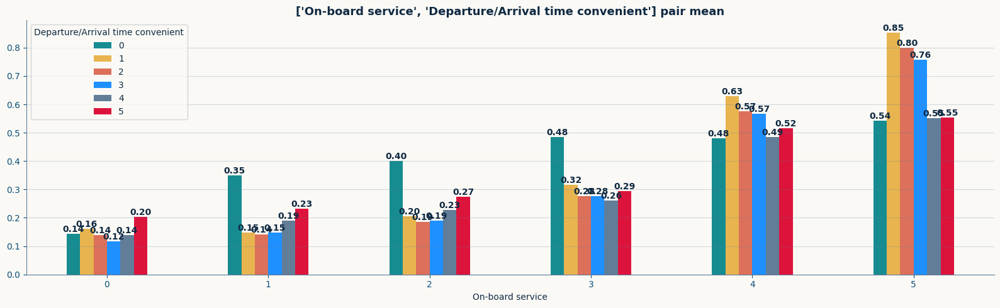


('Departure/Arrival time convenient', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Departure/Arrival time convenient']


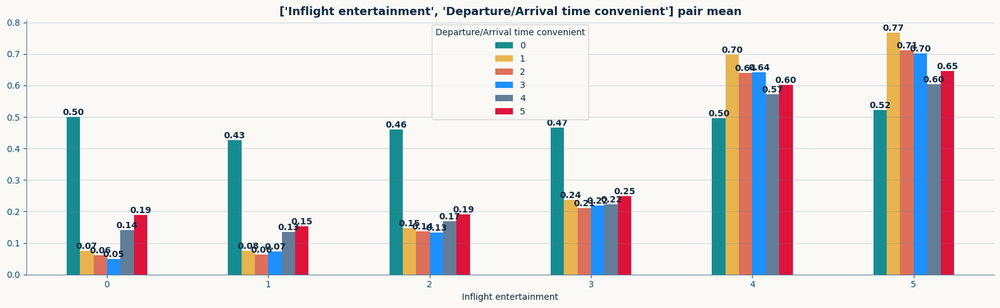


('Departure/Arrival time convenient', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Departure/Arrival time convenient']


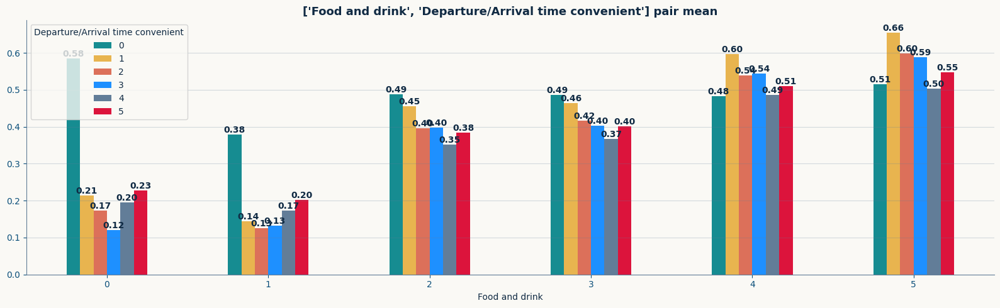


('Departure/Arrival time convenient', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Departure/Arrival time convenient']


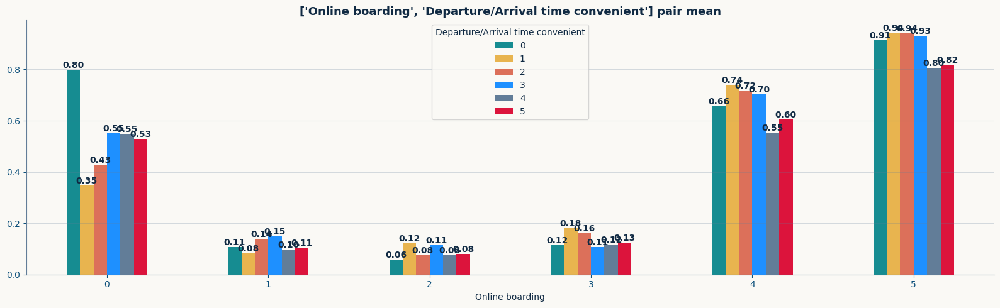


('Departure/Arrival time convenient', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Departure/Arrival time convenient']


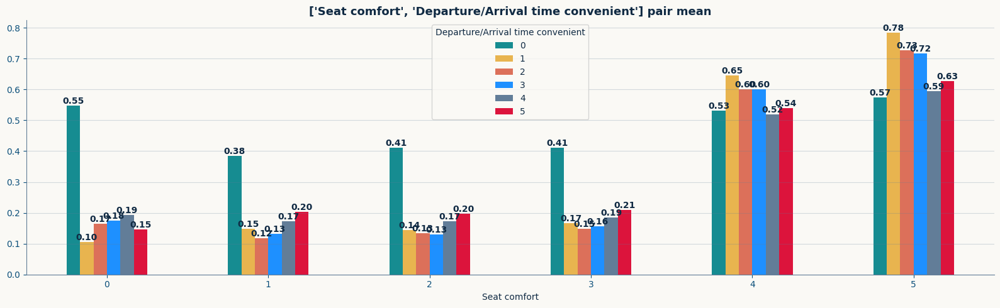


('Departure/Arrival time convenient', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Departure/Arrival time convenient']


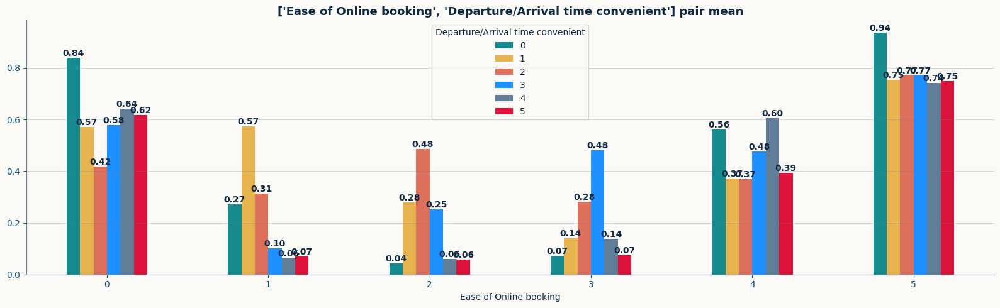


('Departure/Arrival time convenient', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Departure/Arrival time convenient']


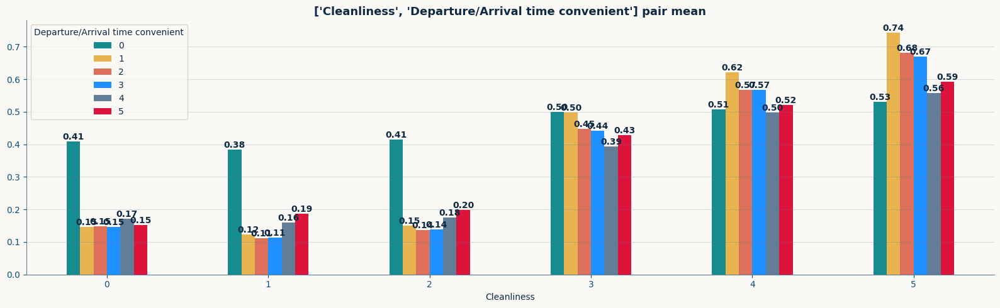


('Gate location', 'Inflight wifi service')| Inflight wifi service has more unique variables | ['Inflight wifi service', 'Gate location']


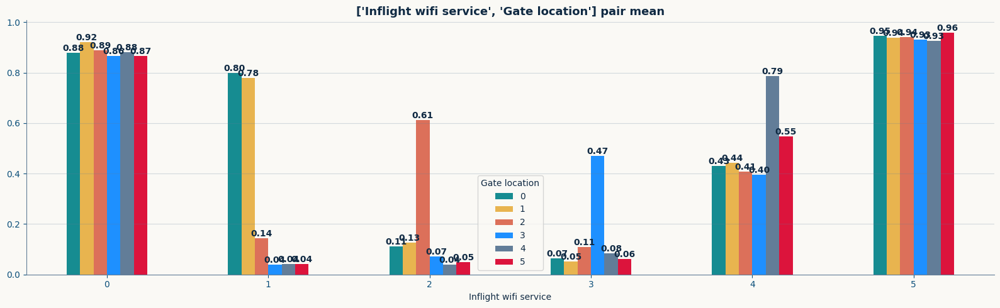


('Gate location', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Gate location']


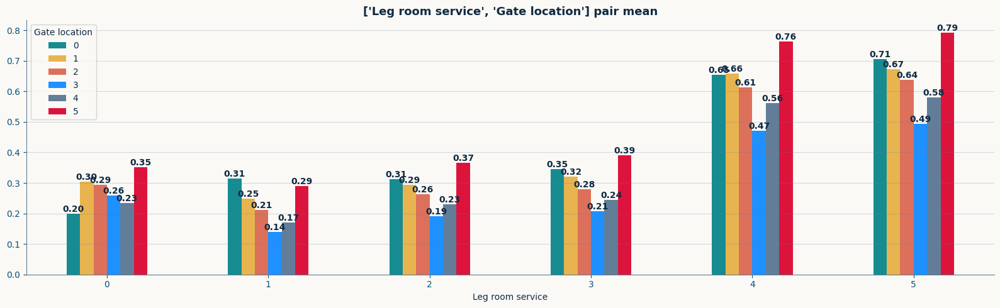


('Gate location', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Gate location']


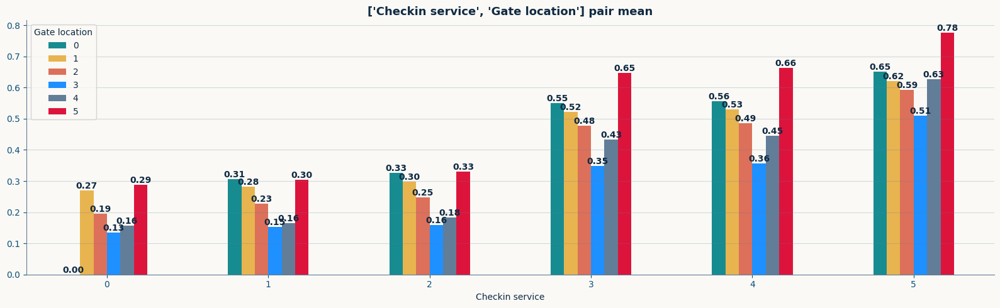


('Gate location', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Gate location']


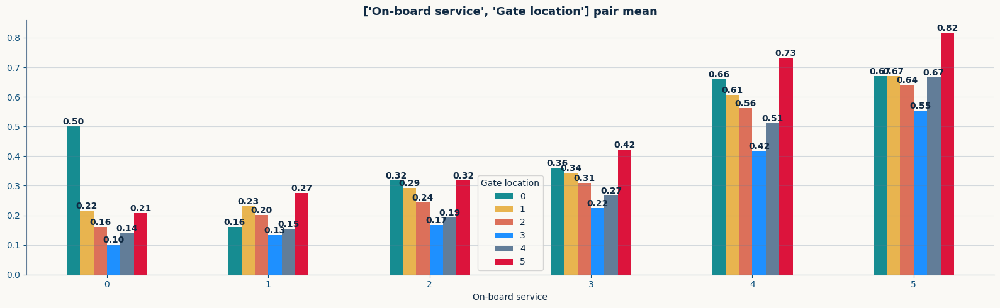


('Gate location', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Gate location']


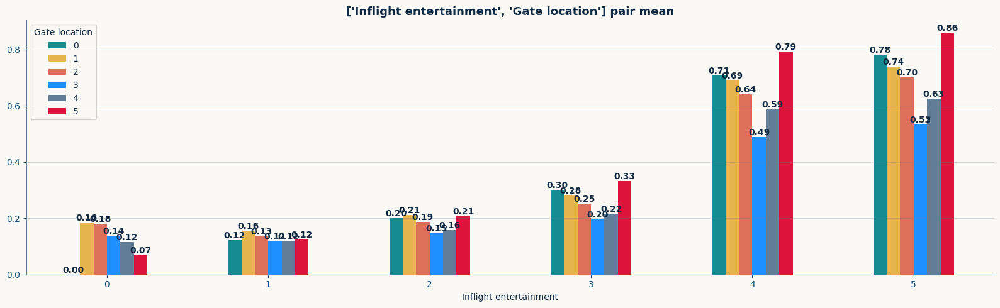


('Gate location', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Gate location']


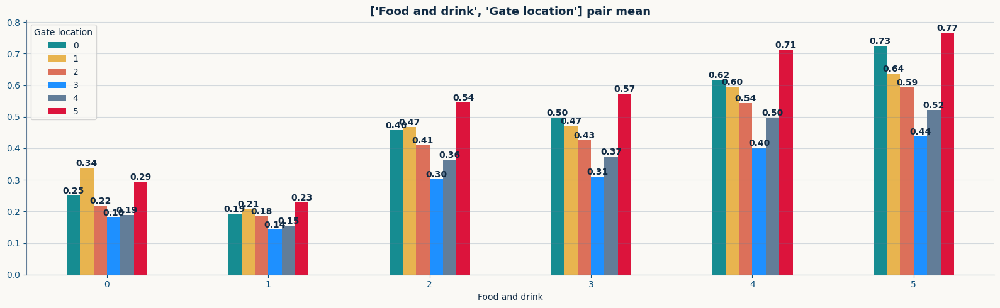


('Gate location', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Gate location']


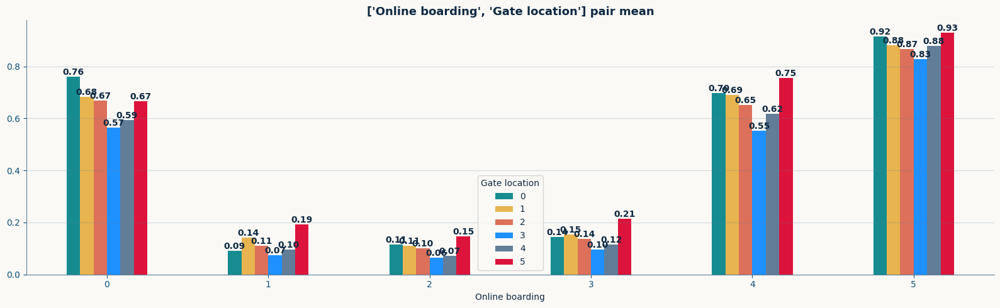


('Gate location', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Gate location']


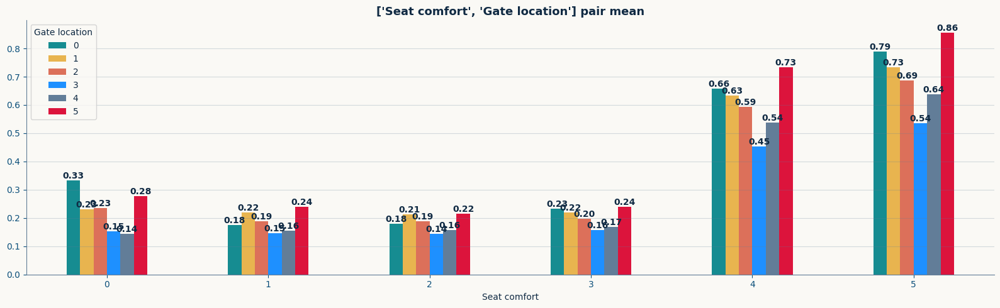


('Gate location', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Gate location']


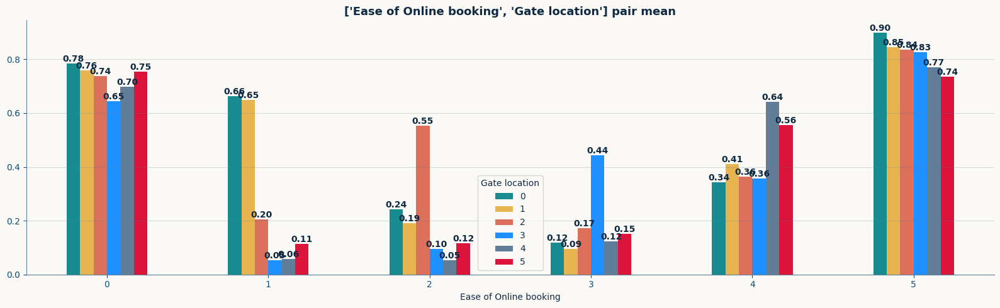


('Gate location', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Gate location']


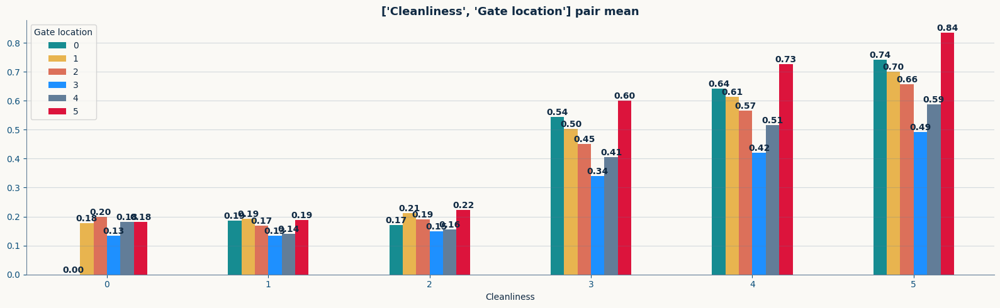


('Inflight wifi service', 'Leg room service')| Leg room service has more unique variables | ['Leg room service', 'Inflight wifi service']


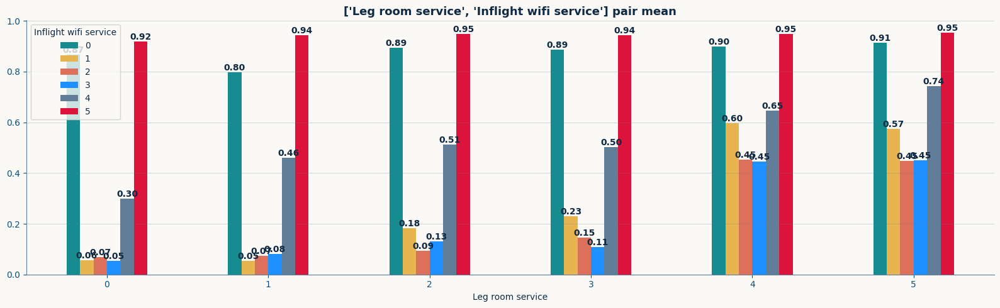


('Inflight wifi service', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Inflight wifi service']


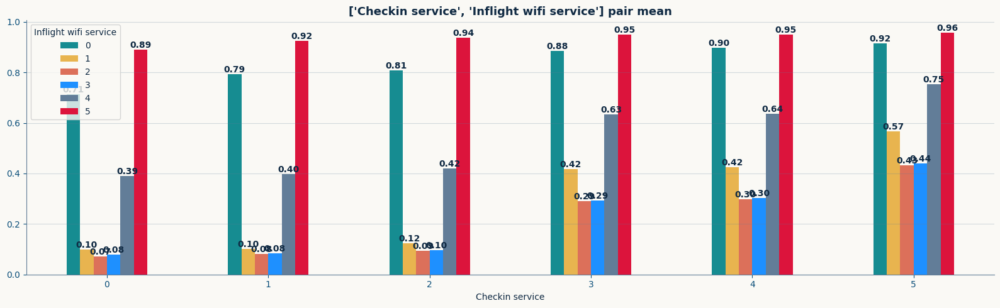


('Inflight wifi service', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Inflight wifi service']


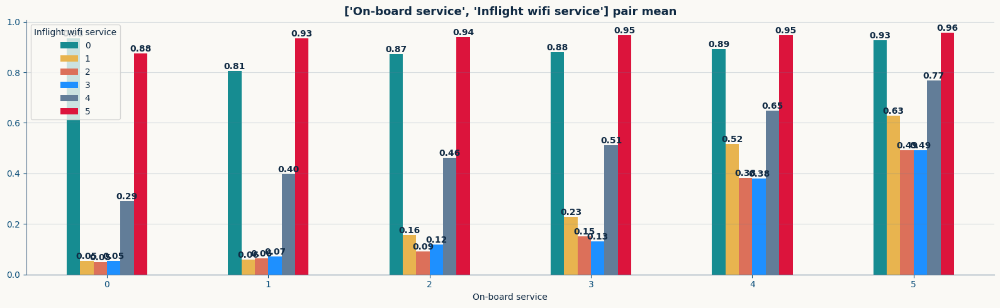


('Inflight wifi service', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Inflight wifi service']


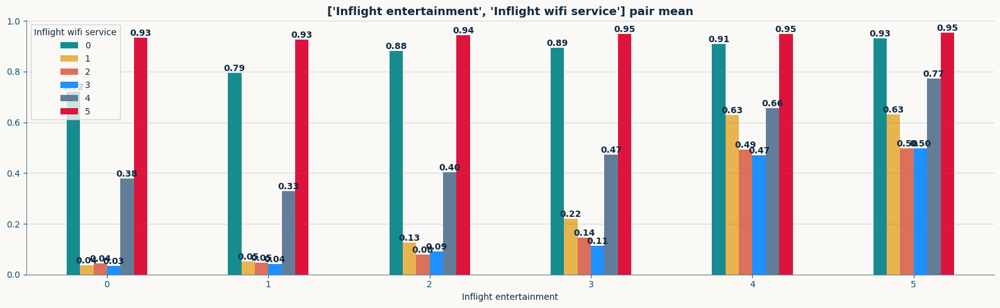


('Inflight wifi service', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Inflight wifi service']


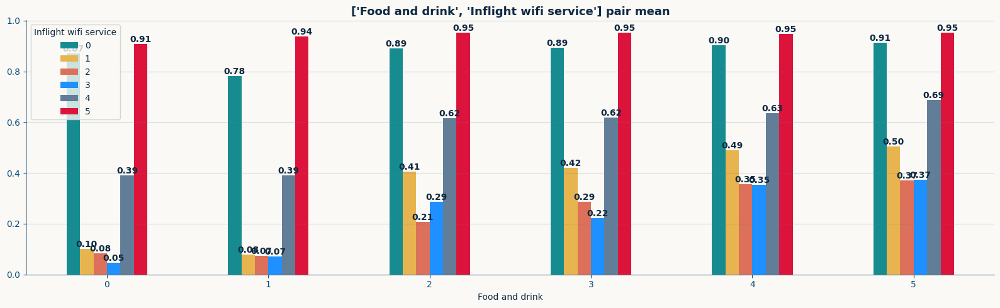


('Inflight wifi service', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Inflight wifi service']


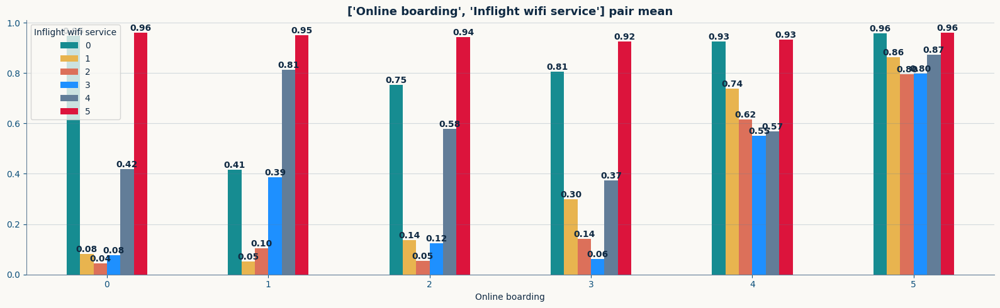


('Inflight wifi service', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Inflight wifi service']


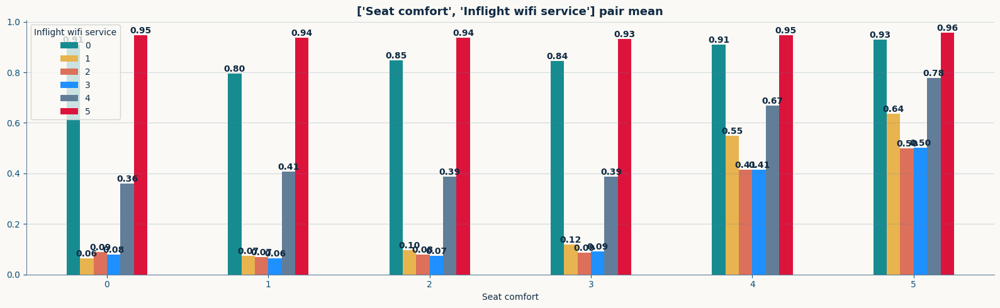


('Inflight wifi service', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Inflight wifi service']


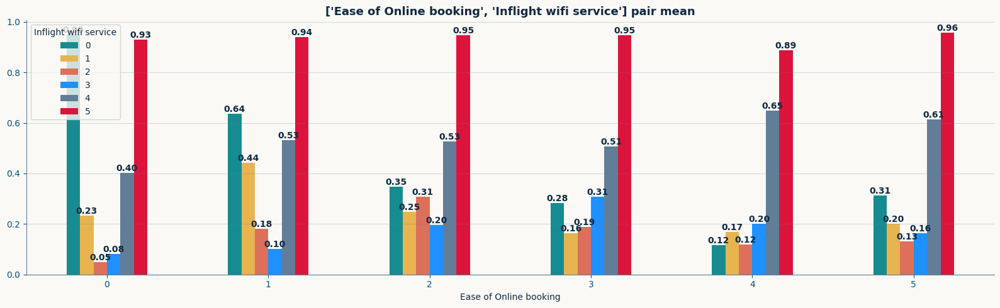


('Inflight wifi service', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Inflight wifi service']


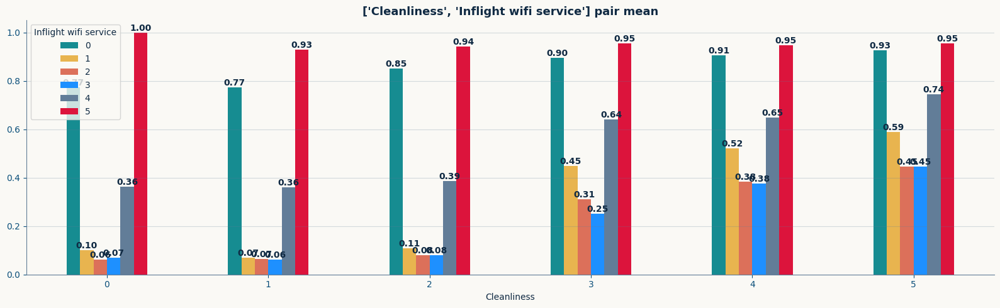


('Leg room service', 'Checkin service')| Checkin service has more unique variables | ['Checkin service', 'Leg room service']


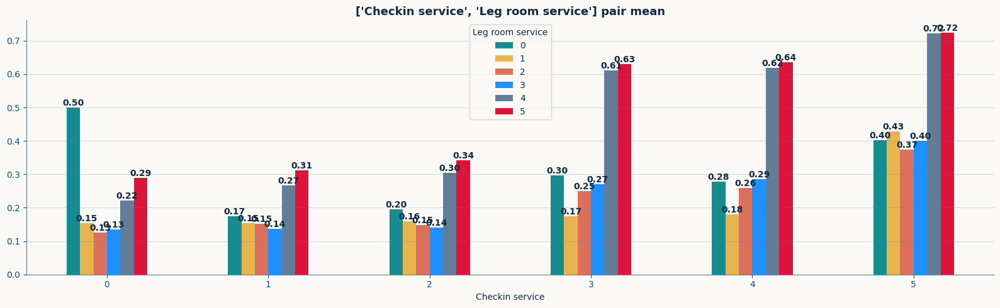


('Leg room service', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Leg room service']


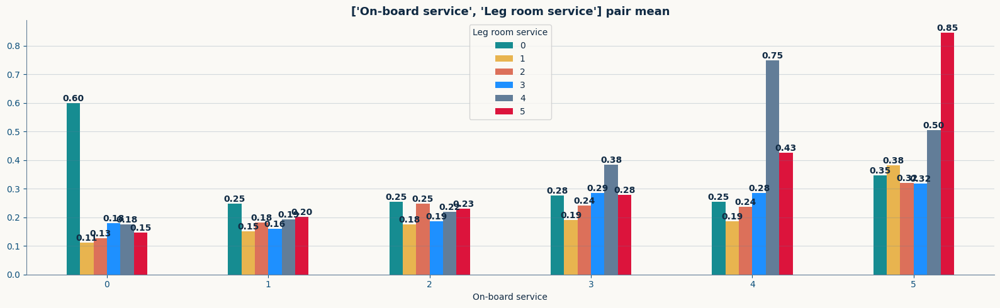


('Leg room service', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Leg room service']


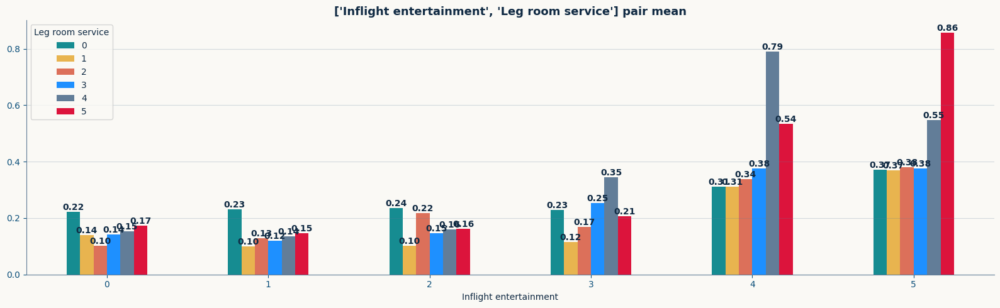


('Leg room service', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Leg room service']


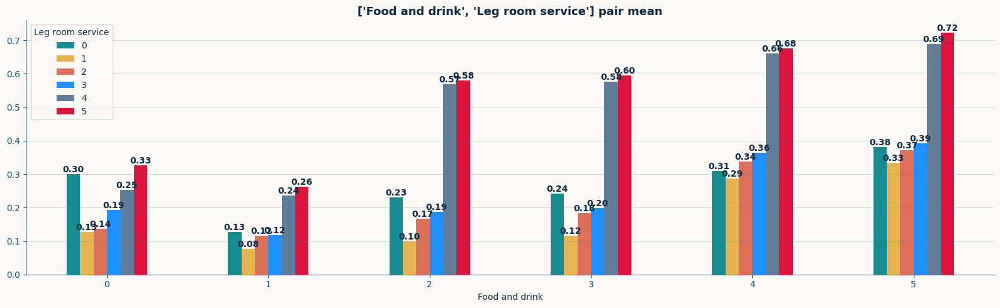


('Leg room service', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Leg room service']


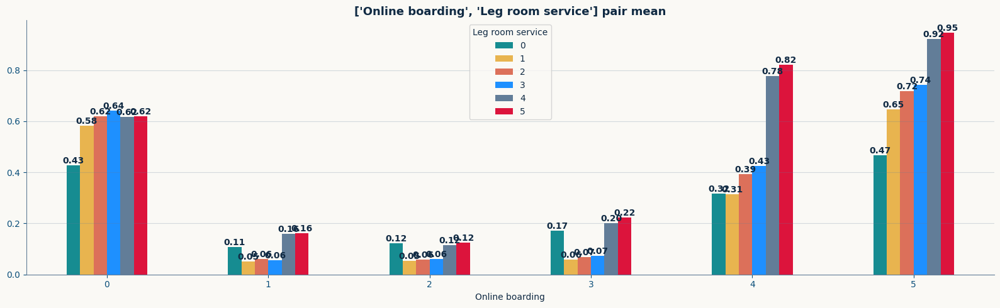


('Leg room service', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Leg room service']


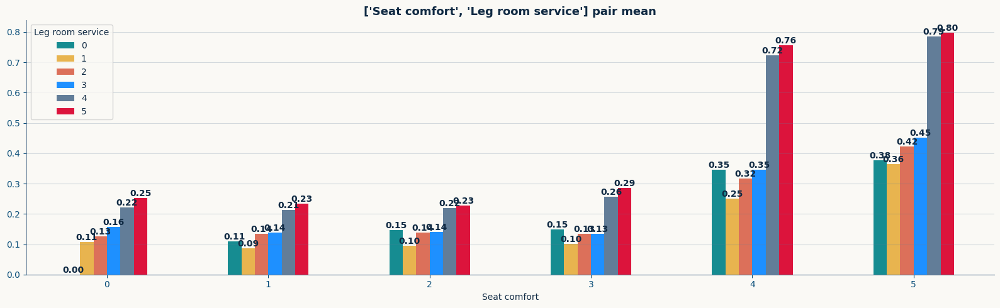


('Leg room service', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Leg room service']


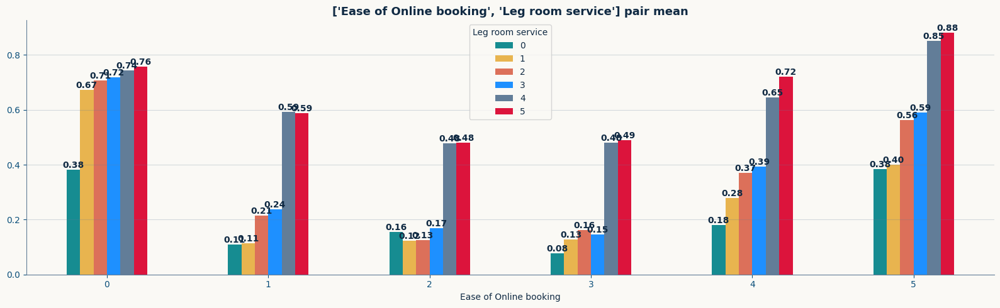


('Leg room service', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Leg room service']


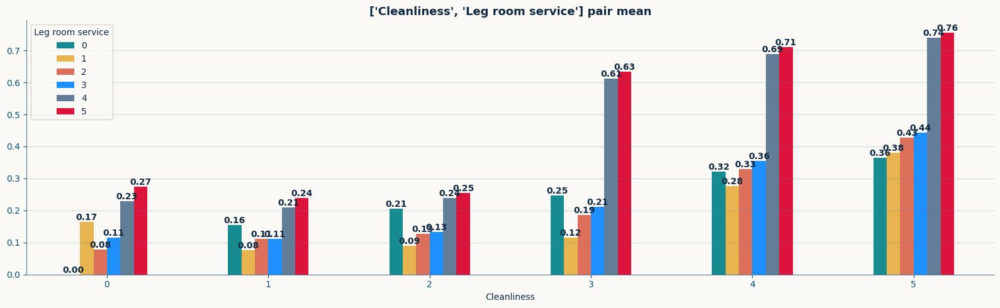


('Checkin service', 'On-board service')| On-board service has more unique variables | ['On-board service', 'Checkin service']


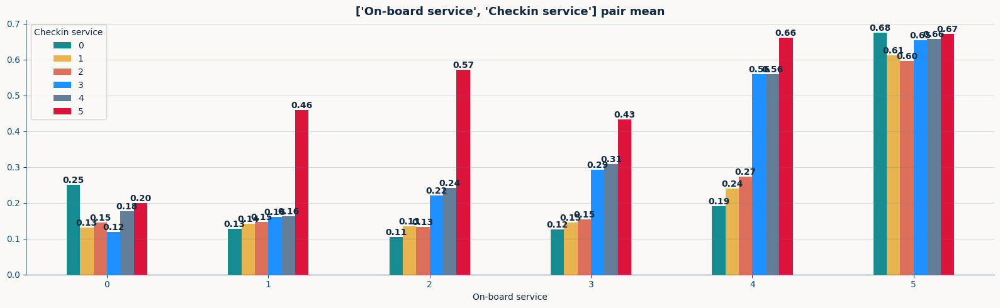


('Checkin service', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'Checkin service']


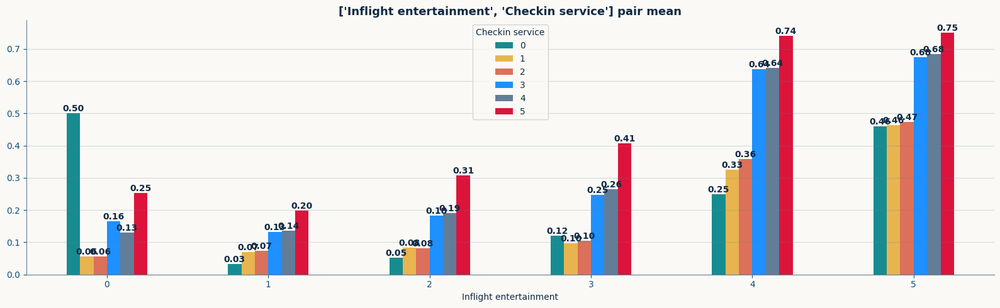


('Checkin service', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Checkin service']


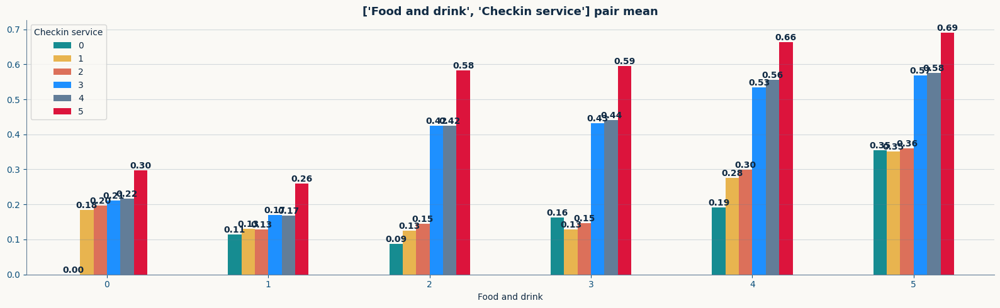


('Checkin service', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Checkin service']


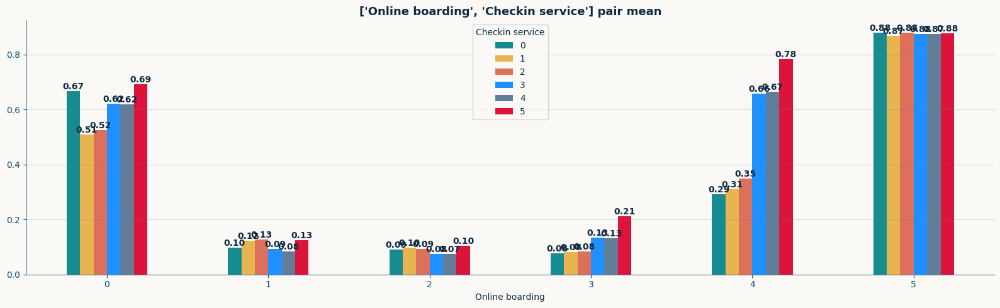


('Checkin service', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Checkin service']


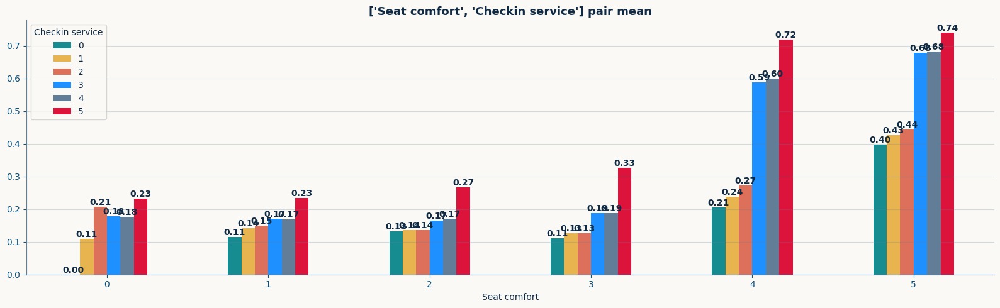


('Checkin service', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Checkin service']


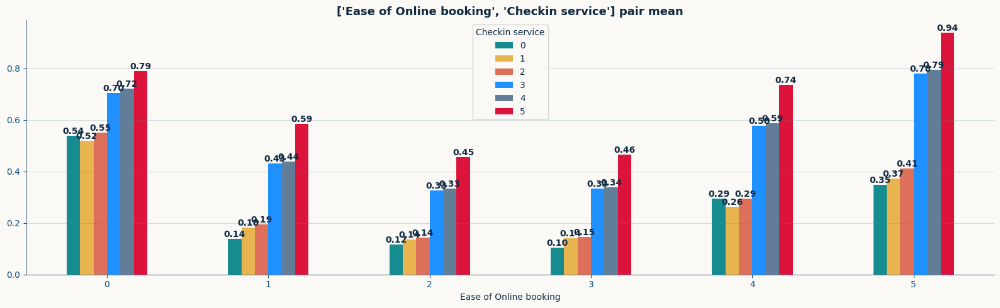


('Checkin service', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Checkin service']


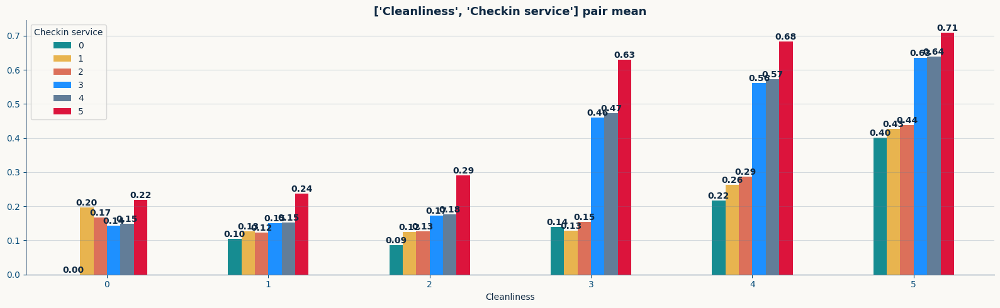


('On-board service', 'Inflight entertainment')| Inflight entertainment has more unique variables | ['Inflight entertainment', 'On-board service']


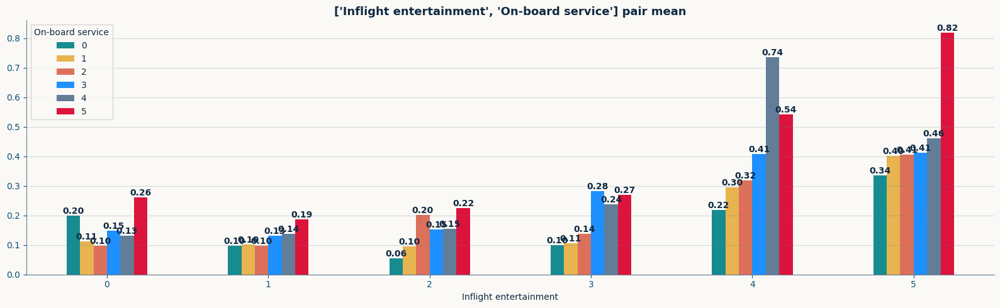


('On-board service', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'On-board service']


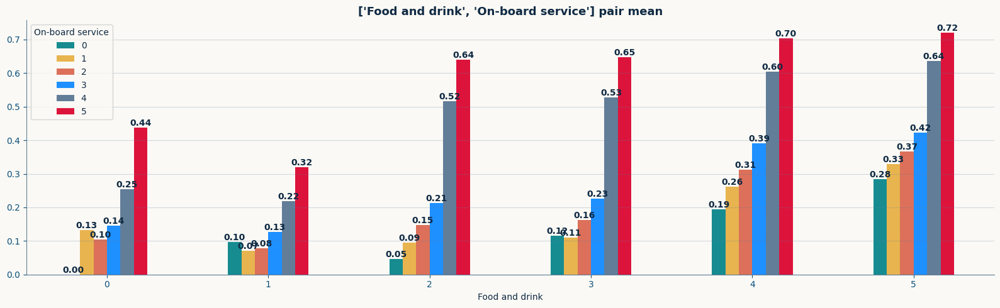


('On-board service', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'On-board service']


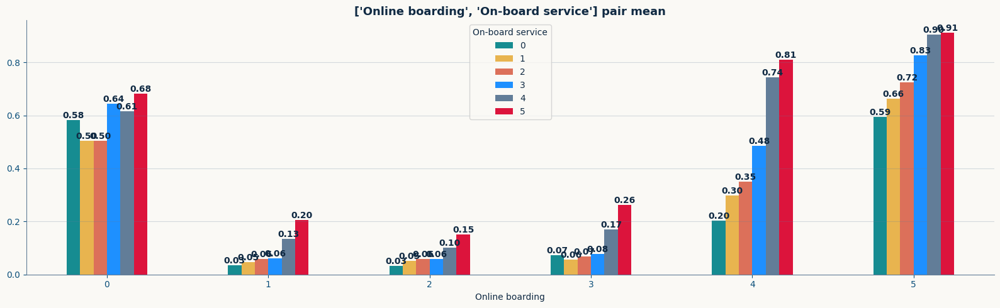


('On-board service', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'On-board service']


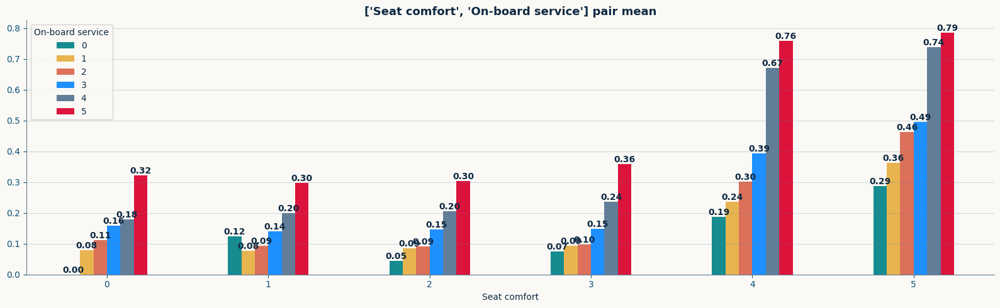


('On-board service', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'On-board service']


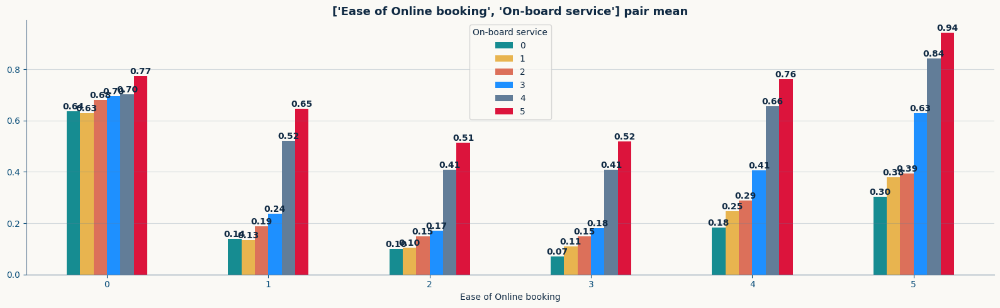


('On-board service', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'On-board service']


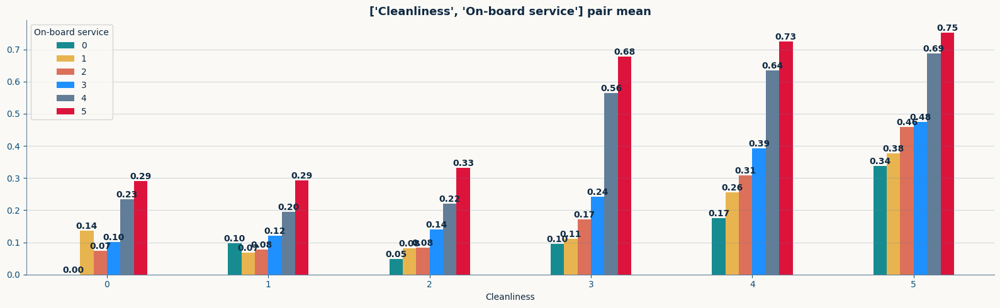


('Inflight entertainment', 'Food and drink')| Food and drink has more unique variables | ['Food and drink', 'Inflight entertainment']


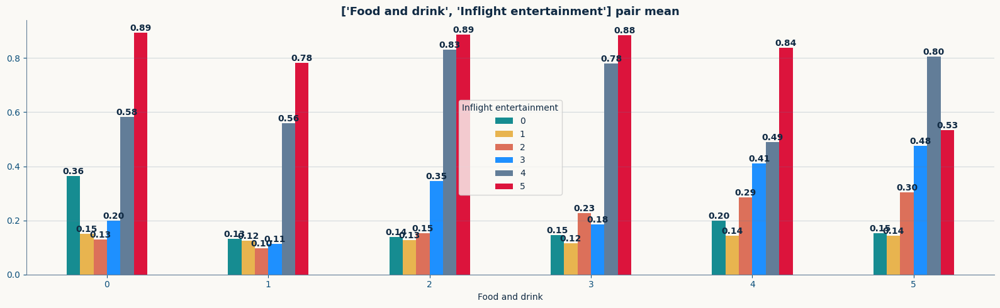


('Inflight entertainment', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Inflight entertainment']


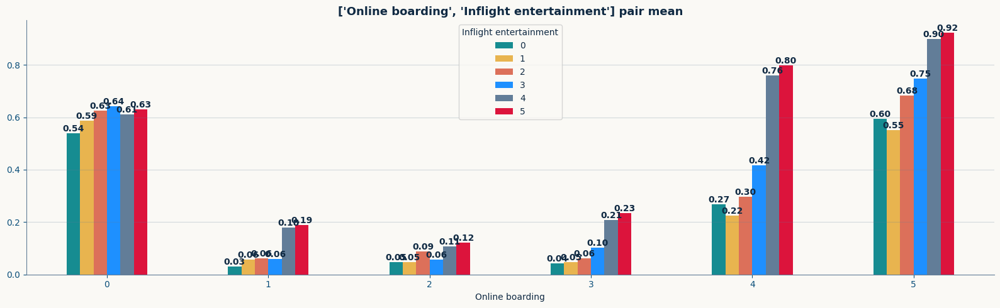


('Inflight entertainment', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Inflight entertainment']


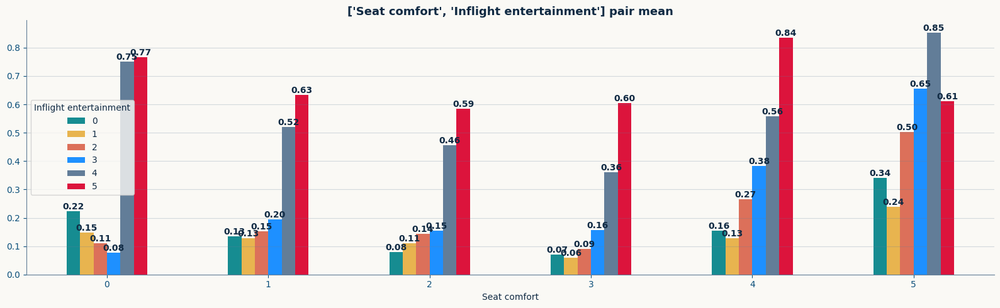


('Inflight entertainment', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Inflight entertainment']


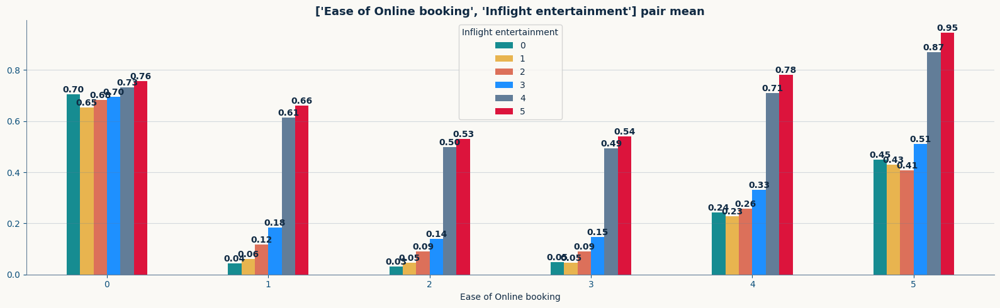


('Inflight entertainment', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Inflight entertainment']


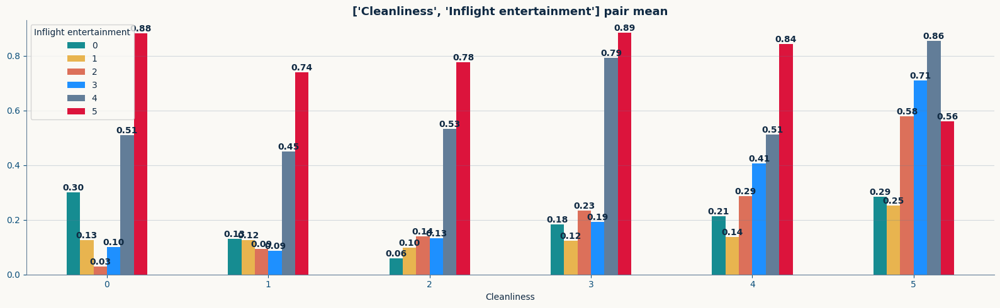


('Food and drink', 'Online boarding')| Online boarding has more unique variables | ['Online boarding', 'Food and drink']


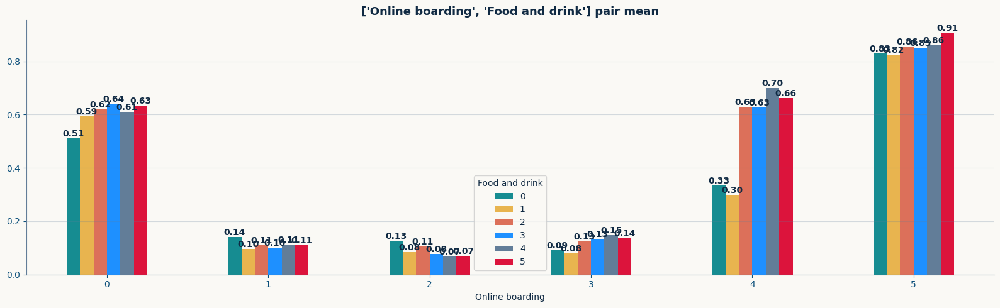


('Food and drink', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Food and drink']


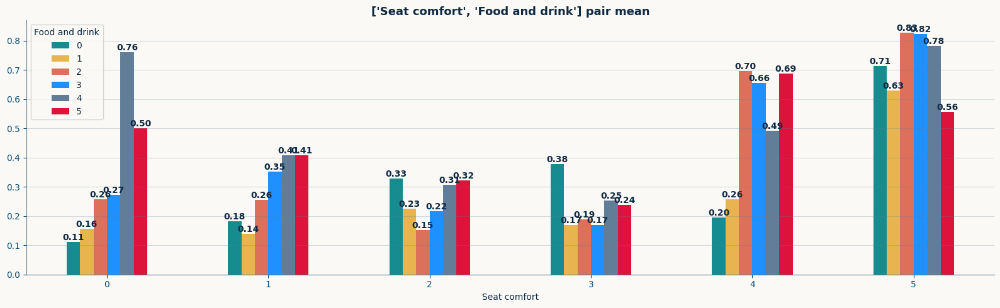


('Food and drink', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Food and drink']


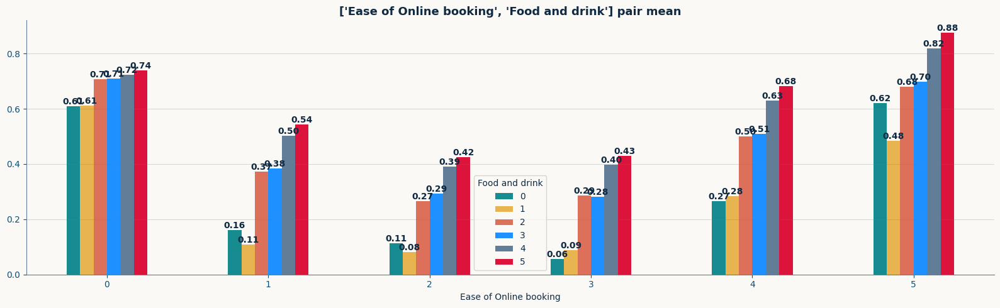


('Food and drink', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Food and drink']


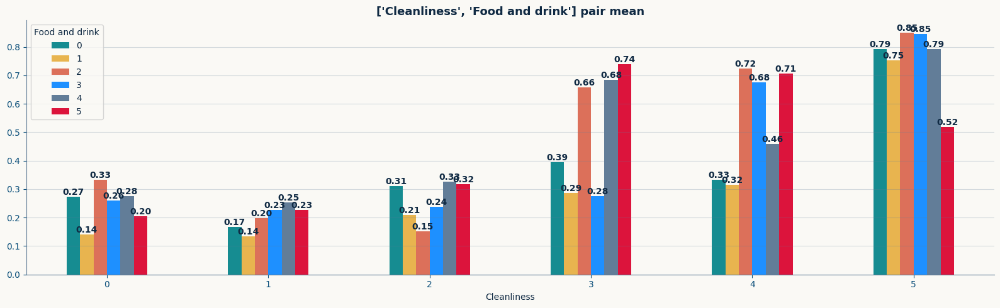


('Online boarding', 'Seat comfort')| Seat comfort has more unique variables | ['Seat comfort', 'Online boarding']


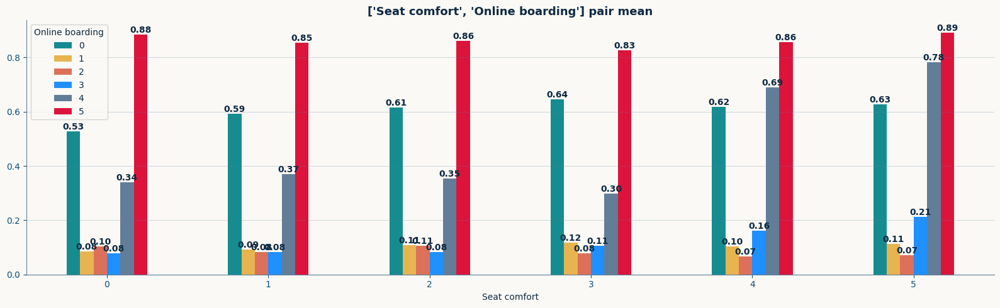


('Online boarding', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Online boarding']


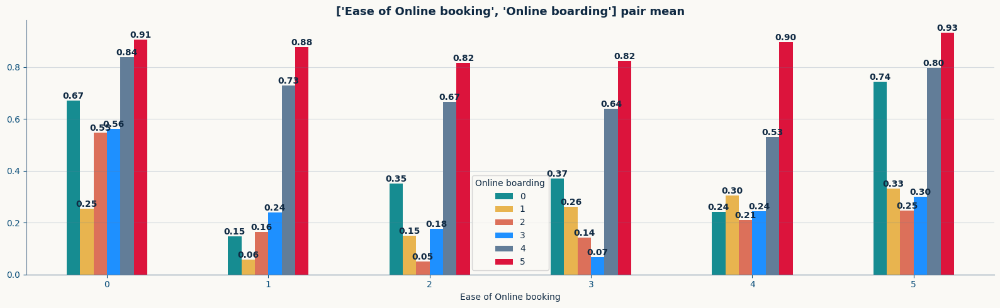


('Online boarding', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Online boarding']


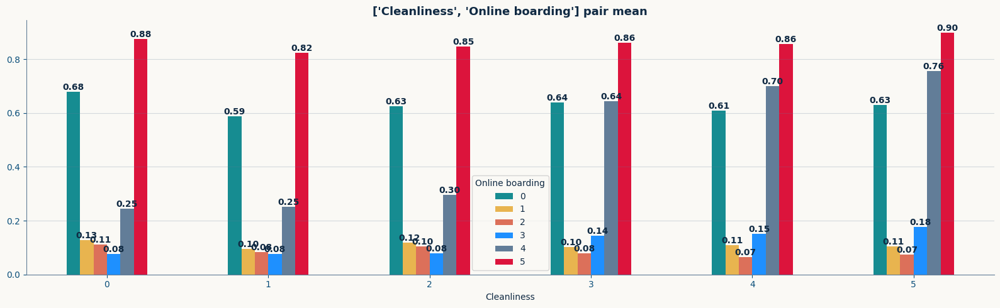


('Seat comfort', 'Ease of Online booking')| Ease of Online booking has more unique variables | ['Ease of Online booking', 'Seat comfort']


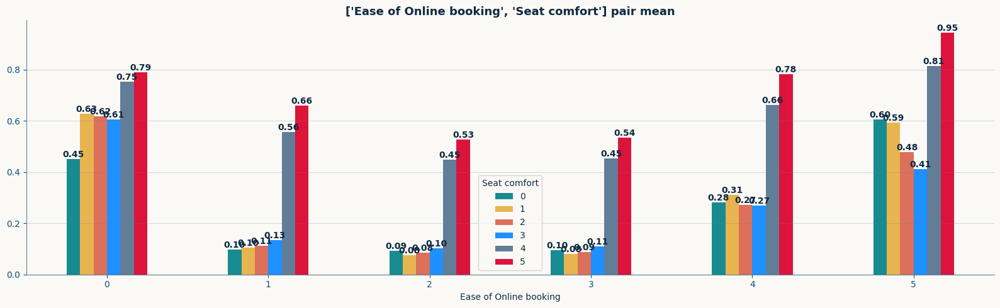


('Seat comfort', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Seat comfort']


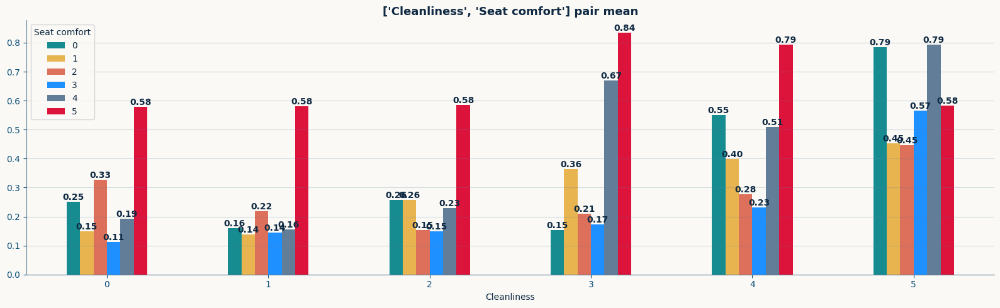


('Ease of Online booking', 'Cleanliness')| Cleanliness has more unique variables | ['Cleanliness', 'Ease of Online booking']


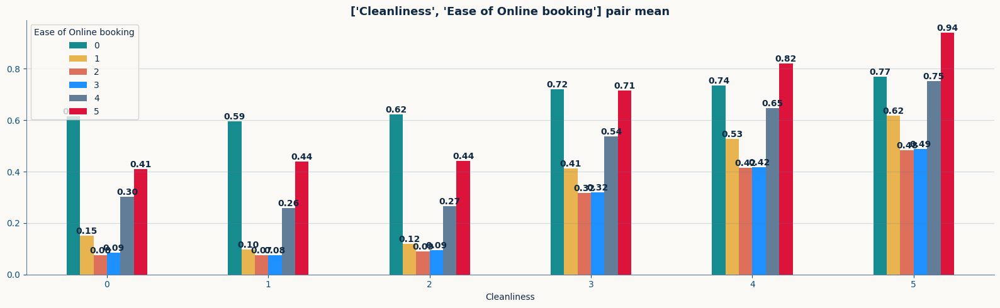

In [27]:
## -- Pairwise feature-mean (binary target) --
PAIRS = itertools.combinations(n_unique[n_unique < 10].index, 2)

for i, combo in enumerate(PAIRS):
    if train[combo[0]].nunique() > train[combo[1]].nunique():
        print(combo, end='')
        print(f'| {combo[0]} has more unique variables | ', end='')
        combo = [combo[0], combo[1]]
        print(combo)
    else:
        print(combo, end='')
        print(f'| {combo[1]} has more unique variables | ', end='')
        combo = [combo[1], combo[0]]
        print(combo)

    group_mean = train.groupby(combo)[TARGET].mean().unstack()
    ax1 = group_mean.plot.bar(figsize=(16, 5))
    ax1.set_title(f'{combo} pair mean', fontweight='semibold')
    ax1.tick_params('x', rotation=0)
    ax1.grid(axis='x')

    for container in ax1.containers: # Show values on bars
        ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

    plt.tight_layout()
    plt.show()
    print()

In [28]:
n_unique

Customer Type                           2
Type of Travel                          2
Gender                                  2
Class                                   3
Baggage handling                        5
Departure/Arrival time convenient       6
Gate location                           6
Inflight wifi service                   6
Leg room service                        6
Checkin service                         6
On-board service                        6
Inflight entertainment                  6
Food and drink                          6
Online boarding                         6
Seat comfort                            6
Ease of Online booking                  6
Cleanliness                             6
Age                                    75
Departure Delay in Minutes            167
Arrival Delay in Minutes              168
Flight Distance                      3474
dtype: int64

In [29]:
# try:
#     from labellines import labelLines
# except:
#     !uv pip install --system matplotlib-label-lines
#     from labellines import labelLines

In [30]:
# ## -- Pairwise 'Position' against others --
# PAIRS = itertools.product(['gender'], n_unique[n_unique <= 10].index)
# PLOT_LINE = True

# for i, combo in enumerate(PAIRS):
#     # fig, axs = plt.subplots(1, 1, figsize=(15, 5), facecolor='#0f0f1a')
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(16, 5), marker='o')
#     else:
#         ax1 = group_mean.plot.bar(figsize=(16, 5))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=0)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

In [31]:
# ## -- Pairwise 'Race' against others --
# PAIRS = itertools.product(['age'], n_unique[n_unique < 10].index)
# PLOT_LINE = False

# for i, combo in enumerate(PAIRS):
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(18, 8))
#     else:
#         ax1 = group_mean.plot.bar(figsize=(18, 8))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=90)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

In [32]:
# ## -- Pairwise 'Position_Change' against others --
# PAIRS = itertools.product(['stress_level'], n_unique[n_unique < 10].index)
# PLOT_LINE = True

# for i, combo in enumerate(PAIRS):
#     # fig, axs = plt.subplots(1, 1, figsize=(15, 5), facecolor='#0f0f1a')
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(16, 5), marker='o')
#     else:
#         ax1 = group_mean.plot.bar(figsize=(16, 5))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=0)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

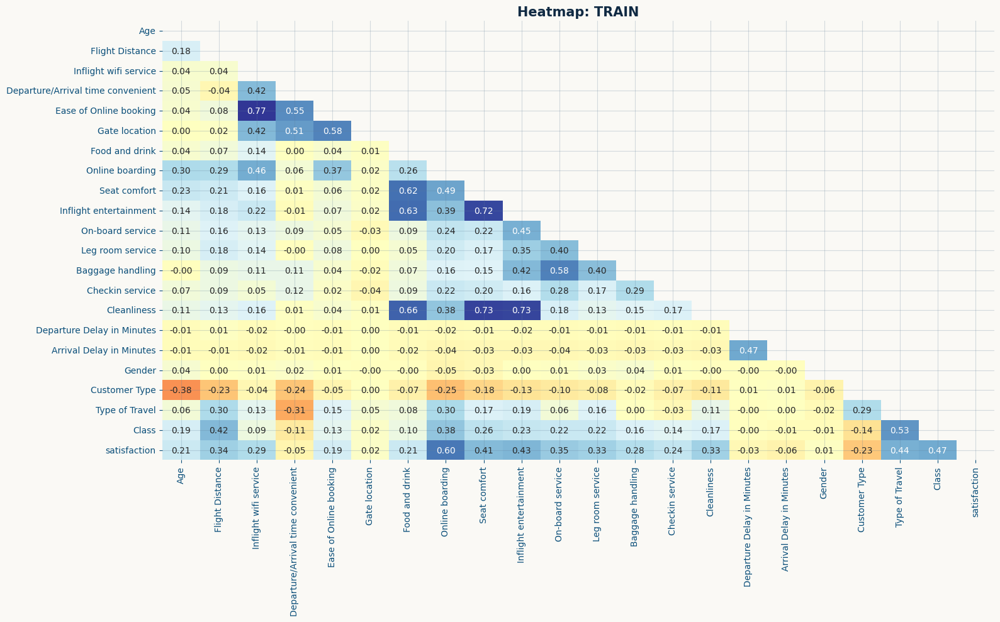

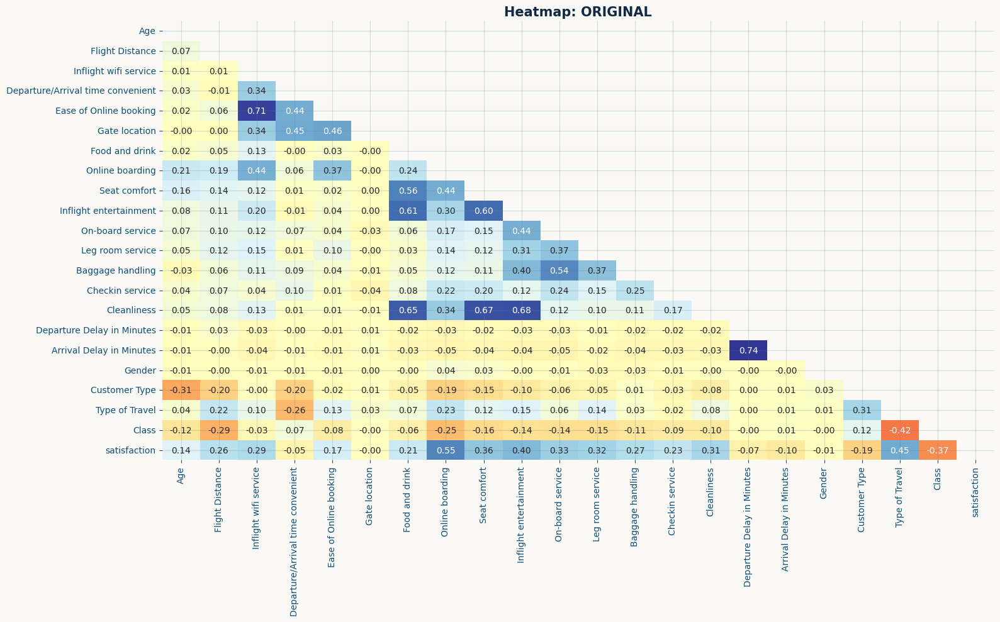

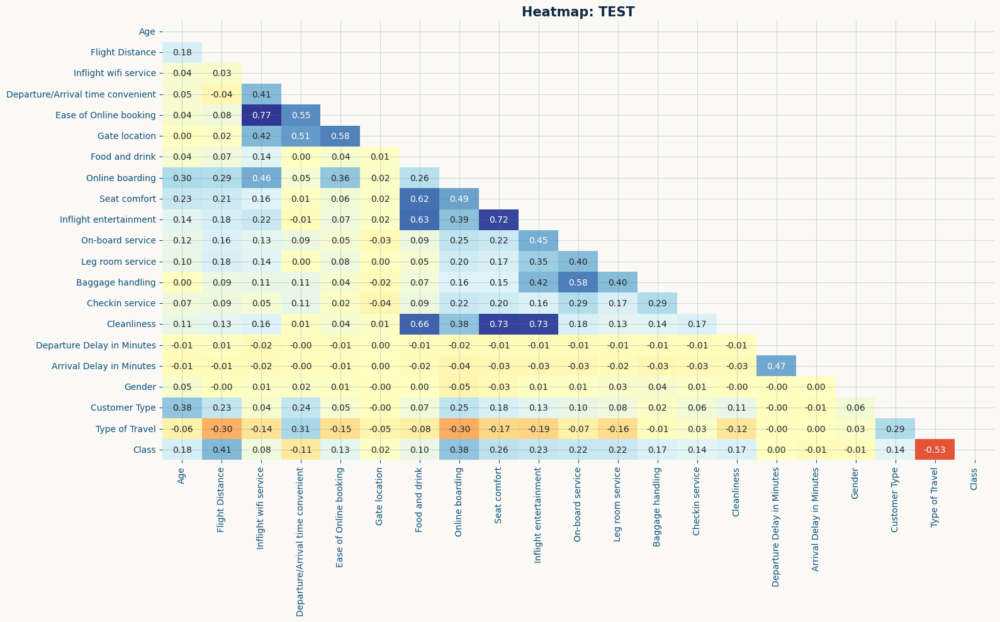

In [33]:
def plot_heatmap(df_, name='Data'):
    df = df_.copy()
    cat_cols = [c for c in df.columns if df[c].dtype in ['str', 'object', 'category']]
    for c in cat_cols:
        df[c] = pd.factorize(df[c])[0]

    CORR = df.corr('spearman')
    plt.figure(figsize=(16, 10))
    sns.heatmap(CORR, mask=np.triu(CORR), annot=True, cmap='RdYlBu', cbar=False, fmt='.2f', center=0)
    plt.title(f"Heatmap: {name}", size=15, weight='semibold')
    plt.tight_layout()
    plt.show()

    del df, CORR

plot_heatmap(train, 'TRAIN')
plot_heatmap(orig, 'ORIGINAL')
plot_heatmap(test, 'TEST')

In [34]:
# ## -- VIOLIN PLOT --
# plt.figure(figsize=(18, 5))
# for i, col in enumerate(num_cols):
#     plt.subplot(1, len(num_cols), i+1)
#     sns.violinplot(train[col])

# plt.tight_layout()
# plt.show()

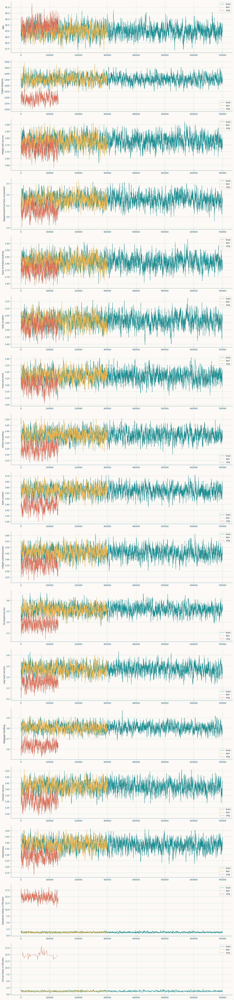

In [35]:
## -- Drift check--
rolling = 1000
line_w = 0.75

plt.figure(figsize=(16, len(num_cols) * 4))
for i, col in enumerate(num_cols):
    plt.subplot(len(num_cols), 1, i + 1)
    sns.lineplot(train[col].rolling(rolling).mean(), linewidth=line_w, label='train')
    sns.lineplot(test[col].rolling(rolling).mean(),  linewidth=line_w, label='test')
    sns.lineplot(orig[col].rolling(rolling).mean(),  linewidth=line_w, label='orig')

plt.legend()
plt.tight_layout(h_pad=2)
plt.show()

In [36]:
# %%time

# ## -- FEATURE MUTUAL INFO --
# mutual_info = mutual_info_regression(train[base_cols], train[TARGET])
# mutual_info_df = pd.DataFrame.from_dict(
#     dict(zip(test.columns.tolist(), list(mutual_info))),
#     orient='index', columns=['Score'],
# ).sort_values(by='Score', ascending=False)

# plt.figure(figsize=(18, 8))
# sns.barplot(data=mutual_info_df, x='Score', y=mutual_info_df.index)
# plt.title('-- Univariate Analysis: Top predictors --')
# plt.show()

## 1. Kolmogorov-Smirnov (K-S) Drift check

In [37]:
from scipy.stats import ks_2samp

def ks_driftcheck(df_1, df_2, df2_mame: str, features):
    df_train = df_1.copy()
    df_test  = df_2.copy()

    ks_stats_all = []
    cols = []
    threshold = 0.05

    print(f"{'feature':>25}\t{'ks-stat':>10}\t{'drift'}")
    print(f"{'-'*20:>25}\t{'-------':>10}\t{'-------'}")
    RED = '\033[33m'
    for c in features:
        ks_stat, p_val = np.round(ks_2samp(df_train[c].values, df_test[c].values), 6)
        if ks_stat >= threshold:
            print(f"{CFG['YELLOW']}{c:>25}\t{ks_stat:>10}\t⚠️ Drift{CFG['RESET']}")
        else:
            print(f"{c:>25}\t{ks_stat:>10}\t✅ Safe!")

        ks_stats_all.append(ks_stat)
        cols.append(c)

    print()
    plt.barh(cols, ks_stats_all, color=[CRIM if c >= threshold else MUTED for c in ks_stats_all])
    plt.axvline(x=threshold, linestyle="--", color=GOLD, label=f"Drift threshold: {threshold}")
    plt.title(f"(K-S) drift test: Train vs {df2_mame}", loc="left", pad=26)
    plt.legend()
    plt.show()

    gc.collect()

                  feature	   ks-stat	drift
     --------------------	   -------	-------
                      Age	  0.001161	✅ Safe!
          Flight Distance	  0.000945	✅ Safe!
    Inflight wifi service	  0.000653	✅ Safe!
Departure/Arrival time convenient	  0.001423	✅ Safe!
   Ease of Online booking	   0.00078	✅ Safe!
            Gate location	  0.000407	✅ Safe!
           Food and drink	  0.002169	✅ Safe!
          Online boarding	   0.00087	✅ Safe!
             Seat comfort	  0.001369	✅ Safe!
   Inflight entertainment	  0.001233	✅ Safe!
         On-board service	  0.002164	✅ Safe!
         Leg room service	  0.001608	✅ Safe!
         Baggage handling	  0.001452	✅ Safe!
          Checkin service	  0.001204	✅ Safe!
              Cleanliness	  0.002747	✅ Safe!
Departure Delay in Minutes	  0.000669	✅ Safe!
 Arrival Delay in Minutes	       nan	✅ Safe!
                   Gender	  0.001536	✅ Safe!
            Customer Type	  0.001421	✅ Safe!
           Type of Travel	  0.000161	✅ Safe!
   

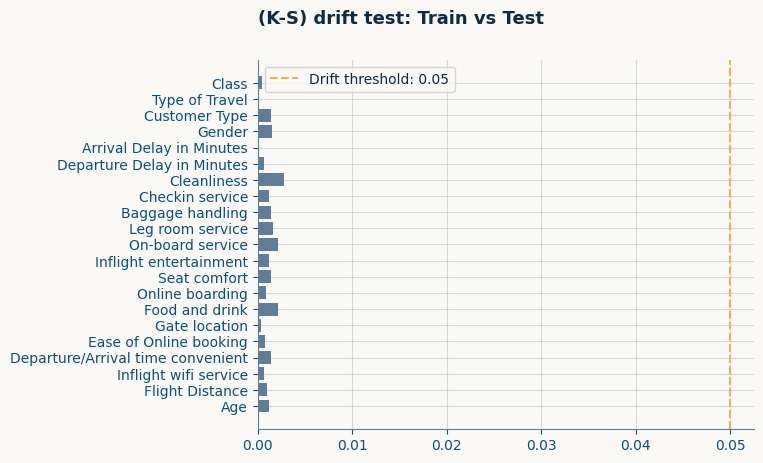

In [38]:
## -- Drift test for TRAIN & TEST --
ks_driftcheck(train, test, "Test", base_cols)

                  feature	   ks-stat	drift
     --------------------	   -------	-------
                      Age	  0.035245	✅ Safe!
          Flight Distance	  0.216779	⚠️ Drift
    Inflight wifi service	  0.029343	✅ Safe!
Departure/Arrival time convenient	  0.028183	✅ Safe!
   Ease of Online booking	  0.030724	✅ Safe!
            Gate location	  0.018549	✅ Safe!
           Food and drink	  0.021779	✅ Safe!
          Online boarding	  0.030431	✅ Safe!
             Seat comfort	  0.043226	✅ Safe!
   Inflight entertainment	   0.03439	✅ Safe!
         On-board service	  0.046442	✅ Safe!
         Leg room service	  0.038169	✅ Safe!
         Baggage handling	  0.065621	⚠️ Drift
          Checkin service	  0.044591	✅ Safe!
              Cleanliness	  0.032126	✅ Safe!
Departure Delay in Minutes	  0.343035	⚠️ Drift
 Arrival Delay in Minutes	       nan	✅ Safe!
                   Gender	   0.01005	✅ Safe!
            Customer Type	  0.007794	✅ Safe!
           Type of Travel	  0.020417	✅ Safe!


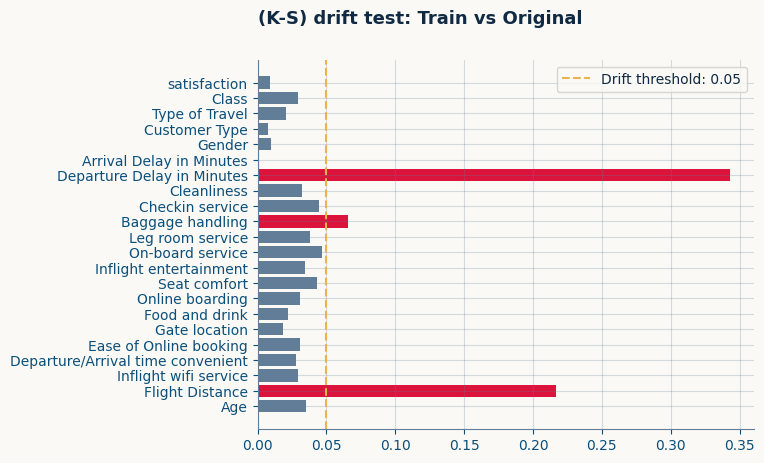

In [39]:
## -- Drift test for TRAIN & ORIGINAL --
ks_driftcheck(train, orig, "Original", base_cols+[TARGET])

In [40]:
# try:
#     from evidently import Dataset, DataDefinition, Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset
# except:
#     !uv pip install --system evidently
#     from evidently import Dataset, DataDefinition, Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset

# def evid_driftcheck(df_1, df_2, features, nums, cats):

#     schema = DataDefinition(
#         numerical_columns=nums,
#         categorical_columns=cats,
#         # classification=[BinaryClassification(target="target", prediction_labels="prediction")]
#     )

#     train_df = Dataset.from_pandas(df_1[features], data_definition=schema)
#     test_df  = Dataset.from_pandas(df_2[features], data_definition=schema)

#     report   = Report([DataDriftPreset()])
#     my_eval  = report.run(train_df, test_df)

#     return my_eval

# print("evidently drift check function ready!")

In [41]:
# ## -- Drift: 'train' & 'test' datasets --
# drift_train_test = evid_driftcheck(train, test, base_cols, num_cols, cat_cols)
# display(drift_train_test)

In [42]:
# ## -- Drift: 'train' & 'orig' datasets --
# drift_train_orig = evid_driftcheck(train, orig, base_cols, num_cols, cat_cols)
# display(drift_train_orig)

## 2. Permutation Importances

In [43]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test, plot_bar=False):
    model_importances = pd.Series(
        model.feature_importances_, 
        index=X_test.columns,
    ).sort_values()

    ## -- Compute Permutation Importances --
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=10,
        # sample_weight=get_weights(y_test, y),
        scoring="roc_auc",
        random_state=0,
        #n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print("Complete!")

    fig, axs = plt.subplots(1, 2, figsize=(16, len(model_importances)*0.4))

    model_importances.plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")

    perm_df = pd.Series(
        result.importances_mean[perm_sorted_idx],
        index=X_test.columns[perm_sorted_idx],
    )

    if plot_bar:
        perm_df.plot.barh(ax=axs[1])
    else:
        axs[1].boxplot(
            result.importances[perm_sorted_idx].T,
            tick_labels=X_test.columns[perm_sorted_idx],
            orientation="horizontal", whis=(0, 100)
        )

    axs[1].axvline(x=0, linestyle="--", color=CRIM)
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("XGB impurity-based - vs - Permutation on valid data", weight="semibold")
    _ = fig.tight_layout()
    plt.show()

    return perm_df

print("Permutation function ready!")

Permutation function ready!


⧗ Training baseline (XGB)... Complete!
⧗ Training permutation... Complete!


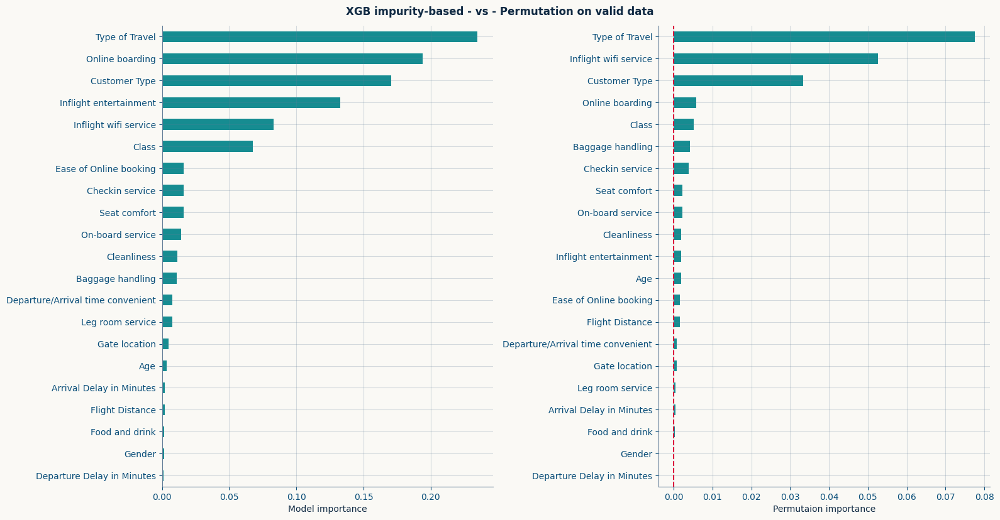

CPU times: user 3min 2s, sys: 90 ms, total: 3min 2s
Wall time: 1min 38s


In [44]:
%%time

X = train[base_cols]
y = train[TARGET]

for c in cat_cols:
    X[c] = X[c].factorize()[0]
    X[c] = X[c].astype("category")

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

imputer = SimpleImputer(strategy="median")
X_train['Arrival Delay in Minutes'] = imputer.fit_transform(X_train[['Arrival Delay in Minutes']])
X_test['Arrival Delay in Minutes']  = imputer.transform(X_test[['Arrival Delay in Minutes']])

## -- Compute Model Importances --
print("⧗ Training baseline (XGB)... ", end="")
params = {
    'objective': "binary:logistic",
    'enable_categorical': True,
    'eval_metric': 'auc',
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'importance_type': "gain",
    'random_state': 42,
    'verbosity': 0,
    'n_jobs': -1,
    'device': "cuda" if torch.cuda.is_available() else "cpu",
}

xgb_model = xgb.XGBClassifier(**params)
xgb_model.fit(X_train, y_train)
print("Complete!")

print("⧗ Training permutation... ", end="")
perm_df = plot_permutation_importance(xgb_model, X_test, y_test, plot_bar=True)

## 2. SHAP VALUES

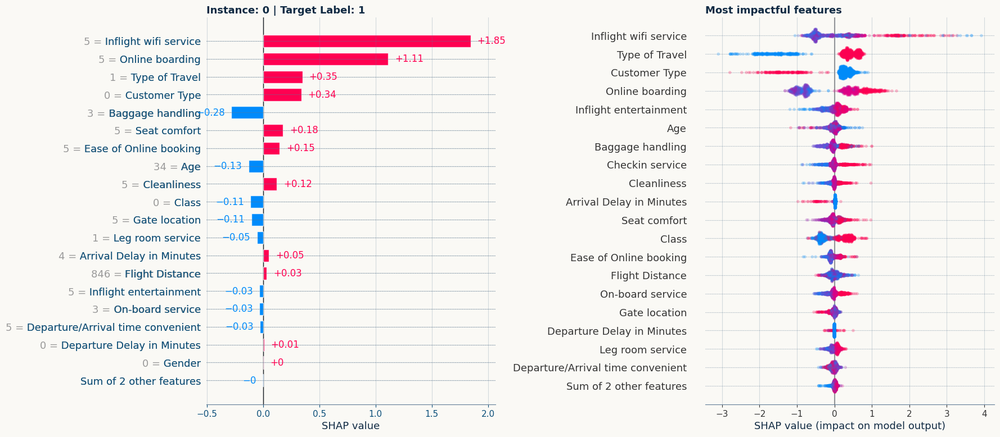

In [45]:
try:
    import shap
except:
    !uv pip install --system -q shap
    import shap

shap.initjs()

## -- Plot SHAP values --
idx      = y_test.sample(1000, random_state=42).index
MAX      = min(20, len(base_cols))
INSTANCE = 0 # 0, 1

explainer = shap.TreeExplainer(xgb_model)
explanation = explainer(X_test.loc[idx])

## -- Bar plot --
plt.subplot(121)
shap.plots.bar(
    explanation[INSTANCE],
    max_display=MAX,
    show=False,
)
plt.title(f"Instance: {INSTANCE} | Target Label: {y_test.loc[idx[INSTANCE]]}", loc="left", pad=5)

## -- Beeswarm plot --
plt.subplot(122)
shap.plots.beeswarm(
    explanation,
    max_display=MAX,
    order=explanation.abs.max(0),
    alpha=0.25,
    plot_size=(18, 8),
    color_bar=False,
    show=False,
)

plt.title("Most impactful features", loc="left", pad=5)
# plt.suptitle(f"XGBoost shap values : Feature impact on model predictions",
#              fontweight="bold", fontsize=15, color=CRIM)

plt.tight_layout(pad=1.5)
plt.show()

shap.plots.force(
    explanation[INSTANCE],
    feature_names=base_cols,
    contribution_threshold=0.1,
    # matplotlib=True,
)

Explaining:   0%|          | 0/1000 [00:00<?, ?it/s]

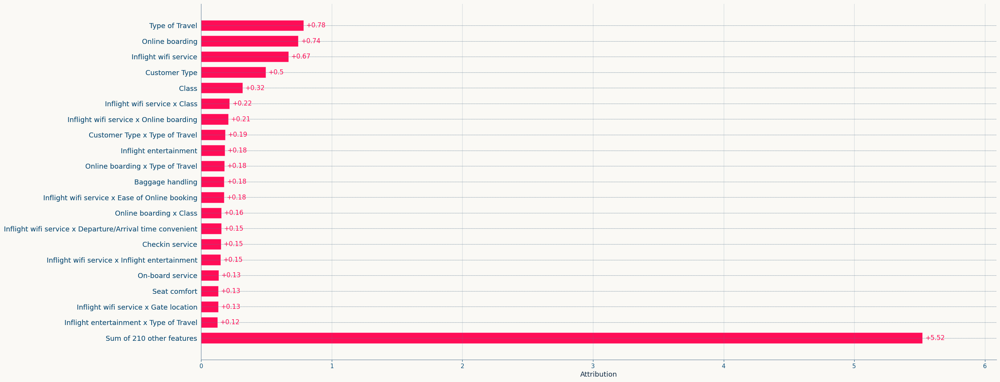

In [46]:
## -- Plot SHAP values --
from __future__ import annotations

try:
    import shapiq
except:
    !uv pip install --system -q shapiq
    import shapiq

explainer = shapiq.TreeExplainer(model=xgb_model, index="SII", min_order=1, max_order=2)

list_of_ivs = explainer.explain_X(X=X_test.loc[idx].to_numpy(), verbose=True)

shapiq.plot.bar_plot(
    list_of_interaction_values = list_of_ivs,
    feature_names              = base_cols,
    max_display                = MAX,
    abbreviate                 = False, # d=True
    # global_plot                = False, # d=True
    # plot_base_value            = True, # d=False
    show                       = True, # d=False 
)

In [47]:
interact_values = explainer.explain(X_test.loc[idx[INSTANCE]].to_numpy(), random_state=42)
print(interact_values)

InteractionValues(
    index=SII, max_order=2, min_order=1, estimated=False, estimation_budget=None,
    n_players=21, baseline_value=-0.26069016638211906,
    Top 10 interactions:
        (2,): 1.8453445023966681
        (7,): 1.1141459976726187
        (2, 20): 0.4058354578568202
        (19,): 0.35005192611455377
        (18,): 0.34097986285466797
        (0, 18): 0.21236574734294655
        (12,): -0.28048021314426613
        (2, 19): -0.39002374081243485
        (2, 9): -0.528360334317446
        (2, 7): -0.6809251289605512
)


In [48]:
top_k_interactions, sorted_top_k_interactions = interact_values.get_top_k(10, as_interaction_values=False)
sorted_top_k_interactions

[((2,), np.float64(1.8453445023966681)),
 ((7,), np.float64(1.1141459976726187)),
 ((2, 20), np.float64(0.4058354578568202)),
 ((19,), np.float64(0.35005192611455377)),
 ((18,), np.float64(0.34097986285466797)),
 ((0, 18), np.float64(0.21236574734294655)),
 ((12,), np.float64(-0.28048021314426613)),
 ((2, 19), np.float64(-0.39002374081243485)),
 ((2, 9), np.float64(-0.528360334317446)),
 ((2, 7), np.float64(-0.6809251289605512))]

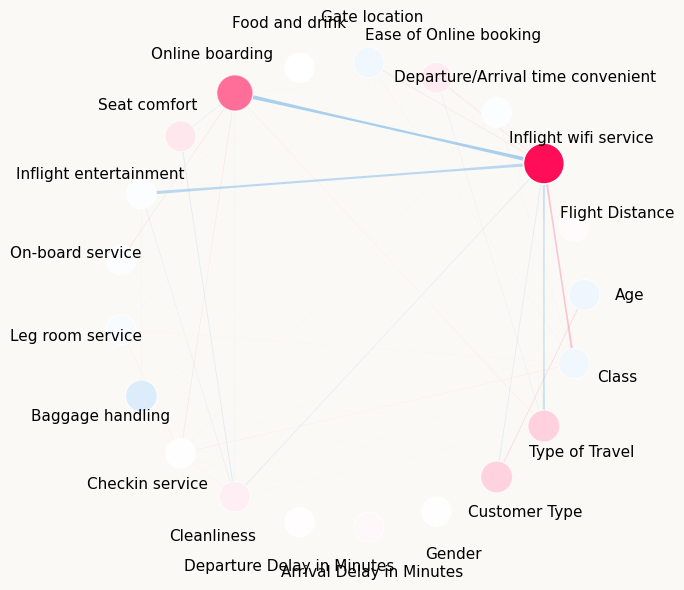

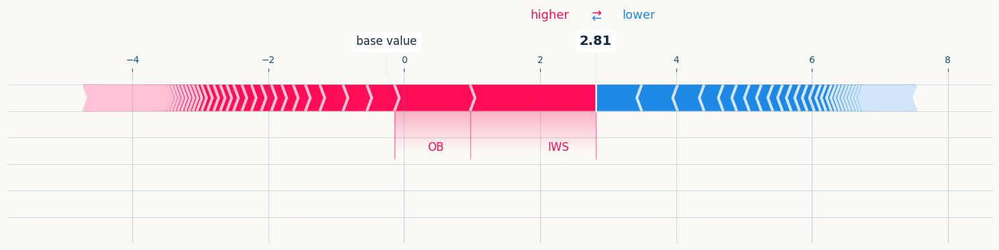

In [49]:
## -- Feature interactions/influence --
shapiq.network_plot(interaction_values=interact_values, feature_names=[*X_test.columns], show=True)
interact_values.plot_force(feature_names=base_cols, contribution_threshold=0.1)

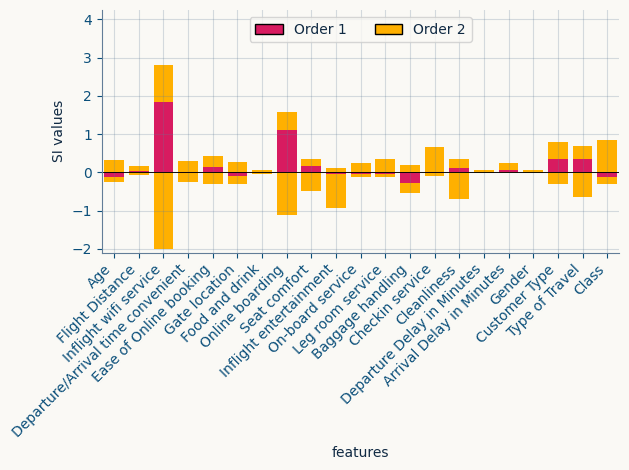

In [50]:
# plt.figure(figsize=(16, 6))
shapiq.stacked_bar_plot(
    # interaction_values=interact_values.get_n_order(1), # plot order 1
    interaction_values=interact_values.get_n_order(2, min_order=1), # plot order 2
    # interaction_values=interact_values.get_n_order(2), # plot order 3 
    feature_names=base_cols,
    show=False,
)

plt.tight_layout()
plt.show()

## 2. GAM Partial Effects

In [52]:
try:
    from pygam import LogisticGAM, s, f, te
except:
    !uv pip install --system -q pygam
    from pygam import LogisticGAM, s, f, te

def gam_dependence_effect(df, features, target, cats):
    df1 = df.copy()
    t0 = time()
    # Dynamically build the GAM formula based on feature types
    gam_terms = []
    for i, feature_name in enumerate(features):
        if feature_name in cats:
            gam_terms.append(f"f({i})")
        else:
            gam_terms.append(f"s({i})")
    # gam_terms.append(f"te({6}, {11})")
    
    gam_formula = " + ".join(gam_terms)

    for c in cats:
        df1[c] = df1[c].factorize()[0]

    for c in features:
        df1[c] = df1[c].fillna(-1)

    X_gam = df1[features].to_numpy()
    y_gam = df1[target].values

    # Evaluate the string formula into actual pygam Term objects
    gam = LogisticGAM(eval(gam_formula), verbose=True)
    gam.fit(X_gam, y_gam)

    rows = (len(features) + 2) // 3 # Calculate rows for subplots dynamically
    fig, axs = plt.subplots(rows, 3, figsize=(18, rows*4))
    axs = axs.ravel()

    for i, col in enumerate(features):
        XX = gam.generate_X_grid(term=i)
        # pdep = gam.partial_dependence(term=i, X=XX)
        pdep, confi = gam.partial_dependence(term=i, width=0.95)
        axs[i].plot(XX[:, i], pdep)
        axs[i].plot(XX[:, i], confi, c=GOLD, ls="--")
        axs[i].set_title(f"* {col}", loc='left', pad=5)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel("partial_effect")

    # Hide any unused subplots
    for j in range(len(features), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout(pad=2.0)
    plt.savefig("pygam_pdep_plot")
    plt.show()

    print(f"Duration: {(time()-t0)/60:.2} mins")
    return gam

print("✓ GAM Dependency function ready!")

✓ GAM Dependency function ready!


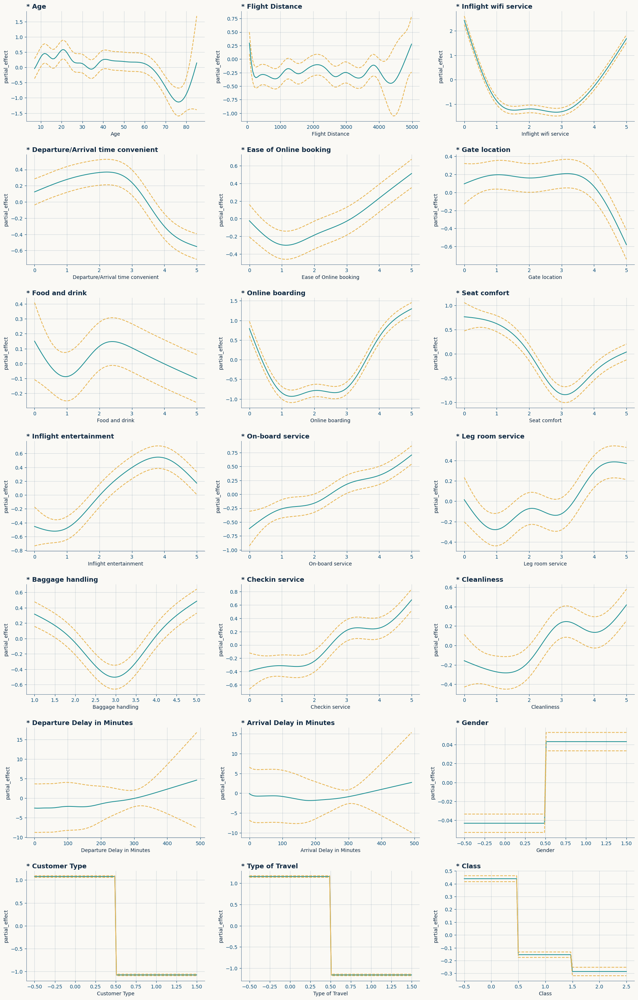

Duration: 4.8 mins


In [53]:
gam_ = gam_dependence_effect(pd.concat([X_train, y_train], axis=1), base_cols, TARGET, cat_cols)

In [54]:
gam_.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                    112.1088
Link Function:                        LogitLink Log Likelihood:                               -142109.0719
Number of Samples:                       524726 AIC:                                           284442.3615
                                                AICc:                                          284442.4108
                                                UBRE:                                               2.5422
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6057
Feature Function                  Lam

In [55]:
print(gam_.accuracy(X_test, y_test))

0.6772207262061987


In [51]:
## -- GET TOP INTERACTIONS --
iv_table = pd.DataFrame.from_dict(interact_values.get_n_order(2).dict_values, orient='index')\
             .rename(columns={0: 'score'})\
             .sort_values(by='score', ascending=False)

iv_table

,score
"(2, 20)",0.405835
"(0, 18)",0.212366
"(2, 4)",0.169349
"(2, 5)",0.153117
"(7, 10)",0.145227
...,...
"(2, 18)",-0.186353
"(8, 14)",-0.198211
"(2, 19)",-0.390024
"(2, 9)",-0.528360


In [56]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_valid = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_valid[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_valid[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_valid.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [57]:
def original_TE(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [58]:
# train, test, _, ORIG_COLS = original_TE(
#     orig,
#     train,
#     test,
#     train.iloc[:1000],
#     features=base_cols,
#     target=TARGET,
#     # - (count, mean, count, std, nunique, median, max, min)
#     aggs=['mean'],
#     fill_nan=True,
# )

# print(ORIG_COLS)

In [59]:
## -- Factorize using combined data --

# for c in cat_cols:
#     print(c)
#     combine  = pd.concat([train[c], test[c]]) # , orig[c]
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = pd.Series(combine[:len(train)], index=train.index).astype('category')
#     test[c]  = pd.Series(combine[len(train):len(train)+len(test)], index=test.index).astype('category')
#     # orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [154]:
## -- FEATURE INTERACTIONS BASED ON SHAP VALUES --

trn_1 = train.copy()
tst_1 = test.copy()

combined = pd.concat([trn_1, tst_1]) # , orig

combo_cols = []
    
for idx in iv_table.index[:5]:
    comb_name = combined.columns[idx[0]] + '_X_' + combined.columns[idx[1]]
    combined[comb_name] = combined.iloc[:, idx[0]].astype(str) + '_' + combined.iloc[:, idx[1]].astype(str)
    combo_cols.append(comb_name)

for idx in iv_table.index[-2:]:
    comb_name = combined.columns[idx[0]] + '_X_' + combined.columns[idx[1]]
    combined[comb_name] = combined.iloc[:, idx[0]].astype(str) + '_' + combined.iloc[:, idx[1]].astype(str)
    combo_cols.append(comb_name)

# for idx in iv_table.index[:5]:
#     comb_name = combined.columns[idx[0]] + '-|-' + combined.columns[idx[1]]
#     combined[comb_name] = combined.iloc[:, idx[0]].astype(str) + '_' + combined.iloc[:, idx[1]].astype(str)
#     combo_cols.append(comb_name)

# for idx in iv_table.index[-3:]:
#     comb_name = combined.columns[idx[0]] + '-|-' + combined.columns[idx[1]]
#     combined[comb_name] = combined.iloc[:, idx[0]].astype(str) + '_' + combined.iloc[:, idx[1]].astype(str)
#     combo_cols.append(comb_name)

trn_1 = combined.iloc[:len(trn_1)]
tst_1 = combined.iloc[len(trn_1):len(train)+len(tst_1)].drop(columns=[TARGET])
# orig  = combined.iloc[-len(orig):]

print(f"Combo features: {combo_cols}")

del combined
trn_1.head()

Combo features: ['Inflight wifi service_X_Class', 'Age_X_Customer Type', 'Inflight wifi service_X_Ease of Online booking', 'Inflight wifi service_X_Gate location', 'Online boarding_X_On-board service', 'Inflight wifi service_X_Inflight entertainment', 'Inflight wifi service_X_Online boarding']


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction,Inflight wifi service_X_Class,Age_X_Customer Type,Inflight wifi service_X_Ease of Online booking,Inflight wifi service_X_Gate location,Online boarding_X_On-board service,Inflight wifi service_X_Inflight entertainment,Inflight wifi service_X_Online boarding
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0.0,4_Eco,36_Loyal Customer,4_4,4_3,4_3,4_1,4_4
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1.0,5_Business,56_Loyal Customer,5_5,5_5,4_5,5_5,5_4
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0.0,3_Eco,31_Loyal Customer,3_2,3_5,3_4,3_3,3_3
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0.0,3_Eco,10_Loyal Customer,3_3,3_3,3_4,3_3,3_3
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,0.0,3_Eco,23_disloyal Customer,3_3,3_4,3_5,3_5,3_3


In [155]:
trn_1.loc[:, 'satisfaction':].nunique()

satisfaction                                        2
Inflight wifi service_X_Class                      18
Age_X_Customer Type                               143
Inflight wifi service_X_Ease of Online booking     36
Inflight wifi service_X_Gate location              36
Online boarding_X_On-board service                 36
Inflight wifi service_X_Inflight entertainment     36
Inflight wifi service_X_Online boarding            36
dtype: int64

In [156]:
FEATURES = [c for c in trn_1.columns if c not in [ID, TARGET]]
print('✓ Total Features:', len(FEATURES))

oof_final    = pd.DataFrame()
test_final   = pd.DataFrame()
model_scores = {}

FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
skf

✓ Total Features: 28


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# ML TRAINING

In [158]:
## -- TREE MODELS --
LR = 0.1
TREES = 1000
DEPTH = 6

tree_models = {
    "XGB_": xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        enable_categorical=True,
        learning_rate=LR,
        iterations=TREES,
        max_depth=DEPTH,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        device="cuda" if torch.cuda.is_available() else "cpu",
    ),
    "LGB_": lgb.LGBMClassifier(
        objective="binary",
        metric="auc",
        learning_rate=LR,
        iterations=TREES,
        max_depth=DEPTH,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        nthreads=-1,
        verbose=-1,
        device="gpu" if torch.cuda.is_available() else "cpu",
    ),
    "CAT_": cgb.CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        learning_rate=LR,
        iterations=TREES,
        max_depth=DEPTH,
        l2_leaf_reg=0.1,
        cat_features=cat_cols,
        random_state=42,
        thread_count=-1,
        verbose=0,
        allow_writing_files=False,
        task_type="GPU" if torch.cuda.is_available() else "CPU",
    ),
    "RFC_": RandomForestClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=42,
    ),
    "HIST_": HistGradientBoostingClassifier(
        learning_rate=LR,
        max_iter=TREES,
        max_depth=DEPTH,
        max_features=0.8,
        early_stopping=False,
        random_state=42,
    ),
}

print(f"Tree Models to train: {len(tree_models)}", end=" -> ")
print(list(tree_models.keys()))

Tree Models to train: 5 -> ['XGB_', 'LGB_', 'CAT_', 'RFC_', 'HIST_']


In [159]:
trn_1.shape, tst_1.shape

((699635, 29), (299844, 28))

## ~ TREE MODELS

Training Models:   0%|          | 0/5 [00:00<?, ?it/s]


[1] XGB_ ██████████ | ⧗ Target Encoding (7) features...
(559708, 28)


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,TE_Inflight wifi service_X_Class_mean,TE_Age_X_Customer Type_mean,TE_Inflight wifi service_X_Ease of Online booking_mean,TE_Inflight wifi service_X_Gate location_mean,TE_Online boarding_X_On-board service_mean,TE_Inflight wifi service_X_Inflight entertainment_mean,TE_Inflight wifi service_X_Online boarding_mean
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,0,0,0,0,0.394307,0.418316,0.648955,0.392446,0.483983,0.330278,0.570461
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,1,0,1,1,0.956171,0.626500,0.959111,0.959433,0.809795,0.954797,0.933557
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,1,0,0,0,0.047963,0.093363,0.308233,0.468324,0.168243,0.111284,0.061465
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,0,1,1,0,0.049042,0.323198,0.307377,0.081319,0.263847,0.495196,0.062204
5,34,584,4,4,4,4,1,4,1,1,3,3,4,4,1,0,0.0,0,1,1,1,0.809743,0.039991,0.648955,0.788491,0.483983,0.330278,0.570461


 • Fold 1/5 AUC: 0.958080
 • Fold 2/5 AUC: 0.956729
 • Fold 3/5 AUC: 0.958804
 • Fold 4/5 AUC: 0.957797
 • Fold 5/5 AUC: 0.958185
-------------------------------
OOF Score: 0.957912
AVG Score: 0.957919 ± 0.00068
-------------------------------
Duration: 1.57 mins


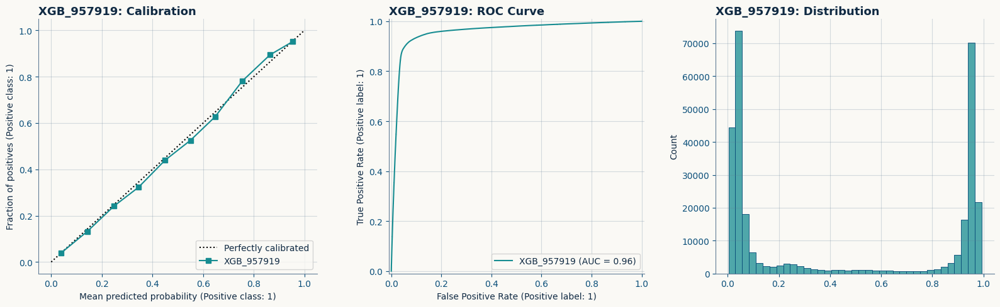

Training Models:  20%|██        | 1/5 [01:36<06:24, 96.17s/it]


[2] LGB_ ██████████ | ⧗ Target Encoding (7) features...
(559708, 28)


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,TE_Inflight wifi service_X_Class_mean,TE_Age_X_Customer Type_mean,TE_Inflight wifi service_X_Ease of Online booking_mean,TE_Inflight wifi service_X_Gate location_mean,TE_Online boarding_X_On-board service_mean,TE_Inflight wifi service_X_Inflight entertainment_mean,TE_Inflight wifi service_X_Online boarding_mean
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,0,0,0,0,0.394307,0.418316,0.648955,0.392446,0.483983,0.330278,0.570461
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,1,0,1,1,0.956171,0.626500,0.959111,0.959433,0.809795,0.954797,0.933557
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,1,0,0,0,0.047963,0.093363,0.308233,0.468324,0.168243,0.111284,0.061465
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,0,1,1,0,0.049042,0.323198,0.307377,0.081319,0.263847,0.495196,0.062204
5,34,584,4,4,4,4,1,4,1,1,3,3,4,4,1,0,0.0,0,1,1,1,0.809743,0.039991,0.648955,0.788491,0.483983,0.330278,0.570461


 • Fold 1/5 AUC: 0.958289
 • Fold 2/5 AUC: 0.956819
 • Fold 3/5 AUC: 0.958822
 • Fold 4/5 AUC: 0.958119
 • Fold 5/5 AUC: 0.958613
-------------------------------
OOF Score: 0.958118
AVG Score: 0.958132 ± 0.000701
-------------------------------
Duration: 1.39 mins


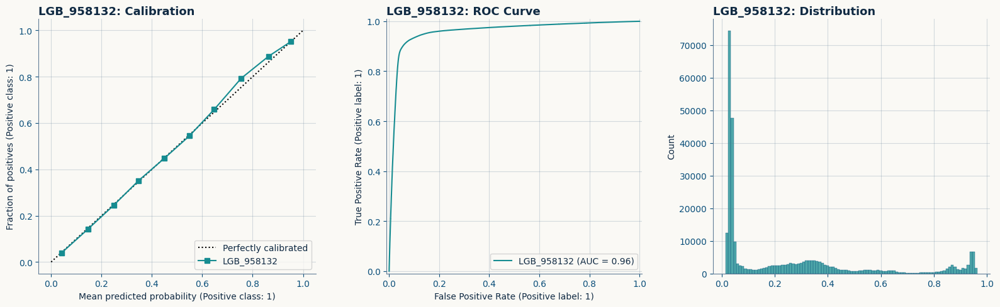

Training Models:  40%|████      | 2/5 [03:01<04:29, 89.77s/it]


[3] CAT_ ██████████ | ⧗ Target Encoding (7) features...
(559708, 28)


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,TE_Inflight wifi service_X_Class_mean,TE_Age_X_Customer Type_mean,TE_Inflight wifi service_X_Ease of Online booking_mean,TE_Inflight wifi service_X_Gate location_mean,TE_Online boarding_X_On-board service_mean,TE_Inflight wifi service_X_Inflight entertainment_mean,TE_Inflight wifi service_X_Online boarding_mean
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,0,0,0,0,0.394307,0.418316,0.648955,0.392446,0.483983,0.330278,0.570461
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,1,0,1,1,0.956171,0.626500,0.959111,0.959433,0.809795,0.954797,0.933557
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,1,0,0,0,0.047963,0.093363,0.308233,0.468324,0.168243,0.111284,0.061465
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,0,1,1,0,0.049042,0.323198,0.307377,0.081319,0.263847,0.495196,0.062204
5,34,584,4,4,4,4,1,4,1,1,3,3,4,4,1,0,0.0,0,1,1,1,0.809743,0.039991,0.648955,0.788491,0.483983,0.330278,0.570461


 • Fold 1/5 AUC: 0.958590
 • Fold 2/5 AUC: 0.957299
 • Fold 3/5 AUC: 0.959087
 • Fold 4/5 AUC: 0.958167
 • Fold 5/5 

In [ ]:
## -- Initiate GBDTs Training --
TREE_MODELS = {}

desc = "Training Models"
for i, (name, model) in tqdm(enumerate(tree_models.items(), 1), total=len(tree_models), desc=desc):
    print(f"\n[{i}] {name} {'█'*10}", end=" | ")
    t0 = time()
    
    X = trn_1[FEATURES]
    y = trn_1[TARGET].astype('int8')

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(tst_1))
    fold_scores = []

    if "CAT" in name:
        combined = pd.concat([X, tst_1])
        for c in cat_cols:
            combined[c] = combined[c].factorize()[0]
        X = combined[:len(X)]
        tst_1 = combined[-len(tst_1):]
    else:
        combined = pd.concat([X, tst_1])
        for c in cat_cols:
            combined[c] = combined[c].factorize()[0]
            combined[c] = combined[c].astype("category")
        X = combined.iloc[:len(X)]
        tst_1 = combined.iloc[-len(tst_1):]

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = tst_1[FEATURES].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, NEW_COLS = original_TE(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=FEATURES,
        #     target=TARGET,
        #     aggs=['mean'], # (mean, count, std, nunique, median, max, min)
        #     # fill_nan=True,
        # )

        # -- TE Opt1. -> Using CUSTOM --
        te_cols = combo_cols
        if fold == 1:
            print(f"⧗ Target Encoding ({len(te_cols)}) features...")
        TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, y_train)
        X_valid = TE.transform(X_valid)
        X_test  = TE.transform(X_test)

        # if 'cat' in name:
        #     combined = pd.concat([X_train, X_valid, X_test])
        #     for c in cat_cols:
        #         combined[c] = combined[c].factorize()[0]
        #     X_train = combined[:len(X_train)]
        #     X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
        #     X_test  = combined[len(X_train)+len(X_valid):]
        # else:
        #     combined = pd.concat([X_train, X_valid, X_test])
        #     for c in cat_cols:
        #         combined[c] = combined[c].factorize()[0]
        #         combined[c] = combined[c].astype('category')
        #     X_train = combined[:len(X_train)]
        #     X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
        #     X_test  = combined[len(X_train)+len(X_valid):]

        if fold == 1:
            print(f"{X_train.shape}"); display(X_train.head())

        print(f" • Fold {fold}/{skf.n_splits}", end=" ")

        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"AUC: {fold_score:.6f}")

    # test_preds /= skf.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 6)
    average_score = np.round(np.mean(fold_scores), 6)
    stdev_score = np.round(np.std(fold_scores), 6)
    
    n = name + str(average_score).split(".")[1]

    print(f"{'-'*31}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {average_score} ± {stdev_score}")
    print(f"{'-'*31}")
    # if 'log' in name:
    #     print(f"Best 'C': {lr_model[-1].C_}") 
    print(f"Duration: {(time()-t0)/60:.2f} mins")

    _, axs = plt.subplots(1, 3, figsize=(16, 5)) #, width_ratios=[0.6,0.4]
    # Right: Confusion matrix (threshold = 0.5)
    pred_labels = (oof_preds >= 0.5).astype('int8')

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibration", loc='left', pad=5)

    # Left: ROC curve
    RocCurveDisplay.from_predictions(y, oof_preds, name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC Curve", loc='left', pad=5)
    # axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{n}: Distribution", loc='left', pad=5)

    plt.tight_layout()
    plt.show()

    oof_final[n]    = oof_preds
    test_final[n]   = test_preds
    TREE_MODELS[n]  = model
    model_scores[n] = average_score

    # del X, y, test_1
    gc.collect()

In [153]:
# RAW 25 ---
# XGB_957953	LGB_957804	HIST_957673

# RAW + COMBO(+5, -2) 28 --- 🔥
# XGB_957919	LGB_958132	CAT_956718	RFC_954891	HIST_958046

display(oof_final.head(3))
print()
display(test_final.head(3))

,XGB_95778,LGB_958107,CAT_956738,RFC_954877,HIST_957879
0,0.238177,0.261797,0.233811,0.25,0.254241
1,0.963265,0.959095,0.964210,0.97,0.960625
2,0.016106,0.030994,0.035537,0.03,0.032077


,XGB_95778,LGB_958107,CAT_956738,RFC_954877,HIST_957879
0,0.242152,0.202716,0.416145,0.210,0.552205
1,0.914298,0.776754,0.930387,0.812,0.906509
2,0.894411,0.394051,0.849766,0.688,0.895752


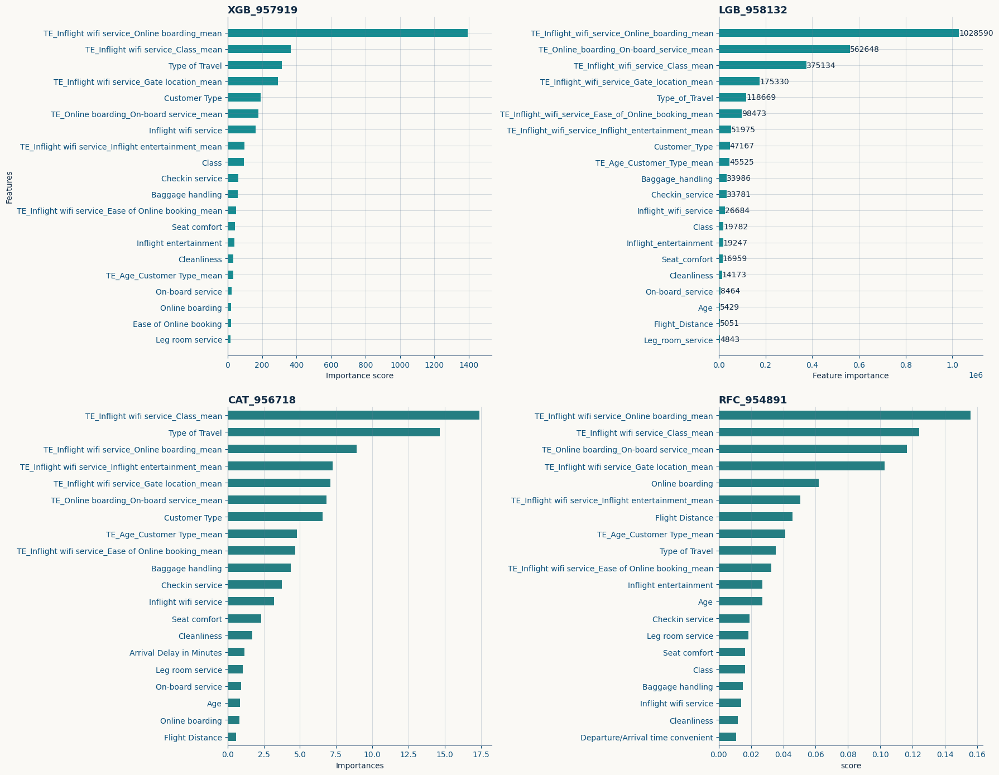

In [95]:
## -- Plot Feature Importances --

plot_trees = {k: v for k, v in TREE_MODELS.items() if 'hist' not in k}
plot_trees

MAX = min(20, len(base_cols))

rows = len(plot_trees) // 2 # Calculate rows for subplots dynamically
fig, axs = plt.subplots(rows, 2, figsize=(18, rows*7))
axs = axs.ravel()

for i, (k, v) in enumerate(plot_trees.items()):
    ## -- xgboost --
    if "XGB" in k:
        xgb.plot_importance(
            v, max_num_features=MAX,
            importance_type="gain",
            title="",
            height=0.5, show_values=False, ax=axs[i],
        )

    ## -- lightgbm --
    elif "LGB" in k:
        lgb.plot_importance(
            v, max_num_features=MAX,
            importance_type="gain",
            title="",
            height=0.5, precision=0, ax=axs[i],
        )
        axs[i].set_ylabel('')

    ## -- catboost --
    elif "CAT" in k:
        cat_imp_df = v.get_feature_importance(prettified=True).iloc[:MAX]
        sns.barplot(data=cat_imp_df, x="Importances", y="Feature Id", width=0.5, ax=axs[i])
        # axs[i].set_title("CAT: importances")
        axs[i].set_ylabel("")

    ## -- random forest --
    elif "RFC" in k:
        rf_dicts = dict(zip(X_train.columns, v.feature_importances_))
        rf_imp_df = pd.DataFrame.from_dict(rf_dicts, orient="index", columns=["score"])\
                                .sort_values("score", ascending=False).iloc[:MAX]
        sns.barplot(rf_imp_df, x=rf_imp_df.score, y=rf_imp_df.index, width=0.5, ax=axs[i])
        axs[i].set_ylabel("")
    else:
        continue
        
    axs[i].set_title(f"{k}", loc='left', pad=5)
    plt.tight_layout(h_pad=2.0)

# Hide any unused subplots
for j in range(len(plot_trees), len(axs)):
    axs[j].axis('off')

plt.show()

## ~ LINEAR MODELS

In [96]:
## -- FEATURE INTERACTIONS BASED ON SHAP VALUES --
trn_2 = train.copy()
tst_2 = test.copy()

combined = pd.concat([trn_2, tst_2]) # , orig

combo_cols = []
for idx in iv_table.index[:5]:
    comb_name = combined.columns[idx[0]] + '_X_' + combined.columns[idx[1]]
    combined[comb_name] = combined.iloc[:, idx[0]].astype(str) + '_' + combined.iloc[:, idx[1]].astype(str)
    combo_cols.append(comb_name)

for idx in iv_table.index[-2:]:
    comb_name = combined.columns[idx[0]] + '_X_' + combined.columns[idx[1]]
    combined[comb_name] = combined.iloc[:, idx[0]].astype(str) + '_' + combined.iloc[:, idx[1]].astype(str)
    combo_cols.append(comb_name)

trn_2 = combined.iloc[:len(trn_2)]
tst_2 = combined.iloc[-len(tst_2):]
# orig  = combined.iloc[-len(orig):]

print(f"Combo features: {combo_cols}")

del combined
train.head()

# for col in ["Departure Delay in Minutes", "Arrival Delay in Minutes"]:
#     log_col = f"log_{col}"
#     train_2[log_col] = np.log1p(train_2[col])
#     test_2[log_col]  = np.log1p(test_2[col])
#     print(f"+++ applying log: {col} --- min={min(train_2[log_col]):.6g} | max={max(train_2[log_col]):.6g}")

# poly_feats = ["Age"]
# for col in poly_feats:
#     p2_col = f"squared_{col}"
#     train_2[p2_col] = train_2[col] ** 2
#     test_2[p2_col]  = test_2[col] ** 2
#     print(f"+++ power^2: {col} --- min={min(train_2[p2_col]):.6g} | max={max(train_2[p2_col]):.6g}")

#     p3_col = f"cubed_{col}"
#     train_2[p3_col] = train_2[col] ** 3
#     test_2[p3_col]  = test_2[col] ** 3
#     print(f"+++ power^3: {col} --- min={min(train_2[p3_col]):.6g} | max={max(train_2[p3_col]):.6g}")

# # # # Add the binned column to your training dataframe
# # # bin_feats = ['Annual_Income_USD']
# # # bins_     = [5]
# # # bin_cats  = []

# # # for col in bin_feats:
# # #     for bin_ in bins_:
# # #         n = f"{col}_bin{bin_}"
# # #         train_2[n], bin_edges = pd.cut(train_2[col], bins=bin_, duplicates='drop', include_lowest=True, retbins=True)
# # #         # Apply the saved bin edges to the test data
# # #         test_2[n] = pd.cut(test_2[col], bins=bin_edges)
# # #         bin_cats.append(n)
# # # cat_cols.extend(bin_cats)

In [97]:
FEATURES_2 = [c for c in trn_2.columns if c not in [ID, TARGET]]
print("✓ Total Features:", len(FEATURES_2))

trn_2

✓ Total Features: 28


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction,Inflight wifi service_Class,Age_Customer Type,Inflight wifi service_Ease of Online booking,Inflight wifi service_Gate location,Online boarding_On-board service,Inflight wifi service_Inflight entertainment,Inflight wifi service_Online boarding
0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0.0,4_Eco,36_Loyal Customer,4_4,4_3,4_3,4_1,4_4
1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1.0,5_Business,56_Loyal Customer,5_5,5_5,4_5,5_5,5_4
2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0.0,3_Eco,31_Loyal Customer,3_2,3_5,3_4,3_3,3_3
3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0.0,3_Eco,10_Loyal Customer,3_3,3_3,3_4,3_3,3_3
4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,0.0,3_Eco,23_disloyal Customer,3_3,3_4,3_5,3_5,3_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699630,57,612,2,1,1,1,1,3,3,2,2,2,2,2,4,0,0.0,Female,Loyal Customer,Business travel,Eco,0.0,2_Eco,57_Loyal Customer,2_1,2_1,3_2,2_2,2_3
699631,30,862,2,2,2,3,4,2,4,4,2,5,4,2,4,24,34.0,Female,disloyal Customer,Business travel,Eco,0.0,2_Eco,30_disloyal Customer,2_2,2_3,2_2,2_4,2_2
699632,49,3148,5,5,5,5,4,4,4,5,5,5,5,5,5,0,0.0,Male,Loyal Customer,Business travel,Business,1.0,5_Business,49_Loyal Customer,5_5,5_5,4_5,5_5,5_4
699633,61,679,5,2,2,2,5,4,4,5,4,5,5,5,1,0,0.0,Female,Loyal Customer,Business travel,Eco,1.0,5_Eco,61_Loyal Customer,5_2,5_2,4_4,5_5,5_4


In [98]:
# ## -- Fill categorical --
# # train[cat_cols] = train[cat_cols].fillna('missing')
# # test[cat_cols]  = test[cat_cols].fillna('missing')
# # orig[cat_cols]  = orig[cat_cols].fillna('missing')

# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train_2, INDI_COLS = appy_nan_indicator(train_2)
# test_2, _  = appy_nan_indicator(test_2)
# # orig, _  = appy_nan_indicator(orig)

# print(INDI_COLS)
# train_2

In [99]:
## -- Linear Models --

linear_models = {
    "NAIVE_": GaussianNB(),
    "LOGIT_": LogisticRegression(
        max_iter=1000,
        C=0.1,
        # class_weight='balanced',
        n_jobs=-1,
        random_state=42,
    ),
    "MLP_": MLPClassifier(
        # hidden_layer_sizes=(len(FEATURES_2) * 5),
        # alpha=0.001,
        # max_iter=50,
        random_state=42,
    ),
    "KNN_": KNeighborsClassifier(
        n_neighbors=10,
        # algorithm="auto",
        n_jobs=-1,
    ),
}

print(f"Linear Models ({len(linear_models)}): ", end="")
print(list(linear_models.keys()))

Linear Models (1): ['MLP_']


In [100]:
# ## -- LINEAR MODEL TRAINER --
# model_id = 0
# name = [*linear_models.keys()][model_id]

# X = train_2[FEATURES_2].copy()
# y = train_2[TARGET].copy()

# oof_preds   = np.zeros(len(X))
# test_preds  = np.zeros(len(test_2))
# fold_scores = []

# t0 = time()
# print(f"\n[1] {name.upper()} {'█'*10} | ", end="")

# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#     X_train, y_train = X.iloc[train_idx], y[train_idx]
#     X_valid, y_valid = X.iloc[val_idx], y[val_idx]
#     X_test = test_2[FEATURES_2].copy()

#     if fold == 1:
#         print(X_train.shape)

#     ## ------------------------------------------------------------------------
#     # ## -- Define encoders --
#     # scaler_enc  = StandardScaler()
#     # one_h_enc   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary")
#     # num_imputer = IterativeImputer(max_iter=50, tol=1e-4, add_indicator=False, random_state=0)
#     # cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING", add_indicator=False)
    
#     # num_cols = X_train.columns.difference(cat_cols, sort=False)

#     # num_sub_pipeline = Pipeline([('sca', scaler_enc), ('imp', num_imputer)])
#     # # cat_sub_pipeline = Pipeline([('imp', cat_imputer), ('ohe', one_h_enc)])
#     # preprocessor = ColumnTransformer(
#     #     [
#     #         # ('cat_prep', cat_sub_pipeline, cat_cols),
#     #         ('num_prep', num_sub_pipeline, num_cols),
#     #     ],
#     #     remainder='passthrough',
#     #     n_jobs=8 if os.cpu_count() > 4 else 1,
#     #     )
#     # ## -- Create pipeline --
#     # m = LogisticRegression(
#     #     max_iter=5000,
#     #     # tol=1e-4,
#     #     # cv=5,
#     #     # scoring='roc_auc',
#     #     # class_weight='balanced',
#     #     n_jobs=64 if os.cpu_count() > 4 else 3,
#     #     random_state=CFG['SEED'],
#     # )
#     # model = Pipeline([('prep_cols', preprocessor), (name, m)]).set_output(transform='pandas')
#     # ## ------------------------------------------------------------------------
#     for col in num_cols:
#         scaler = StandardScaler()
#         X_train[col] = scaler.fit_transform(X_train[[col]], y_train)
#         X_valid[col] = scaler.transform(X_valid[[col]])
#         X_test[col]  = scaler.transform(X_test[[col]])

#     iter_imputer = IterativeImputer(max_iter=50, tol=1e-4, add_indicator=False, random_state=0)
#     X_train.loc[:, num_cols] = iter_imputer.fit_transform(X_train[num_cols])
#     X_valid.loc[:, num_cols] = iter_imputer.transform(X_valid[num_cols])
#     X_test.loc[:, num_cols]  = iter_imputer.transform(X_test[num_cols])

#     model = [*linear_models.values()][model_id]
#     model.fit(X_train, y_train)

#     # if fold == 1:
#     #     print(f"-> Total expanded features: {len(model[:-1].get_feature_names_out())}")

#     oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
#     test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

#     fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#     fold_scores.append(fold_score)
#     print(f"\tFold {fold}/{skf.n_splits} Score: {fold_score:.6f}")

#     del X_train, y_train, X_valid, y_valid, X_test

# # test_preds /= skf.n_splits

# ## -- After all folds --
# overall_score = np.round(roc_auc_score(y, oof_preds), 6)

# print(f"{'-'*31}")
# print(f"OOF Score: {overall_score}")
# print(f"AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
# print(f"{'-'*31}")

# print(f"Duration: {(time() - t0)/60:.2f} mins")

# _, axs = plt.subplots(1, 3, figsize=(18, 5)) #, width_ratios=[0.6,0.4]
# # Right: Confusion matrix (threshold = 0.5)
# pred_labels = (oof_preds >= 0.5).astype('int8')

# CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
# axs[0].set_title(f"{name}: Calibrated predictions")

# # Left: ROC curve
# RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
# axs[1].set_title(f"{name}: Score = {overall_score}")
# # axs[1].grid(False)

# sns.histplot(test_preds, ax=axs[2])
# axs[2].set_title(f"{name}: Distribution")

# plt.tight_layout()
# plt.show()

# n = name + str(overall_score).split('.')[1]
# oof_final[n]     = oof_preds
# test_final[n]    = test_preds
# model_scores[n]  = overall_score
# LINEAR_MODELS[n] = model

# gc.collect()

  0%|          | 0/1 [00:00<?, ?it/s]


[1] MLP_ ██████████ | (559708, 28)
-> Total expanded features: 30
 • Fold 1/5 AUC: 0.956545
 • Fold 2/5 AUC: 0.956031
 • Fold 3/5 AUC: 0.957464
 • Fold 4/5 AUC: 0.956275
 • Fold 5/5 AUC: 0.956662
-------------------------------
OOF Score: 0.956456
AVG Score: 0.956595 ± 0.000486
-------------------------------
Duration: 13.30 mins


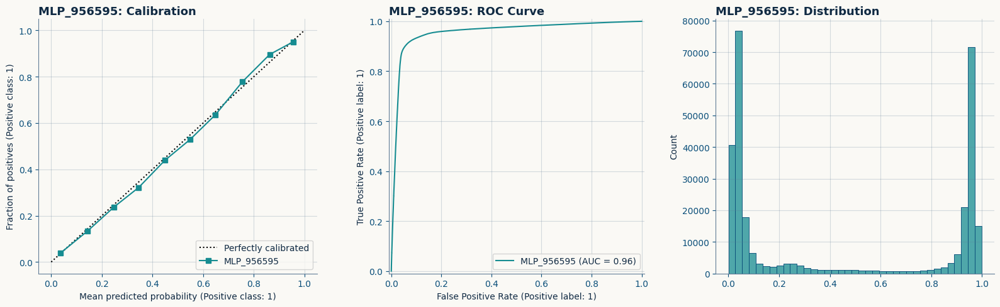

100%|██████████| 1/1 [13:19<00:00, 799.74s/it]


In [101]:
## -- Initiate training --
LINEAR_MODELS = {}

for i, (name, mod) in tqdm(enumerate(linear_models.items(), 1), total=len(linear_models)):
    print(f"\n[{i}] {name} {'█'*10} | ", end="")
    t0 = time()

    X = trn_2[FEATURES_2]
    y = trn_2[TARGET].astype('int8')

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(tst_2))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, y_train = X.iloc[train_idx], y[train_idx]
        X_valid, y_valid = X.iloc[val_idx], y[val_idx]
        X_test = tst_2[FEATURES_2].copy()

        if fold == 1:
            print(X_train.shape)

        # -- TE Opt1. -> Using CUSTOM --
        te_cols = combo_cols
        if fold == 1:
            print(f"⧗ Target Encoding ({len(te_cols)}) features...")
        TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, y_train)
        X_valid = TE.transform(X_valid)
        X_test  = TE.transform(X_test)
        te_features = [c for c in X_train.columns if c.startswith(('TE_', 'oTE_'))]

        ## -- Define encoders --
        scaler_enc  = StandardScaler()
        one_hot_enc = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=True)
        num_imputer = SimpleImputer(strategy="median")
        # num_imputer = IterativeImputer(max_iter=50, tol=1e-4, random_state=0, add_indicator=True)
        # cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING", add_indicator=False)
        pwr_scaler  = PowerTransformer()
        qnt_scaler  = QuantileTransformer(n_quantiles=50, random_state=42)
        ## ------------------------------------------------------------------------
        imp_transformer = make_pipeline(num_imputer, qnt_scaler, scaler_enc)
        sca_transformer = make_pipeline(scaler_enc)
        qnt_transformer = make_pipeline(qnt_scaler)
        cat_transformer = make_pipeline(one_hot_enc)
        pwr_transformer = make_pipeline(pwr_scaler)
        # num_cat_transformer = make_pipeline(num_cat_imputer, one_hot_enc)
        ## ------------------------------------------------------------------------
        # CATS_2 = [c for c in num_cols if X_train[c].nunique() < 1000]
        large_cols = ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
        new_num_cols = X_train.columns.difference(cat_cols+te_features, sort=False) #.tolist()
        ## ------------------------------------------------------------------------
        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', cat_transformer, cat_cols),
                ('num', imp_transformer, new_num_cols),
                # ('sca', sca_transformer, new_num_cols),
            ],
            remainder="passthrough", n_jobs=-1,
        )
        model = make_pipeline(preprocessor, mod)
        ## ------------------------------------------------------------------------
        model.fit(X_train, y_train)

        if fold == 1:
            print(f"-> Total expanded features: {len(model[:-1].get_feature_names_out())}")
            
        print(f" • Fold {fold}/{skf.n_splits}", end=" ")
        ## ------------------------------------------------------------------------
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"AUC: {fold_score:.6f}")

    # test_preds /= skf.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 6)
    average_score = np.round(np.mean(fold_scores), 6)
    stdev_score = np.round(np.std(fold_scores), 6)
    
    n = name + str(average_score).split(".")[1]

    print(f"{'-'*31}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {average_score} ± {stdev_score}")
    print(f"{'-'*31}")
    # if 'log' in name:
    #     print(f"Best 'C': {lr_model[-1].C_}") 
    print(f"Duration: {(time()-t0)/60:.2f} mins")

    _, axs = plt.subplots(1, 3, figsize=(16, 5)) #, width_ratios=[0.6,0.4]
    # Right: Confusion matrix (threshold = 0.5)
    pred_labels = (oof_preds >= 0.5).astype('int8')

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibration", loc='left', pad=5)

    # Left: ROC curve
    RocCurveDisplay.from_predictions(y, oof_preds, name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC Curve", loc='left', pad=5)
    # axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{n}: Distribution", loc='left', pad=5)

    plt.tight_layout()
    plt.show()

    oof_final[n]     = oof_preds
    test_final[n]    = test_preds
    model_scores[n]  = average_score
    LINEAR_MODELS[n] = model

    gc.collect() 

In [ ]:
# [1] NAIVE_ ██████████ | (559708, 28)
# -> Total expanded features: 30
#  • Fold 1/5 AUC: 0.944169
#  • Fold 2/5 AUC: 0.943323
#  • Fold 3/5 AUC: 0.944033
#  • Fold 4/5 AUC: 0.943960
#  • Fold 5/5 AUC: 0.943852
# -------------------------------
# OOF Score: 0.943868
# AVG Score: 0.943867 ± 0.000291
# -------------------------------
# Duration: 1.01 mins

# [2] LOGIT_ ██████████ | (559708, 28)
# -> Total expanded features: 30
#  • Fold 1/5 AUC: 0.949375
#  • Fold 2/5 AUC: 0.948223
#  • Fold 3/5 AUC: 0.949849
#  • Fold 4/5 AUC: 0.949370
#  • Fold 5/5 AUC: 0.949412
# -------------------------------
# OOF Score: 0.949244
# AVG Score: 0.949246 ± 0.000542
# -------------------------------
# Duration: 1.23 mins

oof_final

In [ ]:
## -- Feature Coefs: Linear models --
for i, name in enumerate(list(LINEAR_MODELS.keys())):
    if "LOGIT" in name:
        coef_dict = dict(
            zip(
                LINEAR_MODELS[name][0].get_feature_names_out(),
                LINEAR_MODELS[name][-1].coef_[0],
                # X_valid.columns.tolist(),
                # LINEAR_MODELS[name].coef_[0],
            )
        )
    elif "MLP" in name:
        coef_dict = dict(
            zip(
                LINEAR_MODELS[name][0].get_feature_names_out(),
                LINEAR_MODELS[name][-1].coefs_[0][0],
                # X_valid.columns.tolist(),
                # LINEAR_MODELS[name].coef_[0],
            )
        )
    else:
        continue

    reg_imp = pd.Series(coef_dict).abs().sort_values(ascending=False) #.iloc[:40] # Top'N' features

    plt.figure(figsize=(16, len(reg_imp)*0.5))
    ax = sns.barplot(reg_imp, orient="h", palette="plasma")
    ax.set_ylabel("Feature")
    ax.set_title(f"{name} - Feature coefs (abs)", loc='left', pad=5)
    ax.grid()

    for i, v in enumerate(reg_imp.values):
        ax.text(v+1e-2, i, f"{v:.3f}", va="center", )

    plt.show()

In [ ]:
model_scores

# ~ STACKING

In [ ]:
## -- Check if stack model exists --
# drop_cols = [c for c in oof_final.columns if "STACK" in c and "HILL" in c]

# model_scores = {k: v for k, v in model_scores.items() if k not in drop_cols}

# oof_final    = oof_final.drop(columns=drop_cols)
# test_final   = test_final.drop(columns=drop_cols)

# print()
# print(oof_final.shape, test_final.shape)
oof_final

In [ ]:
# from scipy.stats import rankdata

# Cs = (0.001, 0.01, 0.1, 1.0)
# # USE_L1_L2 = True

# ## -- Search for best C --
# logit_cv = LogisticRegressionCV(
#     Cs=Cs,
#     cv=skf,
#     max_iter=1000,
#     # class_weight="balanced",
#     # penalty="elasticnet" if USE_L1_L2 else "l2",
#     # solver="saga" if USE_L1_L2 else "lbfgs",
#     # l1_ratios=np.linspace(0, 1, 5) if USE_L1_L2 else None,
#     scoring="roc_auc",
#     random_state=CFG["SEED"],
#     n_jobs=-1,
#     verbose=0,
# )

# model_pipe = make_pipeline(StandardScaler(), logit_cv)

# model_pipe.fit(rankdata(oof_final.to_numpy(), axis=0), train[TARGET])
# print(f"Best C: {model_pipe[-1].C_} | Best L1_ratio: {model_pipe[-1].l1_ratio_}")

In [ ]:
# model_pipe[-1].scores_

In [ ]:
# cv_scores = [s for s in model_pipe[-1].scores_.values()]

# for i, (c, scores) in enumerate(zip(Cs, cv_scores[0])):
#     avg = sum(scores[i]) / skf.n_splits
#     print(f"{c:>5}: {avg:.6f}")

In [ ]:
## -- Define Training Parameters --
def prob_to_prob(p, eps=1e-15, clip=30.0):
    p = np.clip(np.asarray(p), eps, 1.0 - eps)
    p = np.log(p / (1 - p))
    return np.clip(p, -clip, clip)

## -- Check if stack/hill models exist --
drop_cols = [c for c in oof_final.columns if "STACK" in c and "HILL" in c]

model_scores = {k: v for k, v in model_scores.items() if k not in drop_cols }
oof_final = oof_final.drop(columns=drop_cols)
test_final = test_final.drop(columns=drop_cols)

stack_oof_preds = np.zeros(len(oof_final))
stack_test_preds = np.zeros(len(test_final))
fold_scores = []

X = prob_to_prob(oof_final).astype(np.float32)
y = train[TARGET].values

## -- Initiate Training --
t0 = time()

print(f"Stacking models: {X.shape[1]}")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}/{skf.n_splits} ", end="")
    
    X_train, X_valid = X[train_idx], X[val_idx]
    y_train, y_valid = y[train_idx], y[val_idx]
    X_test = prob_to_prob(test_final).astype(np.float32)

    # scaler  = StandardScaler()
    # X_train = scaler.fit_transform(X_train, y_train)
    # X_valid = scaler.transform(X_valid)
    # X_test  = scaler.transform(X_test)

    meta_model = LogisticRegression(**{
        "C": 10.,
        "max_iter": 1000,
        "random_state": 42,
    })

    meta_model.fit(X_train, y_train)
    stack_oof_preds[val_idx] = meta_model.predict_proba(X_valid)[:, 1]
    stack_test_preds += meta_model.predict_proba(X_test)[:, 1] / skf.n_splits
    
    oof_score = roc_auc_score(y_valid, stack_oof_preds[val_idx])
    fold_scores.append(oof_score)
    print(f"AUC: {oof_score:.6f}")

## -- After all folds --
stack_oof_score = np.round(roc_auc_score(y, stack_oof_preds), 6)
stack_avg_score = np.round(np.mean(fold_scores), 6)
stack_std_score = np.round(np.std(fold_scores), 6)

stack_name = 'STACK_' + str(stack_avg_score).split('.')[1]

print(f"|{'-'*30}")
print(f"| OOF Score: {stack_oof_score}")
print(f"| AVG Score: {stack_avg_score} ± {stack_std_score}")
print(f"|{'-'*30}")
print(f"| Duration: {(time()-t0):.2f} secs")

_, axs = plt.subplots(1, 3, figsize=(18, 5))

CalibrationDisplay.from_predictions(y, stack_oof_preds, n_bins=10, name=stack_name, ax=axs[0]) # .clip(0, 1)
axs[0].set_title(f"{stack_name}: Calibration")

RocCurveDisplay.from_predictions(y, stack_oof_preds, name=stack_name, ax=axs[1])
axs[1].set_title(f"{stack_name}: ROC Curve")
# axs[1].grid(False)

sns.histplot(stack_test_preds, ax=axs[2])
axs[2].set_title(f"{stack_name}: Distribution")

plt.tight_layout()
plt.show()

In [ ]:
oof_final[stack_name]    = stack_oof_preds
test_final[stack_name]   = stack_test_preds
model_scores[stack_name] = stack_oof_score

display(oof_final)
model_scores

# ~ HILLCLIMB

In [ ]:
try:
    from hillclimbers import climb_hill, partial
except:
    !uv pip install --system hillclimbers
    from hillclimbers import climb_hill, partial

In [ ]:
%%time

## -- Check if stack/hill models exist --
drop_hill    = [c for c in oof_final.columns if "HILL" in c]
oof_final    = oof_final.drop(columns=drop_hill)
test_final   = test_final.drop(columns=drop_hill)
model_scores = {k: v for k, v in model_scores.items() if k not in drop_hill}

drop_stack = [c for c in oof_final.columns if "STACK" in c]

## -- Run hillclimber --
hc_test_preds, hc_oof_preds = climb_hill(
        train=train,
        target=TARGET,
        oof_pred_df=oof_final.drop(columns=drop_stack),
        test_pred_df=test_final.drop(columns=drop_stack),
        eval_metric=partial(roc_auc_score),
        objective="maximize",
        return_oof_preds=True,
        negative_weights=True,
        precision=0.01,
        plot_hill=True,
        plot_hist=False,
)

In [ ]:
hc_oof_score = np.round(roc_auc_score(y, hc_oof_preds), 6)
hillclimb_name = "HILLCLIMB_" + str(hc_oof_score).split('.')[1]

oof_final[hillclimb_name]  = hc_oof_preds
test_final[hillclimb_name] = hc_test_preds

model_scores[hillclimb_name] = hc_oof_score
scores_df = pd.Series(model_scores, name='score').sort_values()
scores_df

In [ ]:
display(oof_final.head())
print()
display(test_final.head())
print()

plt.figure(figsize=(16, 5))
# • ms — Shorthand for markersize
# • mfc — Shorthand for markerfacecolor
# • mec — Shorthand for markeredgecolor
# • mew — Shorthand for markeredgewidth
# • c — Shorthand for color (frequently used in scatter plots)
# • s — Shorthand for marker size in scatter plots
sns.lineplot(
    scores_df,
    marker='o',
    ms=10,
    mfc=CRIM,
    # mec=DARK,
    mew=1.5,
)
plt.tick_params('x')
plt.title("- Model Scores -", size=15, weight='semibold')

for i, s in enumerate(scores_df.values):
    plt.text(scores_df.index[i], s+1e-5, s, va="baseline", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# plt.figure(figsize=(16, 6))
# # • ms — Shorthand for markersize
# # • mfc — Shorthand for markerfacecolor
# # • mec — Shorthand for markeredgecolor
# # • mew — Shorthand for markeredgewidth
# # • c — Shorthand for color (frequently used in scatter plots)
# # • s — Shorthand for marker size in scatter plots
# sns.barplot(
#     model_scores.to_frame().sort_values(by=0, ascending=False),
#     x=model_scores.values,
#     y=model_scores.index,
#     # marker='o',
#     # ms=10,
#     # mfc=CRIM,
#     # # mec=DARK,
#     # mew=1.5,
#     # orient='horizontal',
# )
# plt.xlim(0.9, 0.96)
# # plt.tick_params('x')
# # plt.title("- Model Scores -", size=15, weight='semibold')

# for i, s in enumerate(model_scores.values):
#     plt.text(model_scores.index[i], s, s+2e-3, va="center_baseline", ha="center")

# plt.tight_layout()
# plt.show()

# SUBMISSION

In [ ]:
## -- Export stacking --
stack_score = str(stack_oof_score).split('.')[1]
stack_oof_preds  = oof_final[stack_name].to_numpy().ravel()
stack_test_preds = test_final[stack_name].to_numpy().ravel()

s_n = f"BASE_STACK_{stack_score}"
np.save(f"oof_{s_n}.npy", stack_oof_preds)
np.save(f"test_{s_n}.npy", stack_test_preds)

submit[TARGET] = stack_test_preds
submit.to_csv(f"submit_{s_n}.csv", index=False)
print(f"--> {s_n} file saved!")

In [ ]:
## -- Export hillclimb --
hillclimb_score = str(hc_oof_score).split('.')[1]
hillclimb_oof_preds  = oof_final[hillclimb_name].to_numpy().ravel()
hillclimb_test_preds = test_final[hillclimb_name].to_numpy().ravel()

h_n = f"BASE_HILLCLIMB_{hillclimb_score}"
np.save(f"oof_{h_n}.npy", hillclimb_oof_preds)
np.save(f"test_{h_n}.npy", hillclimb_test_preds)

submit[TARGET] = hillclimb_test_preds
submit.to_csv(f"submit_{h_n}.csv", index=False)
print(f"--> {h_n} file saved!")

In [ ]:
# ## -- Create Submission files --
# for i, c in enumerate(test_final.columns):
#     submit[TARGET] = test_final[c].values.ravel()
#     submit.to_csv(f"submit_BASE_{c}.csv", index=False)
#     print(f"--> submit_BASE_{c}.csv file saved!")

In [ ]:
# !rm -r /kaggle/working/